# Classification of Defective Solar Panels

- classification using models
- tasks: hyper parameter tuning for classification models
    - focus on XGboost - best results so far
    - Adaboost discontinued
    - eventually ANN and Balanced Random Forest - best results so far
    - eventually search for alternative suitable models
>

## Background

- solar energy production data
    - solar energy production in Goerlitz (GR)
    - group 3 (H) (`pv3`) with defective times labelled (`pv3_defect`)
    - information on sensor (old = 0 = higher precision)  
      &rarr; has to be excluded here, as no defects after sensor was exchanged
    - weather data associated
    - daily or weekly aggregated data
    - categorical data already dummified in model_data
>
- weather features (aggregated for weekly data)

    Abbreviation | column name | aggregation
    --- | --- | ---
    MESS_DATUM | date | -
    FX | max_windgust | mean
    FM | mean_wind_velocity | mean
    RSK | precipitation_height | mean
    SDK | sunshine_duration | mean
    SHK_TAG | snow_depth | mean
    NM | mean_cloud_cover | mean
    VPM | mean_vapor_pressure | mean
    PM | mean_pressure | mean
    TMK | mean_temperature | mean
    UPM | mean_relative_humidity | mean
    ||
    RSKF | precipitation_form | mode
    ||
    TXK | max_temperature | mean, max
    TNK | min_temperature | mean, min
    TGK | min_air_temperature | mean, min
>
- solar data daily or aggregated weekly

    column name | aggregation
    --- | --- 
    pv | mean
    pv3_defect | mode
    sensor | mode 
>
- defective time windows + known repairs
    - 3 time intervals with malfunctions
    - defects labelled semi-manually using error metrics + manual inspection

    ```py
    # time ranges include first and last day with defects
    defect_ranges_group3 = [(datetime(2009,10, 4), datetime(2011,6, 9)),
                            (datetime(2011,10,10), datetime(2012,3,15)),
                            (datetime(2016, 5,22), datetime(2016,6,27))]
    ```
    ```py
    repairs_group3 = ["09.06.2011", "27.06.2016",]
    ```
>

## Approach

- model defects from 
    - solar production
    - weather features
    - excluded: sensor (exchanged after defective periods)
- train-test split using stratification due to imbalanced data
- hyperparameter tuning for XGboost modelling 
    - different grids and different random seeds - run multiple times
    - various quality metrics
    - optimization for recall and f1 score
    - inspection of 3 exemplary models with good f1 and recall score
- general issue from classification
    - some false negatives
    - quite many false positives (>= 50% of reported defects are FP)
- solution approach
    - defects are persistent &rarr; accumulate defect predictions and apply threshold
    - reduces FP rate dramatically
    - but: introduces lag (as defect predictions need to accumulate to pass threshold)
>
- here: pre-selected weather features
    - aim: reduce noise by just passing relevant features to the models as proposed [here](https://medium.com/@rithpansanga/improving-precision-and-recall-in-machine-learning-tips-and-techniques-acb5a5fd27a6#:~:text=In%20conclusion%2C%20there%20are%20several,class%20weights%2C%20and%20using%20ensembling.)
    
<br>

> *"Using a smaller set of more relevant features can improve the precision and recall of the model, as the model will have less noise to learn from."*

<br>

```py
# possible selection of (weather) features
# here: precipitation types 7 & 8 refer to snow and snow-rain-mixture
selected_feats = ['pv3', 'sunshine_duration', 'mean_cloud_cover', 'snow_depth', 'mean_wind_velocity', 
                  'max_temperature', 'min_temperature', 'mean_relative_humidity','precip_7', 'precip_8',]
exclude = ['sensor', 'max_windgust', 'precipitation_height', 'mean_vapor_pressure', 
           'mean_pressure', 'mean_temperature', 'min_air_temperature', 'precip_4', 'precip_6']
```


## Preparations

In [1]:
# load required packages
from IPython.display import display
from datetime import datetime
from tqdm import tqdm
import matplotlib.pyplot as plt
import plotly.express as px
import scipy.stats as stats
import missingno as msno
import seaborn as sns
import pandas as pd
import numpy as np
import sys
import os

# general modelling packages
sys.path.insert(0, '..') # required to import models.tools
from models.tools import show_info, add_date_features, compute_importance
# other available tools: get_alerts, dump_missing, parse_xml, plot_correlation, drop_na_and_zeros, get_common_index
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# classifier packages
from xgboost import XGBClassifier
from xgboost import Booster, DMatrix

# metrics packages
from sklearn.metrics import roc_curve, roc_auc_score, ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score
from sklearn.metrics import precision_recall_curve, auc
from sklearn.metrics import recall_score, f1_score

# neural network packages
import tensorflow as tf
from tensorflow.keras.utils import plot_model
from tensorflow.keras import metrics

import keras 
from keras.models import Sequential # intitialize the ANN
from keras.layers import Dense, Activation, Dropout      # create layers

In [2]:
RSEED = 42
np.random.seed(RSEED)
tf.random.set_seed(RSEED)

In [3]:
# ranges of malfunctioning for group 3 (H)
defect_ranges3 = [(datetime(2009,10, 4), datetime(2011,6, 9)),
                  (datetime(2011,10,10), datetime(2012,3,15)),
                  (datetime(2016, 5,22), datetime(2016,6,27))]

idx_maintenance_g3 = [
    "09.06.2011", # H repair - group 3
    "27.06.2016", # H repair - group 3
    ]

lw = 2 # line width

model_path1 = "../data/pv_households/GR/classification_models1_sel_feats/"
model_path2 = "../data/pv_households/GR/classification_models2_sel_feats/"

logfile1 = "GridSearch_log.txt"
logfile2 = "GridSearch2_log.txt"

for dir in (model_path1, model_path2):
    if not os.path.exists(dir):
        os.makedirs(dir)

In [4]:
# functions to evaluate classification results
def plot_confusion_matrix(y_true, y_pred, title=""):
    """plot confusion matrix"""

    # calculate confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    # customize output image
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    fig, ax = plt.subplots(figsize=(3,3))
    disp.plot(ax=ax)
    disp.ax_.set_title(title)
    plt.show()

def plot_roc_curve(y_train, y_train_pred, y_test, y_test_pred):
    """plot ROC curve for train and test data"""

    # calculate require values for ROC curve
    fpr_model1, tpr_model1, thresholds_model1 = roc_curve(y_train, y_train_pred)
    fpr_model2, tpr_model2, thresholds_model2 = roc_curve(y_test, y_test_pred)
    auc_model1 = roc_auc_score(y_train, y_train_pred)
    auc_model2 = roc_auc_score(y_test, y_test_pred)

    # customize output image
    plt.subplots(figsize=(4,4))
    plt.plot(fpr_model1, tpr_model1,'r-',label = 'Train AUC: %.3f'%auc_model1)
    plt.plot(fpr_model2,tpr_model2,'b--', label= 'Test AUC: %.3f'%auc_model2)
    plt.plot([0,1],[0,1],'k-',label='random')
    plt.plot([0,0,1,1],[0,1,1,1],'g-',label='perfect')
    plt.legend()
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.show()

def plot_precision_recall_curve(X_train, X_test, y_train, y_test, model, neuralnet=False, xgb=False, outdir="", save_tag=""):
    """plot precision recall curve for train and test data"""

    # calculate class probabilities
    if neuralnet:
        # reshaping required in case of neural network
        # needs two columns which sum up to one - as np array
        y_pred_proba = model.predict(X_test)
        y_pred_proba = pd.DataFrame(y_pred_proba.T[0])
        y_pred_proba.columns = ["A"]
        y_pred_proba["B"] = 1-y_pred_proba["A"]
        y_pred_proba = np.array(y_pred_proba)

        y_pred_proba2 = model.predict(X_train)
        y_pred_proba2 = pd.DataFrame(y_pred_proba2.T[0])
        y_pred_proba2.columns = ["A"]
        y_pred_proba2["B"] = 1-y_pred_proba2["A"]
        y_pred_proba2 = np.array(y_pred_proba2)
    elif xgb:
        y_pred_proba2 = model.predict(DMatrix(X_train, y_train))
        y_pred_proba = model.predict(DMatrix(X_test, y_test))
        y_pred_proba = pd.DataFrame(y_pred_proba)
        y_pred_proba.columns = ["A"]
        y_pred_proba["B"] = 1-y_pred_proba["A"]

        y_pred_proba = np.array(y_pred_proba)
        y_pred_proba2 = pd.DataFrame(y_pred_proba2)
        y_pred_proba2.columns = ["A"]
        y_pred_proba2["B"] = 1-y_pred_proba2["A"]
        y_pred_proba2 = np.array(y_pred_proba2)
    else:
        # for conventional models (log reg, RF, XGboost, ...)
        y_pred_proba = model.predict_proba(X_test) 
        y_pred_proba2 = model.predict_proba(X_train)

        
    #retrieve probability of being 1(in second column of y_pred_proba)
    precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba[:, 1]) 
    precision2, recall2, thresholds2 = precision_recall_curve(y_train, y_pred_proba2[:, 1]) 

    # customize output image
    plt.subplots(figsize=(4,4))
    plt.title("Precision-Recall vs Threshold Chart")
    plt.plot(thresholds2, precision2[: -1], "b--", label="Precision Train")
    plt.plot(thresholds, precision[: -1], "b-", label="Precision Test")
    plt.plot(thresholds2, recall2[: -1], "r--", label="Recall Train")
    plt.plot(thresholds, recall[: -1], "r-", label="Recall Test")
    plt.axvline(0.5, color="gray", ls="--", alpha=0.5)
    plt.axhline(0.5, color="gray", ls="--", alpha=0.5)
    plt.ylabel("Precision, Recall")
    plt.xlabel("Threshold")
    plt.legend(loc="upper center")
    plt.ylim([0,1])
    if save_tag != "":
        plt.savefig(outdir+"_".join(["precision_recall", save_tag])+".png", format="png")
    plt.show()

def evaluate_model(y_train, y_test, X_train, X_test, model, 
                   neuralnet=False, xgb=False, plotting=True, save_tag="", outdir=""):
    """evaluate model with metrics and plots"""
    
    # predict on train and test data
    if xgb:
        y_train_pred = model.predict(DMatrix(X_train, y_train))
        y_test_pred = model.predict(DMatrix(X_test, y_test))
    else:
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

    if neuralnet or xgb:
        # probabilities predicted
        y_train_pred = y_train_pred.round(0)
        y_test_pred = y_test_pred.round(0)
        
    # calculate metrics
    r1 = recall_score(y_train, y_train_pred)
    r2 = recall_score(y_test, y_test_pred)
    f1 = f1_score(y_train, y_train_pred)
    f2 = f1_score(y_test, y_test_pred)
    a1 = roc_auc_score(y_train, y_train_pred)
    a2 = roc_auc_score(y_test, y_test_pred)
    ac1 = accuracy_score(y_train, y_train_pred)
    ac2 = accuracy_score(y_test, y_test_pred)
    p1 = precision_score(y_train, y_train_pred)
    p2 = precision_score(y_test, y_test_pred)
    print("Recall Train:  ", r1)
    print("F1 Score Train:", f1)
    print("AUC Train:     ", a1)
    print("Train:\n%s\n" % confusion_matrix(y_train, y_train_pred))
    print("Recall Test:  ", r2)
    print("F1 Score Test:", f2)
    print("AUC Test:     ", a2)
    print("Test:\n%s\n" % confusion_matrix(y_test, y_test_pred))

    # plots for model evaluation
    if plotting:
        plot_confusion_matrix(y_train, y_train_pred, title="Training")
        plot_confusion_matrix(y_test, y_test_pred, title="Test")
        plot_roc_curve(y_train, y_train_pred, y_test, y_test_pred)
    
    
    plot_precision_recall_curve(X_train, X_test, y_train, y_test, model,
                                neuralnet=neuralnet, xgb=xgb, save_tag=save_tag, outdir=outdir)

        # compare predicted and true y
        # sns.scatterplot(x=y_train, y=y_train_pred).set(title="Training", xlabel="True", ylabel="Predicted")
        # sns.scatterplot(x=y_test, y=y_test_pred).set(title="Test", xlabel="True", ylabel="Predicted")
        # plt.show()

        # sns.scatterplot(y=y_train, x=len(y_train)).set(title="Training", xlabel="Date", ylabel="Y", label="True")
        # sns.scatterplot(y=y_train_pred).set(title="Training", xlabel="Date", ylabel="Y", label="Pred")
        # # sns.scatterplot(y=y_test-y_test_pred).set(title="Test", xlabel="Date", ylabel="True-Predicted")
        # plt.show()

    # evaluate model importance
    try:
        compute_importance(model, X_test, y_test, rseed=RSEED, top=10, save_tag=save_tag, outdir=outdir)
    except:
        print("Couldn't extract feature importance!")
    
    return (r1,f1,a1,ac1,p1,r2,f2,a2,ac2,p2)

def plot_ann_metrics(history):
    """create plots for evaluation metrics tracked while training the network"""
    
    # summarize history for accuracy
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(5,7), sharex=True)
    f1 = ax1.plot(history.history['accuracy'])
    ax1.plot(history.history['val_accuracy'])
    ax1.set_title('model accuracy')
    ax1.set_ylabel('accuracy')
    ax1.set_xlabel('epoch')
    ax1.legend(['train', 'validation'], loc='lower right')
    # plt.show()

    # summarize history for area under the ROC curve
    ax2.plot(history.history['auc'])
    ax2.plot(history.history['val_auc'])
    ax2.set_title('model AUC')
    ax2.set_ylabel('AUC')
    ax2.set_xlabel('epoch')
    ax2.legend(['train', 'validation'], loc='lower right')
    plt.tight_layout()
    plt.show()

    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    metrics = ['loss', 'accuracy', 'precision', 'recall', "auc"]
    plt.subplots(figsize=(8,8), sharex=True)
    # plot individual metrics as subplots
    for n, metric in enumerate(metrics):
        try:
            name = metric.replace("_"," ").capitalize()
            plt.subplot(3,2,n+1)
            plt.plot(history.epoch, history.history[metric], color=colors[0], label='Train')
            plt.plot(history.epoch, history.history['val_'+metric],
                    color=colors[0], linestyle="--", label='Test')
            plt.xlabel('Epoch')
            plt.ylabel(name)
            if metric == 'loss':
                plt.ylim([0, plt.ylim()[1]])
            elif metric == 'auc':
                plt.ylim([0.5,1])
            else:
                plt.ylim([0,1])

            plt.legend()
        except:
            pass
    plt.tight_layout()
    plt.show()

### Summary Visualization incl Rolling Threshold

In [5]:
def compound_viz(X,y,y_pred, time_window=14, alert_threshold=10):

    # combine date, true & predicted y
    date_values = pd.to_datetime(X.index)
    result_df = pd.concat([pd.Series(date_values), y.reset_index(drop=True), pd.Series(y_pred)], axis=1, keys=['date', 'y', 'y_pred'])
    # result_df.date = pd.to_datetime(result_df.date, format="%d-%m-%Y")
    result_df.set_index("date", inplace=True)
    
    # rolling sum
    summarized_df = result_df.copy()
    summarized_df["y_pred_sum"] = summarized_df.y_pred.rolling(time_window).sum()
    summarized_df.reset_index(inplace=True)

    fig, ((ax1,ax2,ax3), (ax4,ax5,ax6), (ax7,ax8,ax9), (ax10,ax11,ax12)) = plt.subplots(4,3, figsize=(12,12))

    # predictions over time + error periods
    sns.scatterplot(y=y_pred, x=date_values, ax=ax1).set(title="Predictions over time", xlabel="Date", ylabel="True")
    sns.scatterplot(y=y-y_pred, x=date_values, ax=ax4).set(title="True-Predictions", xlabel="Date", ylabel="True-Predicted")
    sns.scatterplot(y=summarized_df.y_pred_sum, x=summarized_df.date, ax=ax7).set(title="Cumulative Alerts over %d Day Periods" % time_window, xlabel="Date", ylabel="Accumulated Defect Reports\n(%d Days)" % time_window)
    sns.scatterplot(y=summarized_df.y_pred_sum>=alert_threshold, x=summarized_df.date, ax=ax10).set(title="Cumulative Alerts over %d Day Periods" % time_window, xlabel="Date", ylabel="Alerts\n(>=%d Defect Reports in %d Days)" % (alert_threshold, time_window))

    # zoomed error region 1
    sns.scatterplot(y=y_pred, x=date_values, ax=ax2).set(title="Predictions During Defect Period 1+2", xlabel="Date", ylabel="True")
    sns.scatterplot(y=y-y_pred, x=date_values, ax=ax5)#.set(title="True-Predictions During Defect Period 1+2", xlabel="Date", ylabel="True-Predicted")
    sns.scatterplot(y=summarized_df.y_pred_sum, x=summarized_df.date, ax=ax8)#.set(title="Cumulative Alerts over 2-Week Periods", xlabel="Date", ylabel="Accumulated Defect Reports (10 days)")
    sns.scatterplot(y=summarized_df.y_pred_sum>=alert_threshold, x=summarized_df.date, ax=ax11)#.set(title="Cumulative Alerts over %d Day Periods" % time_window, xlabel="Date", ylabel="Alerts\n(>=%d Defect Reports in %d Days)" % (alert_threshold, time_window))

    # zoomed error region 2
    sns.scatterplot(y=y_pred, x=date_values, ax=ax3).set(title="Predictions During Defect Period 3", xlabel="Date", ylabel="True")
    sns.scatterplot(y=y-y_pred, x=date_values, ax=ax6).set(title="True-Predictions During Defect Period 3", xlabel="Date", ylabel="True-Predicted")
    sns.scatterplot(y=summarized_df.y_pred_sum, x=summarized_df.date, ax=ax9).set(title="Cumulative Alerts over %d Day Periods" % time_window, xlabel="Date", ylabel="Accumulated Defect Reports (%d Days)" % time_window)
    sns.scatterplot(y=summarized_df.y_pred_sum>=alert_threshold, x=summarized_df.date, ax=ax12)#.set(title="Cumulative Alerts over %d Day Periods" % time_window, xlabel="Date", ylabel="Alerts\n(>=%d Defect Reports in %d Days)" % (alert_threshold, time_window))

    # shade defective periods
    for ax in (ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8, ax9, ax10, ax11, ax12):
        for mini, maxi in defect_ranges3:
            ax.axvspan(xmin=mini, xmax=maxi, facecolor="red", alpha=0.15)
    # for date in idx_maintenance_g3:
    #     ax1.axvline(pd.to_datetime(date, format="%d.%m.%Y"), color="red", linestyle='--', lw=2)

    #customize y ranges and labelling (no internal tick and axis labels)
    for ax in (ax2,ax5,ax8,ax11):
        ax.set_xlim(datetime(2009,1,1), datetime(2013,1,1))
    for ax in (ax3,ax6,ax9, ax12):
        ax.set_xlim(datetime(2016,4,1), datetime(2016,9,1))
    for ax in (ax10, ax11, ax12):
        ax.tick_params('x', labelrotation=90)
    for ax in (ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8, ax9):
        ax.axes.xaxis.set_ticklabels([])
        ax.set(xlabel=None)
    for ax in (ax2, ax3, ax5, ax6, ax8, ax9, ax11, ax12):
        # ax.axes.yaxis.set_ticklabels([])
        ax.set_yticklabels([])
        ax.set(ylabel=None)
    for ax in (ax4, ax6, ax7, ax8, ax9, ax10):
        ax.set(title=None)

    plt.tight_layout()
    plt.show()

In [6]:
def eval_accumulative_alerts(X, y, y_pred, alert_threshold=10, time_window=14, verbose=False):
    
    # combine date, true & predicted y
    date_values = pd.to_datetime(X.index)
    result_df = pd.concat([pd.Series(date_values), y.reset_index(drop=True), pd.Series(y_pred)], axis=1, keys=['date', 'y', 'y_pred'])
    # result_df.date = pd.to_datetime(result_df.date, format="%d-%m-%Y")
    result_df.set_index("date", inplace=True)

    # rolling sum
    summarized_df = result_df.copy()
    summarized_df["y_pred_sum"] = summarized_df.y_pred.rolling(time_window).sum()
    summarized_df.reset_index(inplace=True)

    # non-defective time windows 
    queries1 = ["date < '2009-10-04'",
                "date > '2011-06-09' & date < '2011-10-10'",
                "date > '2012-03-15' & date < '2016-05-22'", 
                "date > '2016-06-27'",]
    # defective time windows 
    queries2 = ["date >= '2009-10-04' & date <= '2011-06-09'",
                "date >= '2011-10-10' & date <= '2012-03-15'",
                "date >= '2016-05-22' & date <= '2016-06-27'",]

    # calculate FP
    total_fp = 0
    total_tn = 0
    for query in queries1: # FP
        fp_count = len(summarized_df[summarized_df.y_pred_sum>=alert_threshold].query(query))
        window_len = len(summarized_df.query(query))
        print("%d of %d FP alerts" % (fp_count, window_len))
        total_fp += fp_count
        total_tn += (window_len-fp_count)
        if verbose:
            print(summarized_df[summarized_df.y_pred_sum>=alert_threshold].query(query))
    print(50*"-" + "\n%d FP in total!" % total_fp)
    print("%d TN in total!\n" % total_tn)

    # calculate TP and TN
    total_tp = 0
    total_fn = 0
    for query in queries2: # TP
        tp_count = len(summarized_df[summarized_df.y_pred_sum>=alert_threshold].query(query))
        window_len = len(summarized_df.query(query))
        print("%d of %d TP alerts - %d FN" % (tp_count, window_len, window_len-tp_count))
        total_tp += tp_count
        total_fn += (window_len-tp_count)
        if verbose:
            print(summarized_df[summarized_df.y_pred_sum<alert_threshold].query(query).head(20))
    print(50*"-" + "\n%d TP in total!" % total_tp)
    print("%d FN in total!\n" % total_fn)

    # # customize output image
    cm = np.array([total_tn,total_fp, total_fn,total_tp]).reshape(2,2)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    fig, ax = plt.subplots(figsize=(3,3))
    disp.plot(ax=ax)
    disp.ax_.set_title("Accumulated Predictions")
    plt.show()

    print("Raw predictions\n", confusion_matrix(y, y_pred))
    print("Accumulated predictions (threshold: %d of %d days)\n" % (alert_threshold, time_window), cm)

    print("\nRecall: %.5f" % (total_tp/(total_tp+total_fn)))
    print("Precision: %.5f" % (total_tp/(total_tp+total_fp)))
    print("Accuracy: %.5f" % ((total_tp+total_tn)/(total_tp+total_fp+total_tn+total_fn)))

## Load & Prepare Data

In [7]:
data_index = 0 # daily all
# data_index = 1 # daily old (high precision only)
# data_index = 2 # weekly all
# data_index = 3 # weekly old (high precision only)

In [8]:
# GROUP 3 data
full_data = ["Group3_defects_1_labelled_with_weather_daily.csv", "Group3_defects_1_labelled_with_weather_weekly.csv"]
model_data = ["Group3_defects_2_modelling_0_daily_all_unscaled.csv", "Group3_defects_2_modelling_1_daily_old_unscaled.csv"
              "Group3_defects_2_modelling_2_weekly_all_unscaled.csv", "Group3_defects_2_modelling_3_weekly_old_unscaled.csv"]

In [9]:
path = "../data/pv_households/GR/classification/"
model_df = pd.read_csv(path+model_data[data_index], index_col="date")

In [10]:
model_df.columns

Index(['pv3', 'pv3_defect', 'sensor', 'max_windgust', 'mean_wind_velocity',
       'precipitation_height', 'sunshine_duration', 'snow_depth',
       'mean_cloud_cover', 'mean_vapor_pressure', 'mean_pressure',
       'mean_temperature', 'mean_relative_humidity', 'max_temperature',
       'min_temperature', 'min_air_temperature', 'precip_4', 'precip_6',
       'precip_7', 'precip_8'],
      dtype='object')

In [11]:
# Define features and target
X = model_df.copy()
X.drop(columns=["pv3_defect", "sensor"], inplace=True)
y = model_df['pv3_defect']

# Split data into train and test sets. 
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, 
                                                    random_state=RSEED)

In [12]:
# scale features
scaler = StandardScaler().set_output(transform="pandas")
num_columns = ['pv3', 'max_windgust', 'mean_wind_velocity', 'precipitation_height', 'sunshine_duration',
               'snow_depth', 'mean_cloud_cover', 'mean_vapor_pressure', 'mean_pressure', 'mean_temperature', 
               'mean_relative_humidity', 'max_temperature', 'min_temperature', 'min_air_temperature']
num_columns_agg = ['pv3', 'max_windgust', 'mean_wind_velocity', 'precipitation_height', 'sunshine_duration', 
               'snow_depth', 'mean_cloud_cover', 'mean_vapor_pressure', 'mean_pressure', 'mean_temperature',
               'mean_relative_humidity', 'max_temperature_mean', 'max_temperature_max',
               'min_temperature_mean', 'min_temperature_min', 'min_air_temperature_mean', 'min_air_temperature_min',]
cat_columns = ['sensor', 'precipitation_form', 'precip_4', 'precip_6', 'precip_7', 'precip_8']

# prepare full data as well for later
X_all = X.copy()
if "min_temperature_min" in X_train.columns:
    X_train[num_columns_agg] = scaler.fit_transform(X_train[num_columns_agg])
    X_test[num_columns_agg] = scaler.transform(X_test[num_columns_agg])
    X_all[num_columns_agg] = scaler.transform(X[num_columns_agg])
else:
    X_train[num_columns] = scaler.fit_transform(X_train[num_columns])
    X_test[num_columns] = scaler.transform(X_test[num_columns])
    X_all[num_columns] = scaler.transform(X[num_columns])

In [13]:
# feature selection
X_train = X_train[['pv3', 'sunshine_duration', 'mean_cloud_cover', 'snow_depth', 'mean_wind_velocity', 
                   'max_temperature', 'min_temperature', 'mean_relative_humidity','precip_7', 'precip_8']]
X_test = X_test[['pv3', 'sunshine_duration', 'mean_cloud_cover', 'snow_depth', 'mean_wind_velocity', 
                  'max_temperature', 'min_temperature', 'mean_relative_humidity','precip_7', 'precip_8']]
X_all = X_all[['pv3', 'sunshine_duration', 'mean_cloud_cover', 'snow_depth', 'mean_wind_velocity', 
               'max_temperature', 'min_temperature', 'mean_relative_humidity','precip_7', 'precip_8']]


## GridSearch 1 with XGboost


  0_XGB_Grid0_Rand1_recall
[14:15:52] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.



[14:15:53] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:15:53] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:15:53] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:15:54] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:15:54] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:15:54] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.maco

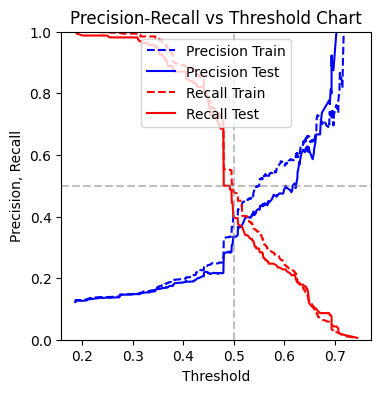

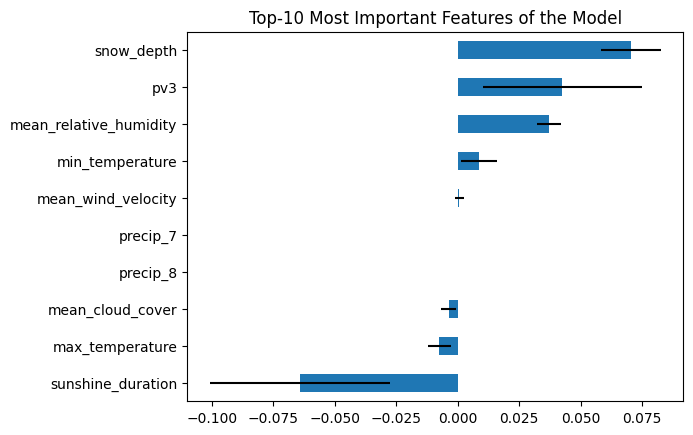


  1_XGB_Grid0_Rand1_f1
[14:16:00] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:16:00] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:16:01] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:16:01] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:16:01] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:16:01] WARNING: /Users/runner/work/xgboost/xgboost/python

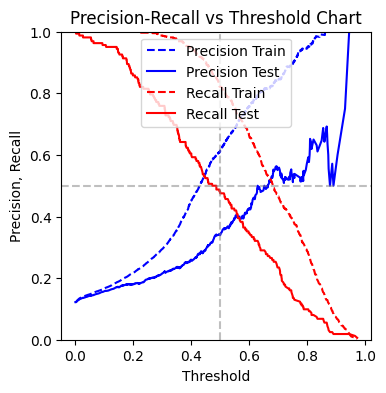

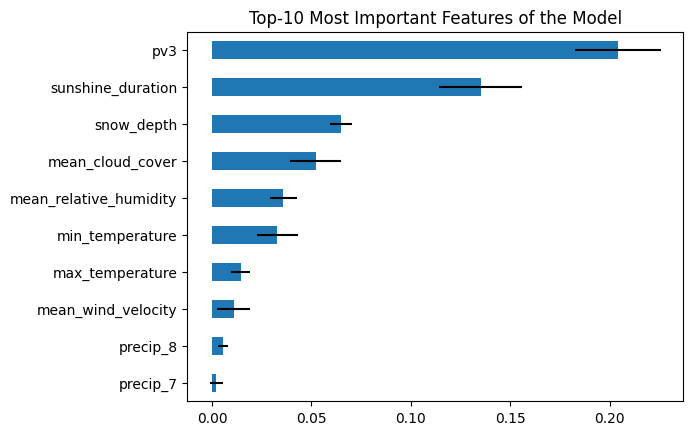


  2_XGB_Grid0_Rand2_recall
[14:16:07] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:16:08] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:16:08] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:16:08] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:16:08] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:16:08] WARNING: /Users/runner/work/xgboost/xgboost/py

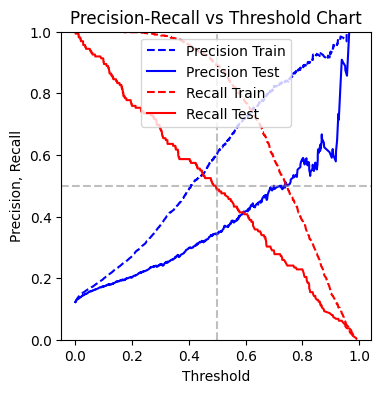

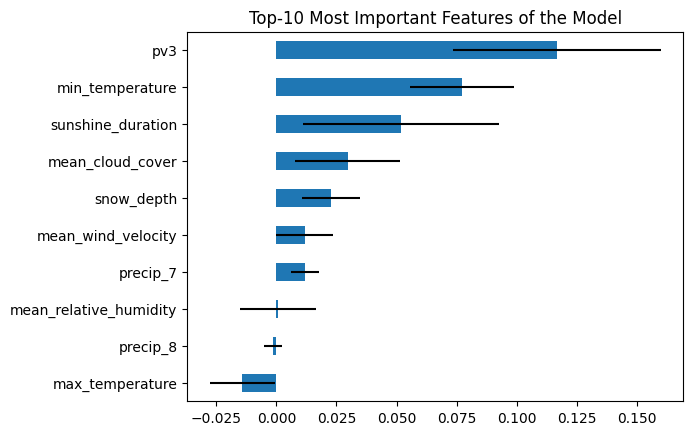


  3_XGB_Grid0_Rand2_f1
[14:16:14] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:16:15] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:16:15] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:16:15] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:16:15] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:16:16] WARNING: /Users/runner/work/xgboost/xgboost/python

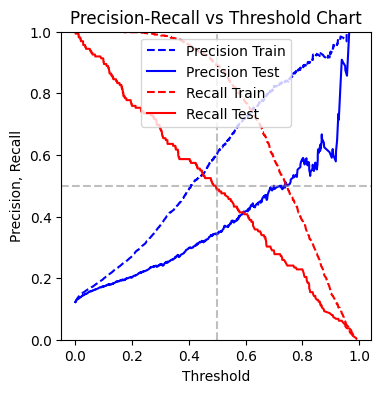

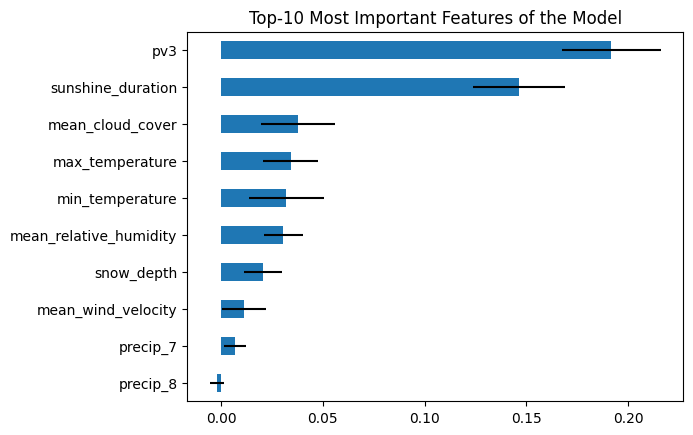


  4_XGB_Grid0_Rand3_recall
[14:16:21] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:16:22] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:16:22] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:16:22] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:16:22] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:16:22] WARNING: /Users/runner/work/xgboost/xgboost/py

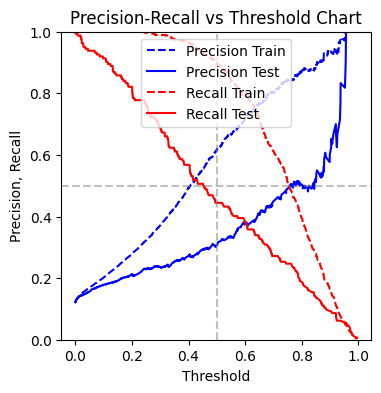

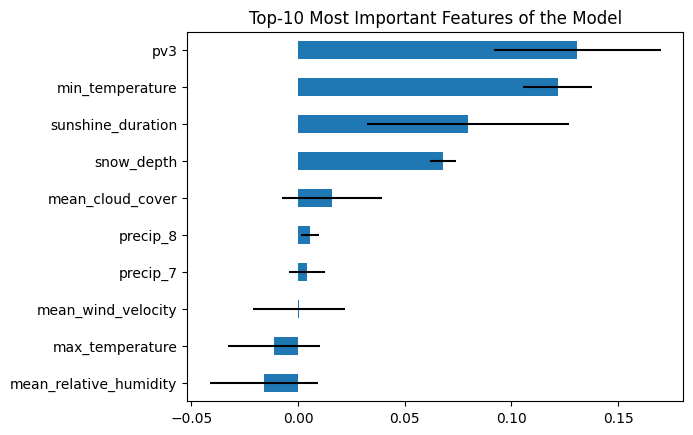


  5_XGB_Grid0_Rand3_f1
[14:16:30] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:16:30] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:16:30] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:16:30] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:16:30] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:16:30] WARNING: /Users/runner/work/xgboost/xgboost/python

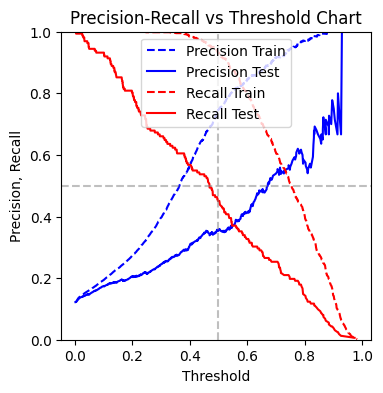

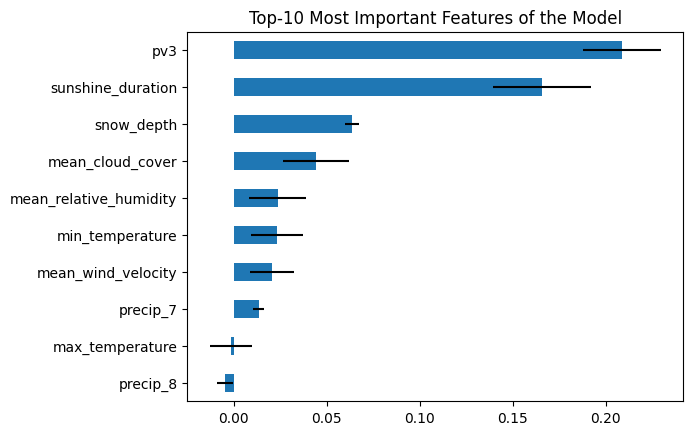


  6_XGB_Grid0_Rand4_recall
[14:16:37] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:16:38] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:16:38] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:16:38] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:16:38] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:16:38] WARNING: /Users/runner/work/xgboost/xgboost/py

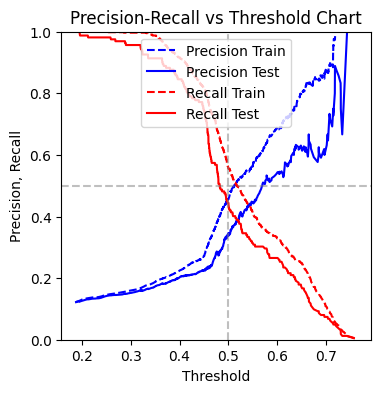

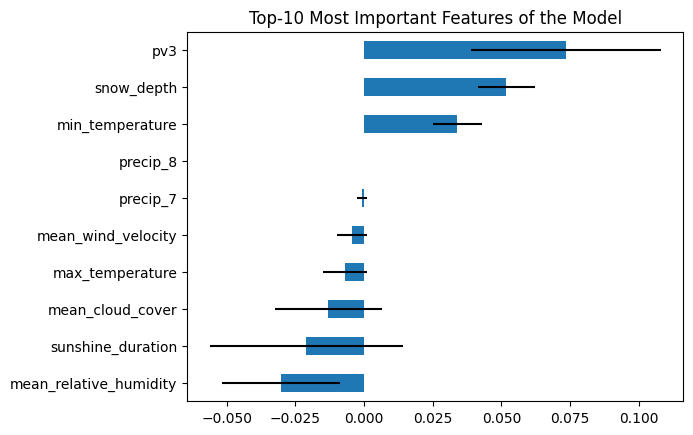


  7_XGB_Grid0_Rand4_f1
[14:16:46] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:16:46] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:16:46] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:16:46] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:16:47] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:16:47] WARNING: /Users/runner/work/xgboost/xgboost/python

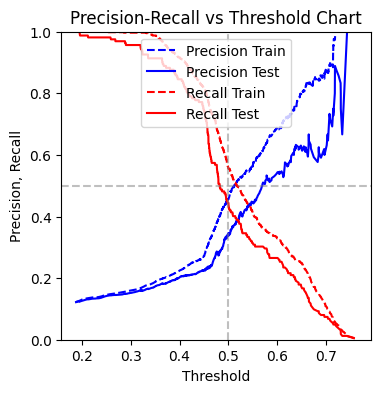

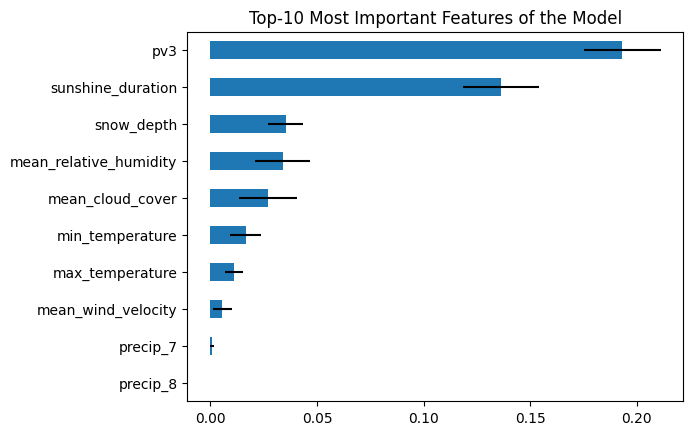


  8_XGB_Grid0_Rand5_recall
[14:16:54] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:16:55] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:16:55] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:16:55] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:16:56] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:16:56] WARNING: /Users/runner/work/xgboost/xgboost/py

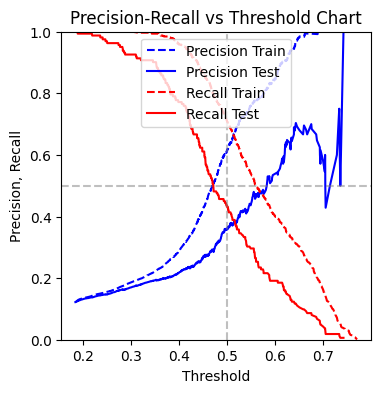

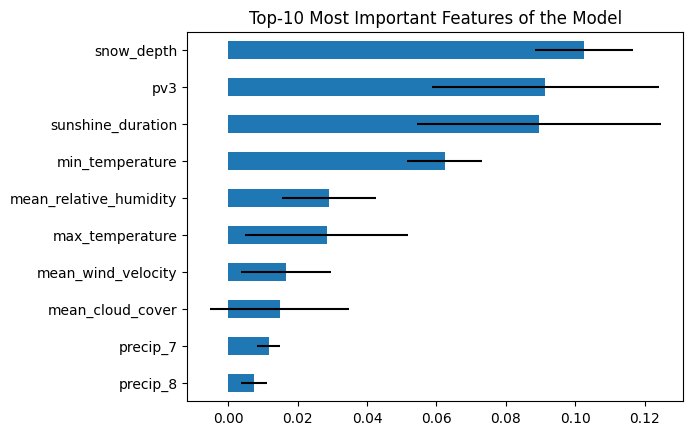


  9_XGB_Grid0_Rand5_f1
[14:17:04] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:17:04] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:17:05] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:17:06] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:17:06] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:17:06] WARNING: /Users/runner/work/xgboost/xgboost/python

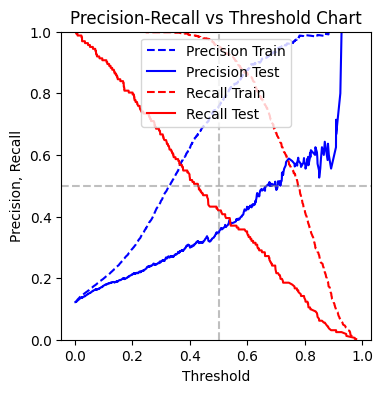

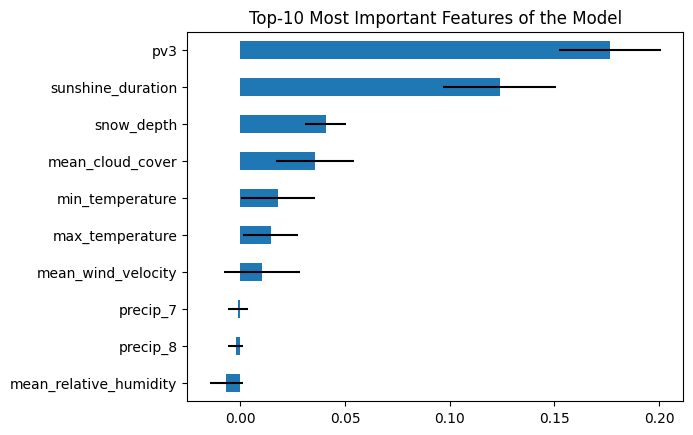


 10_XGB_Grid0_Rand6_recall
[14:17:15] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:17:15] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:17:15] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:17:15] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:17:16] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:17:16] WARNING: /Users/runner/work/xgboost/xgboost/py

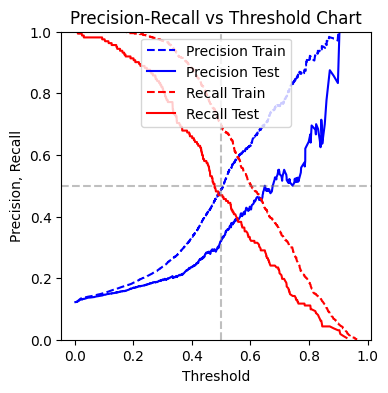

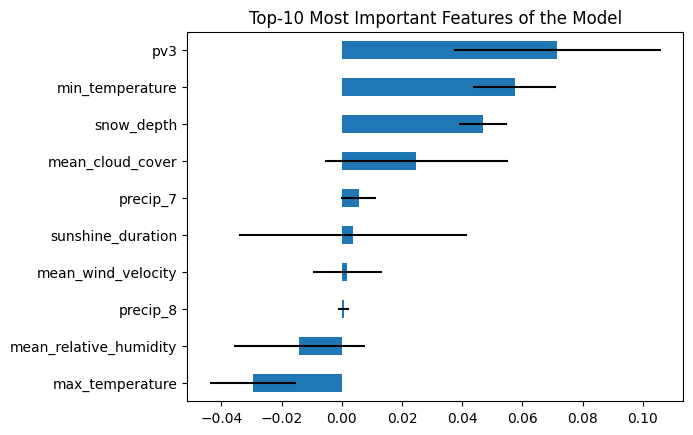


 11_XGB_Grid0_Rand6_f1
[14:17:24] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:17:24] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:17:24] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:17:24] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:17:25] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:17:25] WARNING: /Users/runner/work/xgboost/xgboost/python

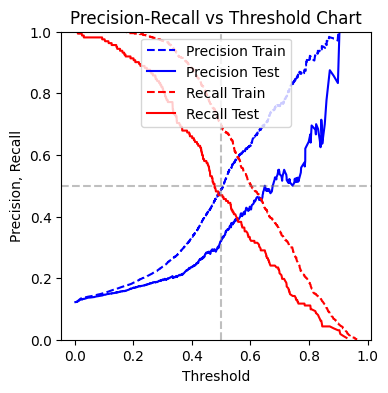

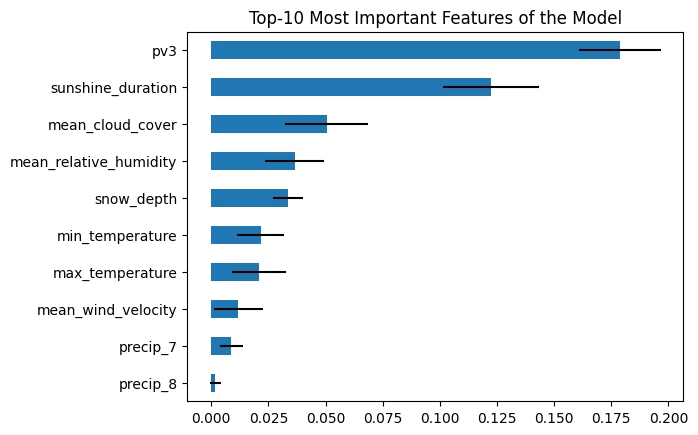


 12_XGB_Grid0_Rand7_recall
[14:17:32] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:17:33] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:17:33] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:17:34] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:17:34] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:17:34] WARNING: /Users/runner/work/xgboost/xgboost/py

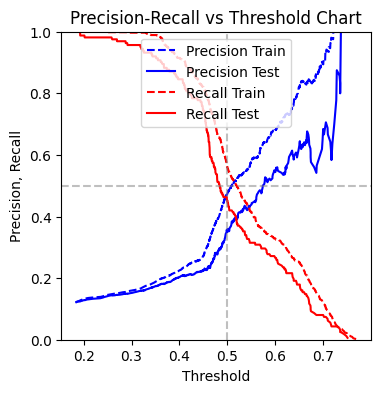

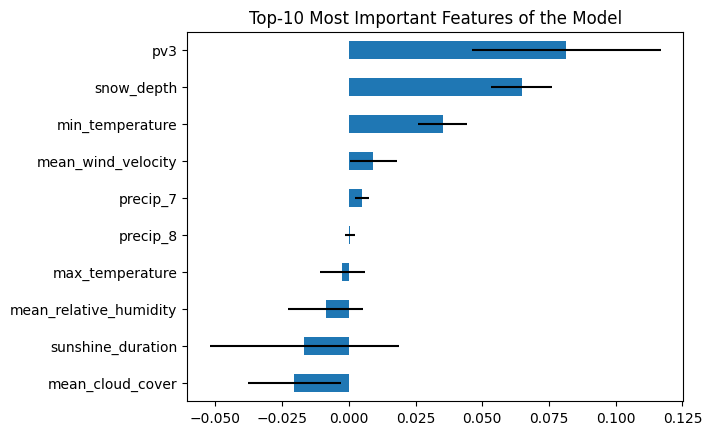


 13_XGB_Grid0_Rand7_f1
[14:17:42] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:17:43] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:17:43] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:17:44] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:17:44] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:17:44] WARNING: /Users/runner/work/xgboost/xgboost/python

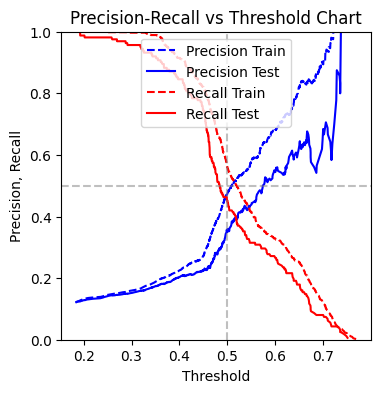

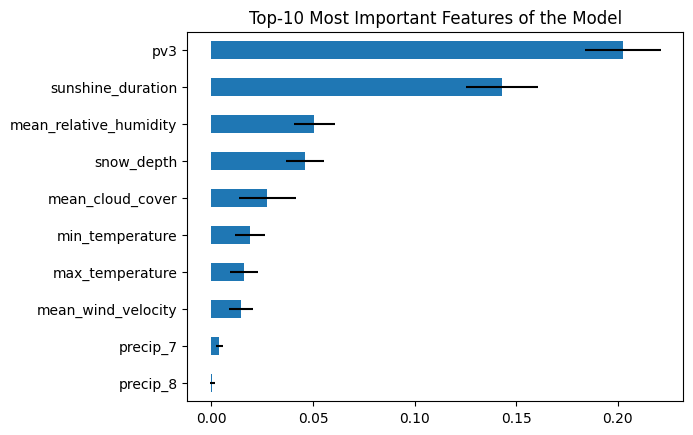


 14_XGB_Grid0_Rand8_recall
[14:17:53] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:17:53] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:17:54] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:17:54] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:17:54] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:17:55] WARNING: /Users/runner/work/xgboost/xgboost/py

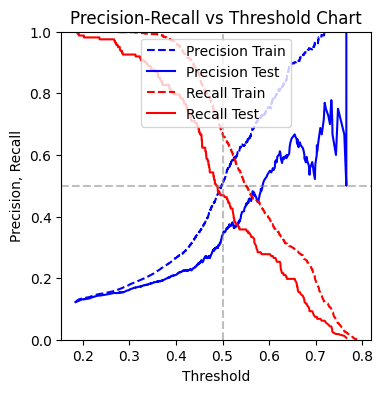

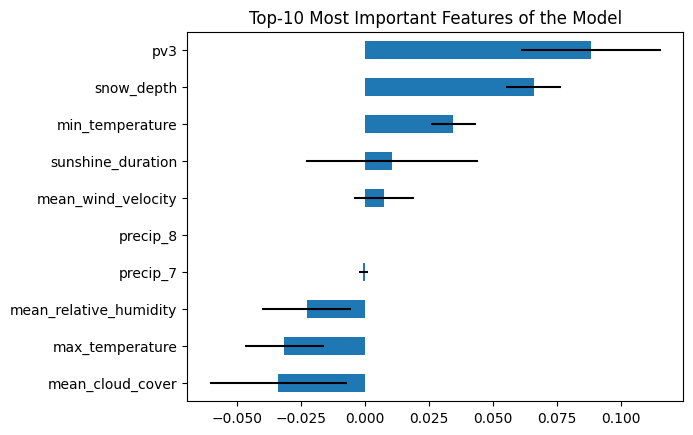


 15_XGB_Grid0_Rand8_f1
[14:18:02] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:18:03] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:18:03] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:18:03] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:18:04] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:18:04] WARNING: /Users/runner/work/xgboost/xgboost/python

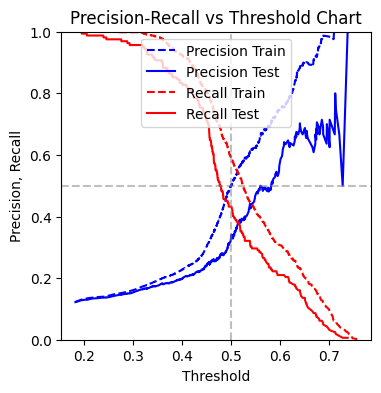

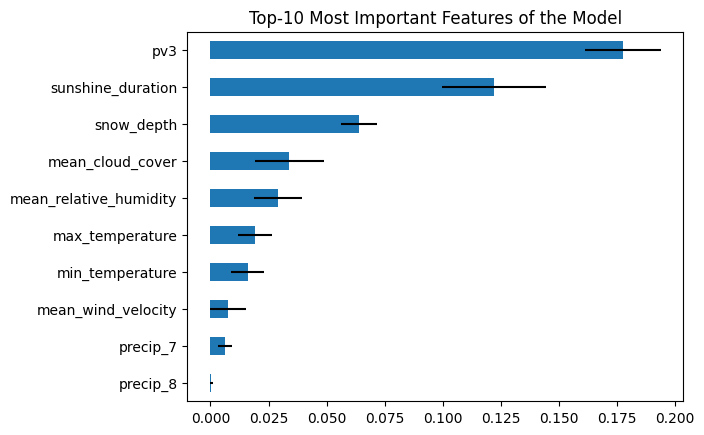


 16_XGB_Grid0_Rand9_recall
[14:18:13] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:18:13] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:18:13] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:18:14] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:18:14] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:18:14] WARNING: /Users/runner/work/xgboost/xgboost/py

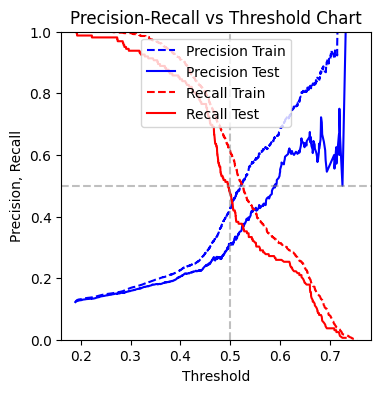

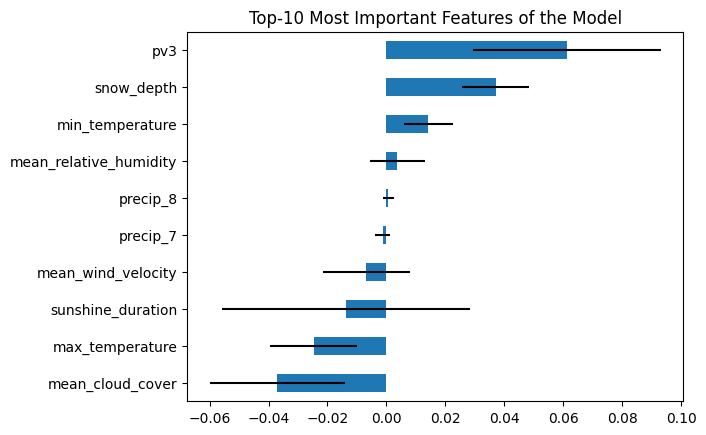


 17_XGB_Grid0_Rand9_f1
[14:18:23] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:18:23] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:18:23] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:18:23] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:18:24] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:18:24] WARNING: /Users/runner/work/xgboost/xgboost/python

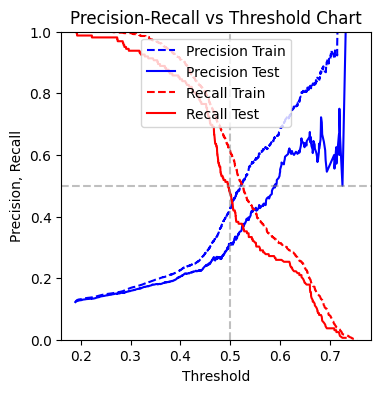

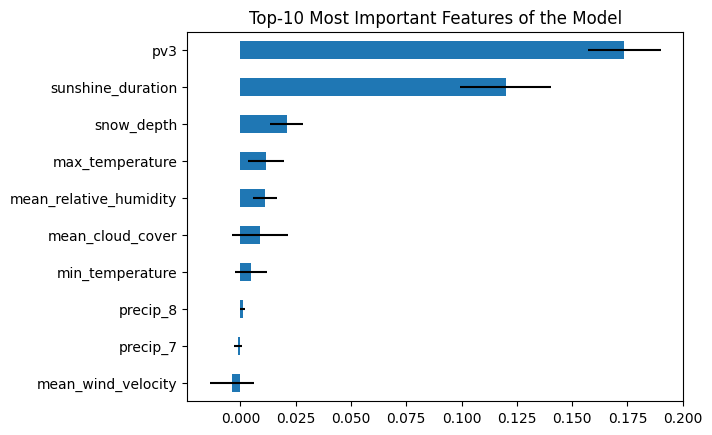


 18_XGB_Grid0_Rand10_recall
[14:18:31] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:18:32] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:18:32] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:18:33] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:18:33] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:18:34] WARNING: /Users/runner/work/xgboost/xgboost/p

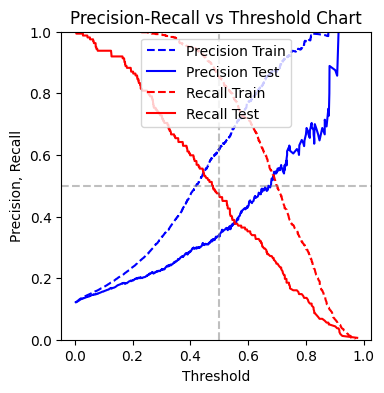

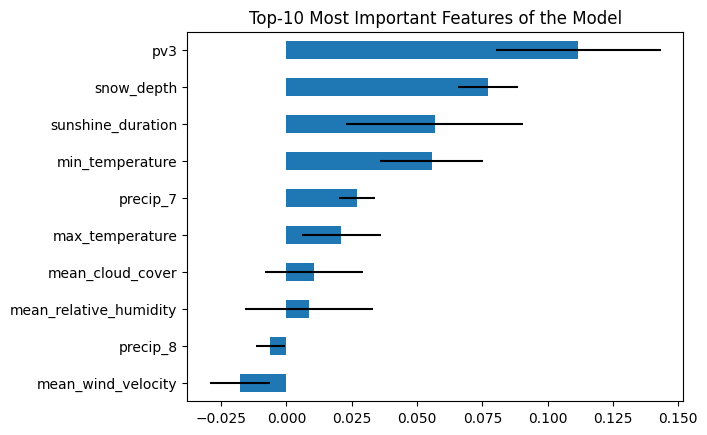


 19_XGB_Grid0_Rand10_f1
[14:18:41] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:18:42] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:18:42] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:18:43] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:18:43] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:18:43] WARNING: /Users/runner/work/xgboost/xgboost/pytho

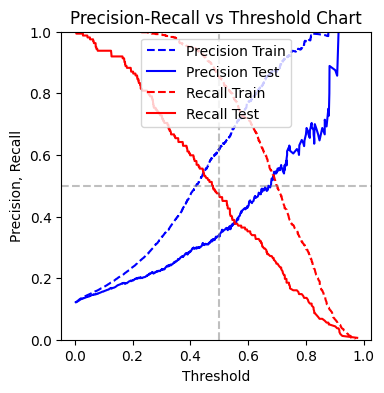

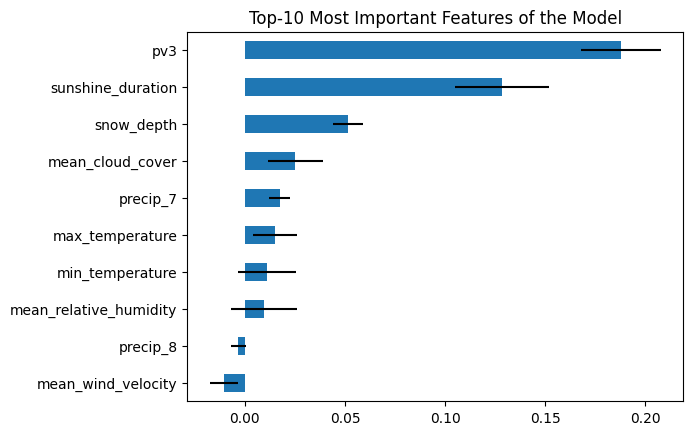


 20_XGB_Grid1_Rand1_recall
[14:18:51] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:18:53] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:18:53] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:18:54] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:18:54] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:18:54] WARNING: /Users/runner/work/xgboost/xgboost/py

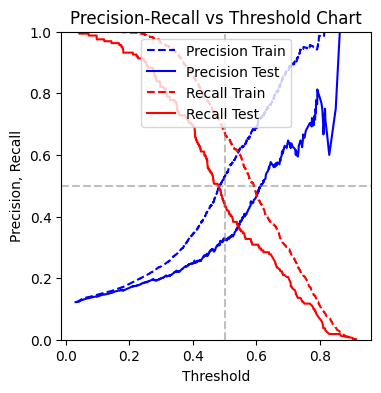

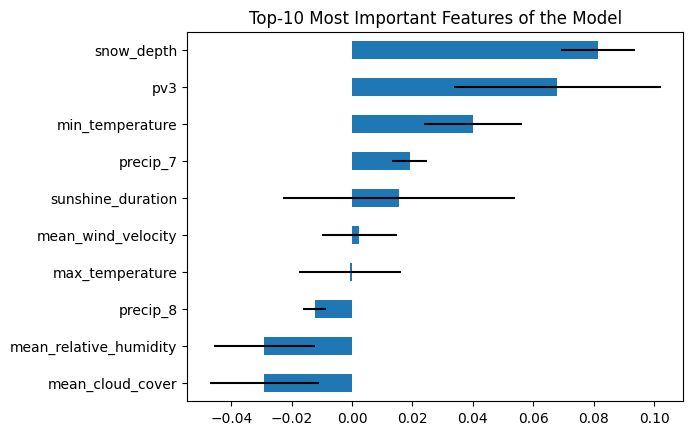


 21_XGB_Grid1_Rand1_f1
[14:19:02] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:19:03] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:19:04] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:19:04] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:19:05] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:19:05] WARNING: /Users/runner/work/xgboost/xgboost/python

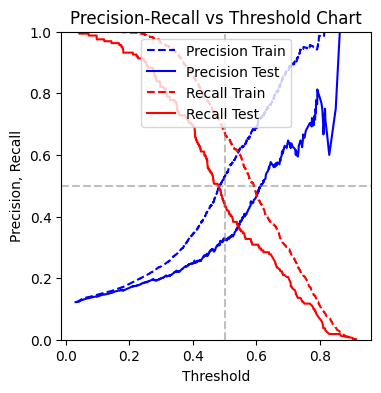

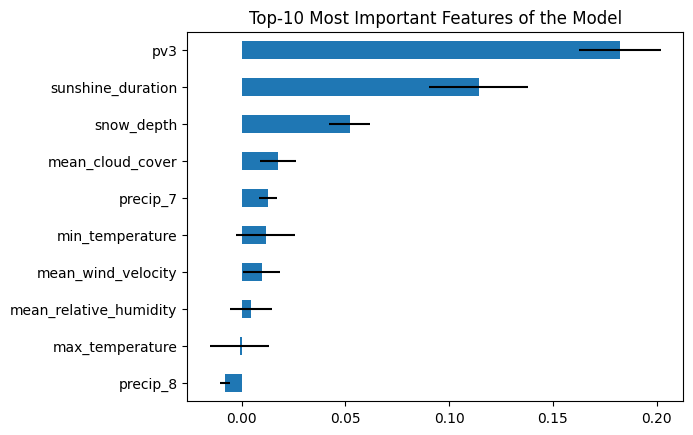


 22_XGB_Grid1_Rand2_recall
[14:19:13] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:19:13] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:19:14] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:19:14] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:19:15] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:19:15] WARNING: /Users/runner/work/xgboost/xgboost/py

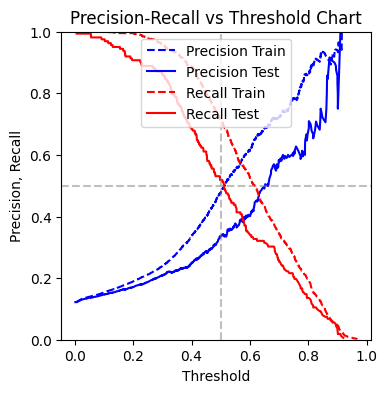

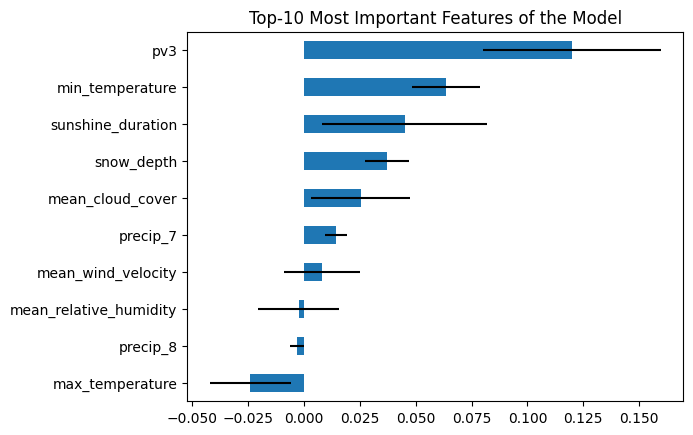


 23_XGB_Grid1_Rand2_f1
[14:19:25] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:19:25] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:19:26] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:19:26] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:19:26] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:19:27] WARNING: /Users/runner/work/xgboost/xgboost/python

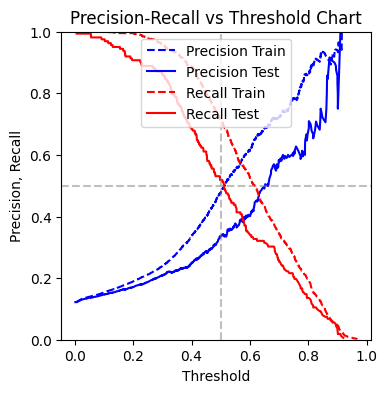

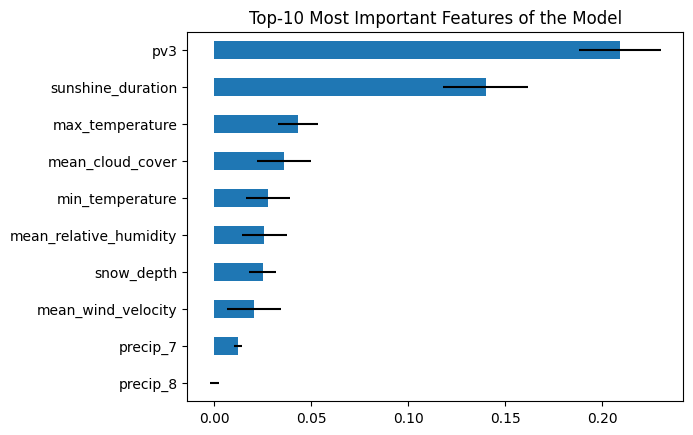


 24_XGB_Grid1_Rand3_recall
[14:19:37] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:19:37] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:19:38] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:19:38] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:19:38] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:19:39] WARNING: /Users/runner/work/xgboost/xgboost/py

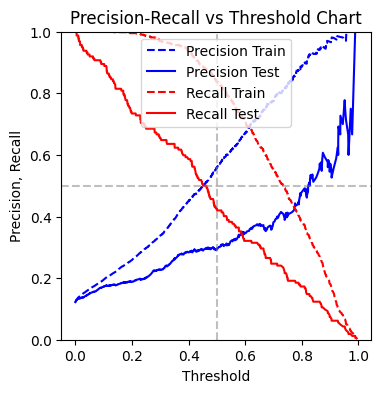

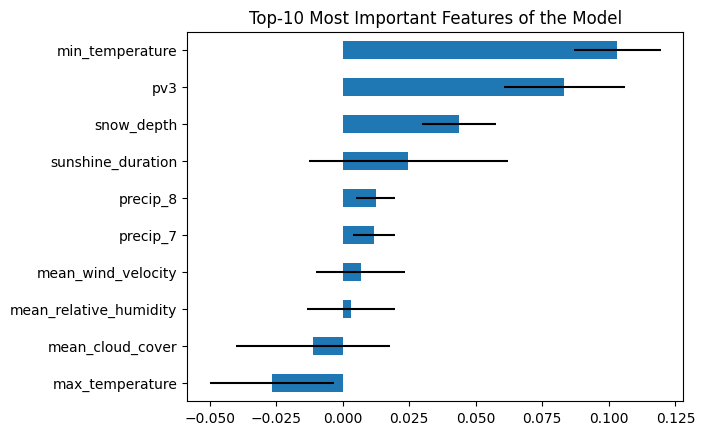


 25_XGB_Grid1_Rand3_f1
[14:19:46] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:19:46] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:19:47] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:19:47] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:19:48] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:19:48] WARNING: /Users/runner/work/xgboost/xgboost/python

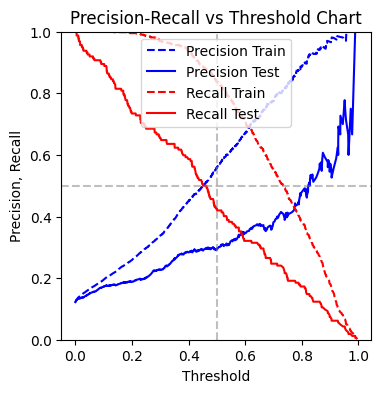

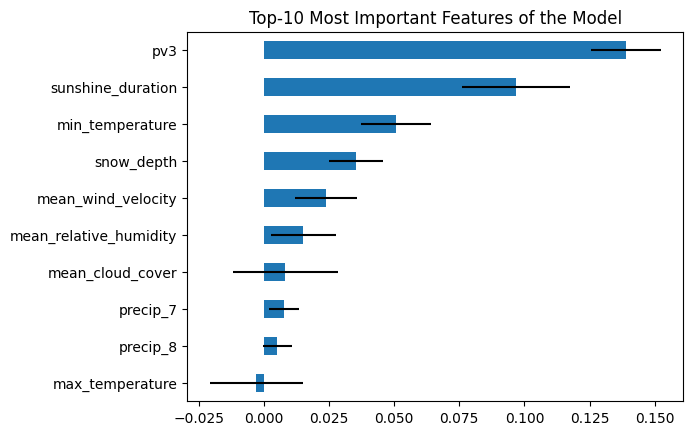


 26_XGB_Grid1_Rand4_recall
[14:19:56] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:19:56] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:19:57] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:19:57] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:19:57] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:19:58] WARNING: /Users/runner/work/xgboost/xgboost/py

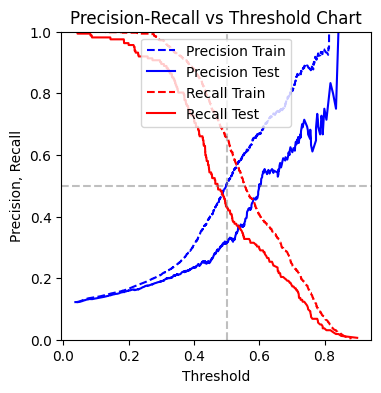

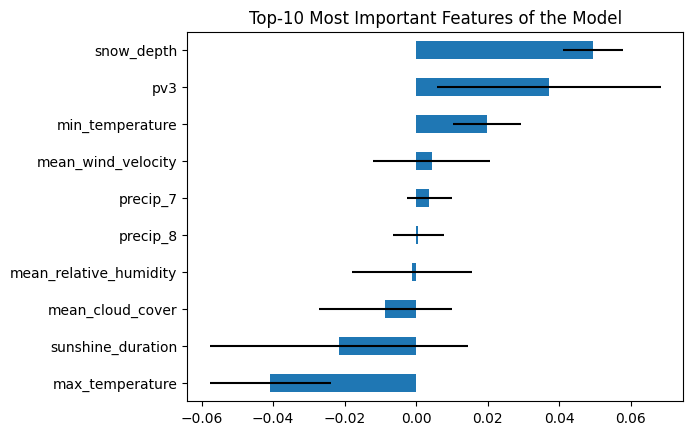


 27_XGB_Grid1_Rand4_f1
[14:20:08] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:20:09] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:20:09] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:20:09] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:20:10] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:20:10] WARNING: /Users/runner/work/xgboost/xgboost/python

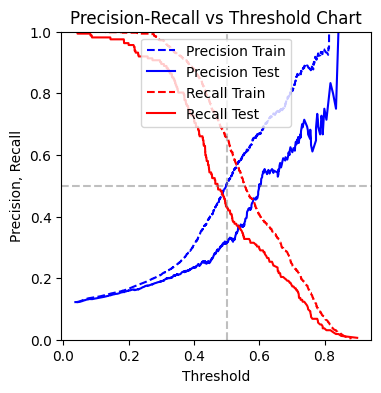

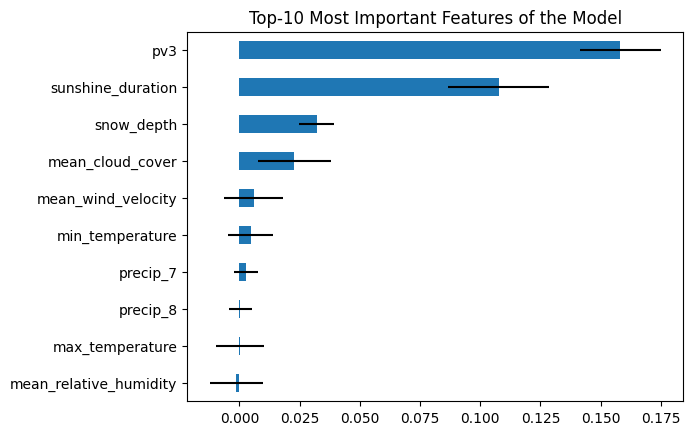


 28_XGB_Grid1_Rand5_recall
[14:20:21] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:20:21] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:20:21] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:20:22] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:20:22] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:20:23] WARNING: /Users/runner/work/xgboost/xgboost/py

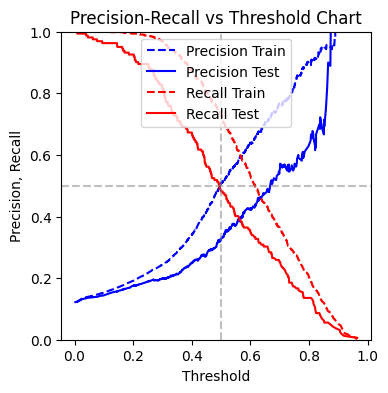

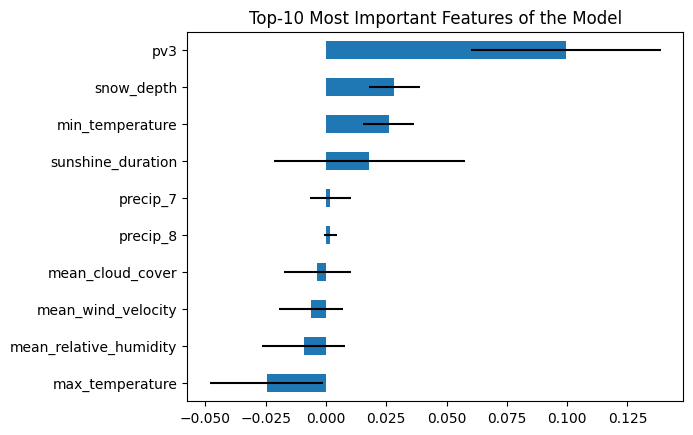


 29_XGB_Grid1_Rand5_f1
[14:20:32] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:20:32] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:20:33] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:20:33] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:20:33] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:20:34] WARNING: /Users/runner/work/xgboost/xgboost/python

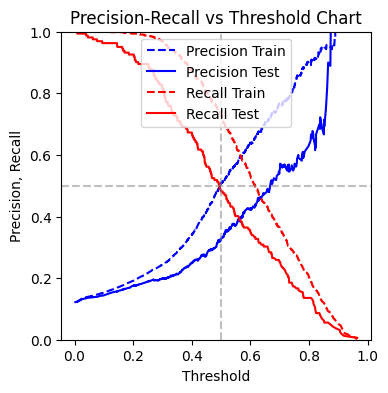

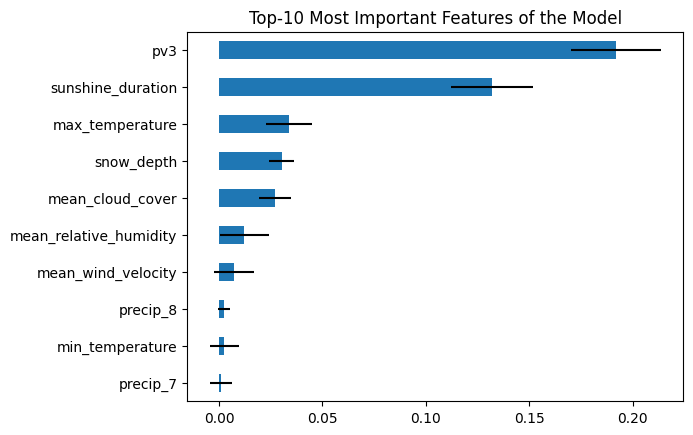


 30_XGB_Grid1_Rand6_recall
[14:20:42] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:20:42] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:20:42] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:20:43] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:20:44] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:20:45] WARNING: /Users/runner/work/xgboost/xgboost/py

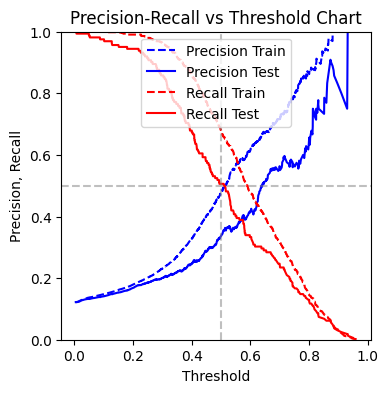

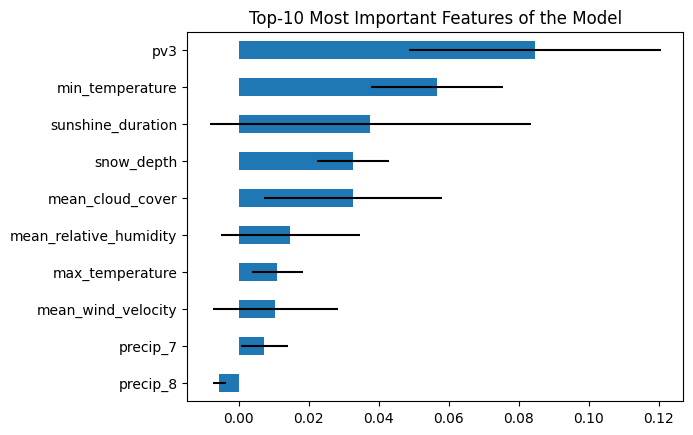


 31_XGB_Grid1_Rand6_f1
[14:20:55] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:20:55] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:20:55] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:20:56] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:20:56] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:20:57] WARNING: /Users/runner/work/xgboost/xgboost/python

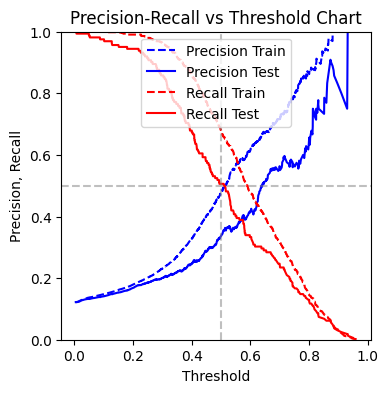

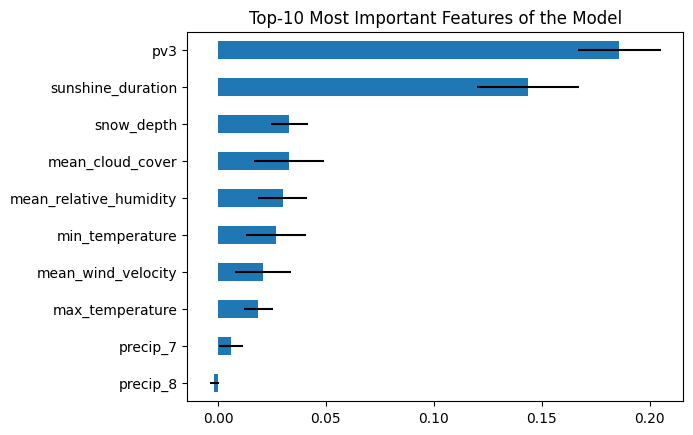


 32_XGB_Grid1_Rand7_recall
[14:21:04] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:21:05] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:21:05] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:21:05] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:21:06] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:21:06] WARNING: /Users/runner/work/xgboost/xgboost/py

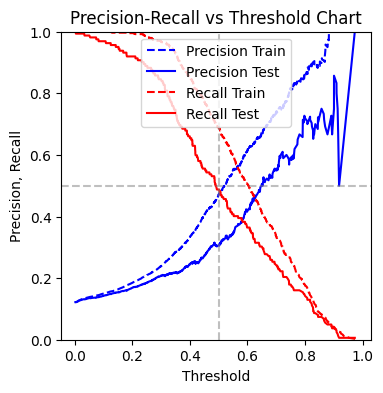

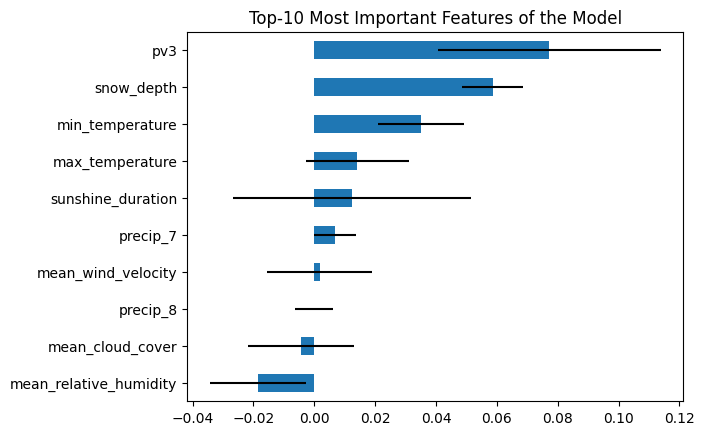


 33_XGB_Grid1_Rand7_f1
[14:21:16] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:21:16] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:21:16] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:21:16] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:21:17] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:21:17] WARNING: /Users/runner/work/xgboost/xgboost/python

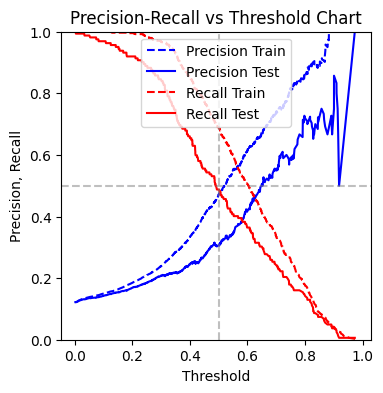

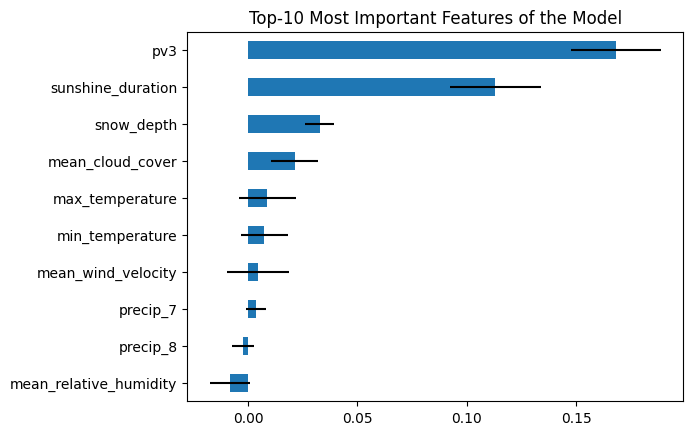


 34_XGB_Grid1_Rand8_recall
[14:21:25] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:21:26] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:21:26] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:21:26] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:21:26] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:21:27] WARNING: /Users/runner/work/xgboost/xgboost/py

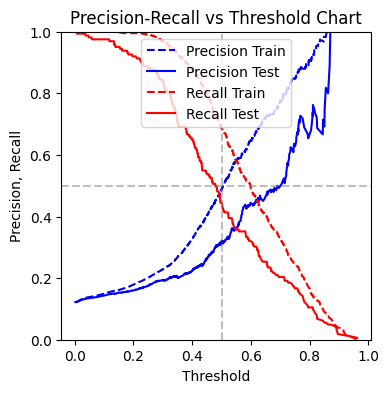

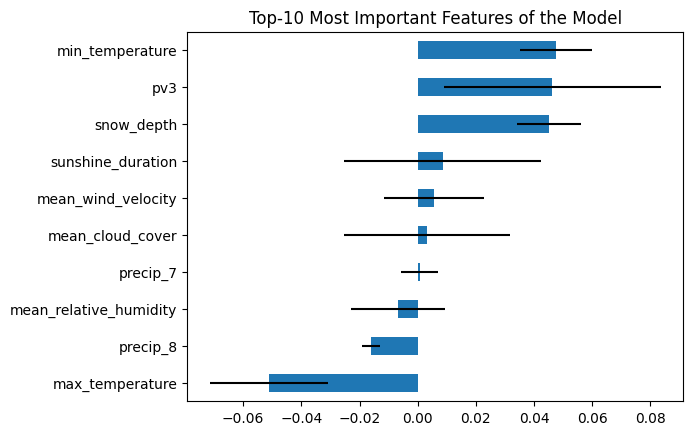


 35_XGB_Grid1_Rand8_f1
[14:21:35] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:21:36] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:21:36] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:21:36] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:21:36] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:21:36] WARNING: /Users/runner/work/xgboost/xgboost/python

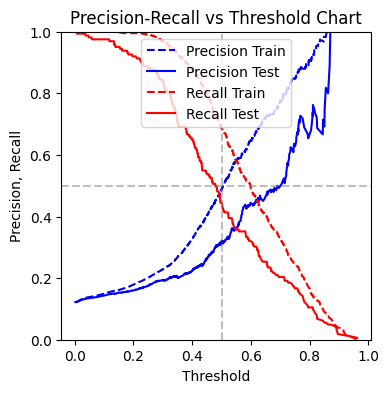

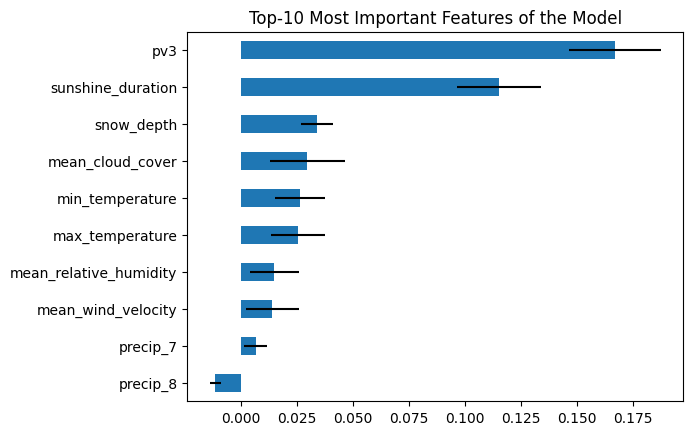


 36_XGB_Grid1_Rand9_recall
[14:21:45] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:21:45] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:21:45] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:21:46] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:21:46] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:21:46] WARNING: /Users/runner/work/xgboost/xgboost/py

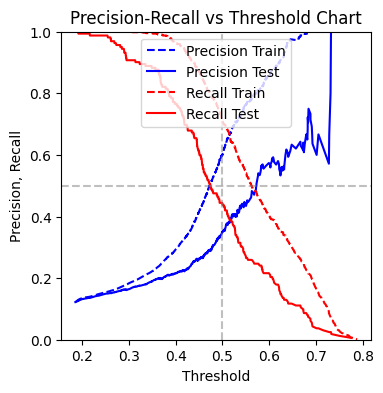

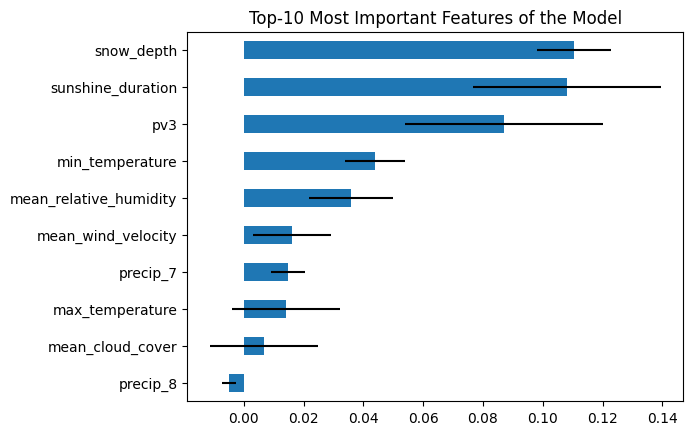


 37_XGB_Grid1_Rand9_f1
[14:21:55] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:21:56] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:21:57] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:21:57] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:21:57] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:21:57] WARNING: /Users/runner/work/xgboost/xgboost/python

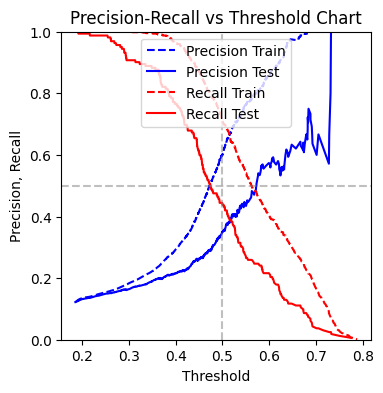

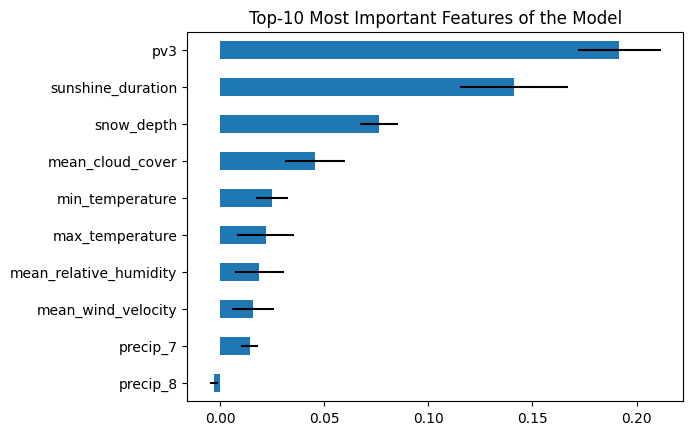


 38_XGB_Grid1_Rand10_recall
[14:22:07] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:22:07] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:22:08] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:22:08] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:22:09] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:22:09] WARNING: /Users/runner/work/xgboost/xgboost/p

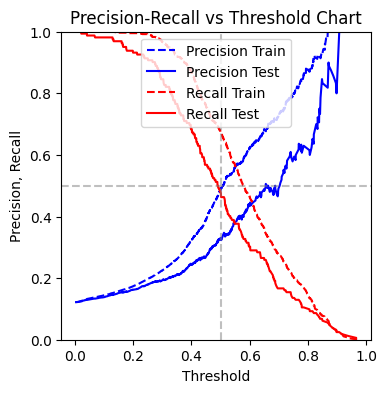

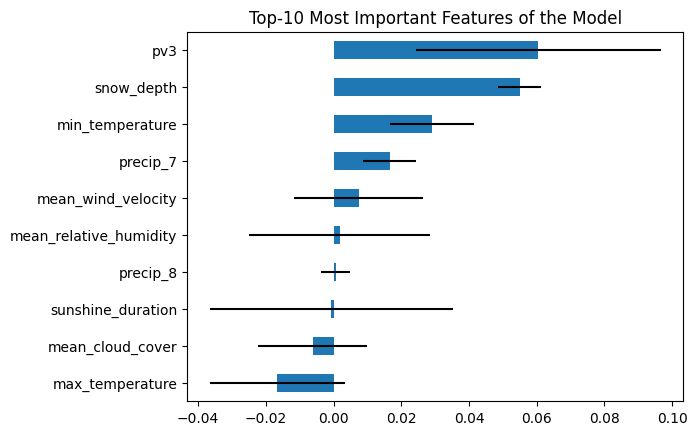


 39_XGB_Grid1_Rand10_f1
[14:22:17] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:22:18] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:22:19] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:22:20] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:22:20] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:22:21] WARNING: /Users/runner/work/xgboost/xgboost/pytho

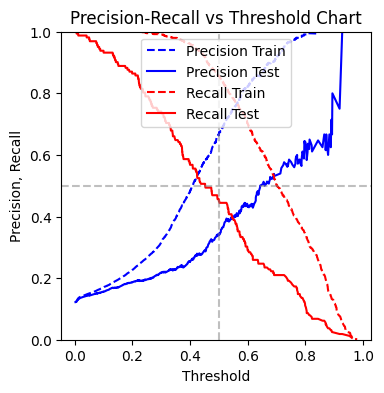

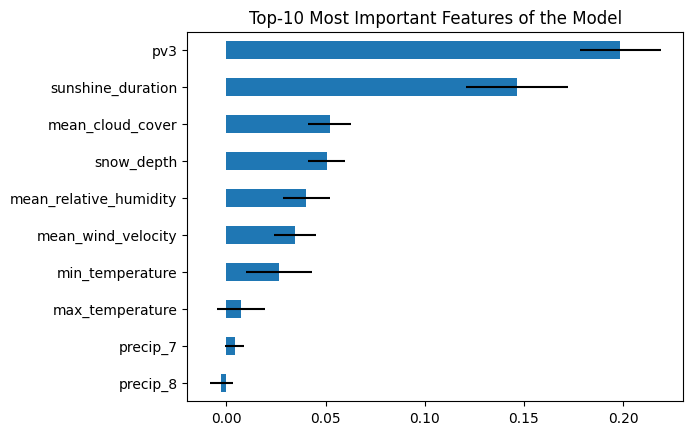


 40_XGB_Grid2_Rand1_recall
[14:22:31] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:22:31] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:22:31] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:22:31] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:22:31] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:22:32] WARNING: /Users/runner/work/xgboost/xgboost/py

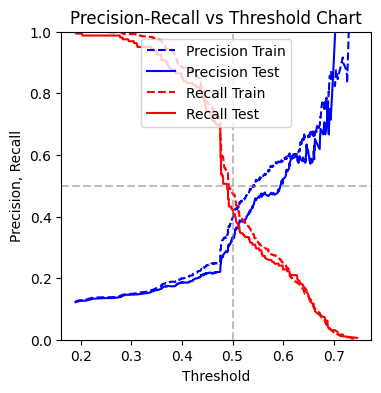

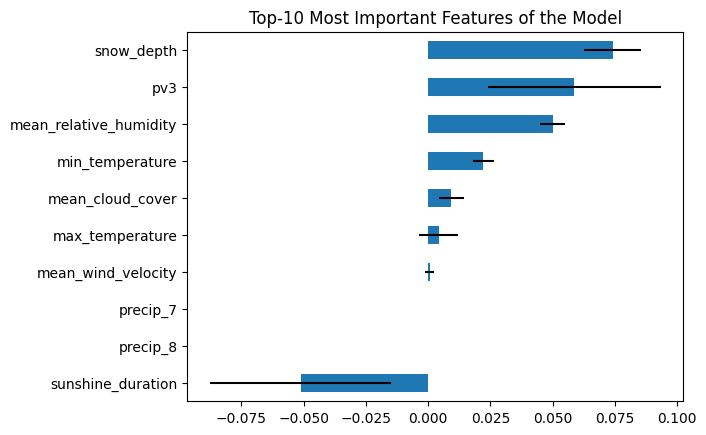


 41_XGB_Grid2_Rand1_f1
[14:23:07] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:23:07] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:23:07] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:23:07] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:23:08] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:23:08] WARNING: /Users/runner/work/xgboost/xgboost/python

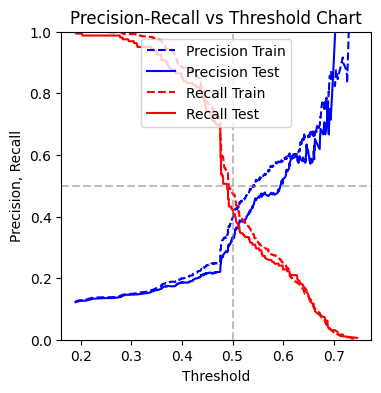

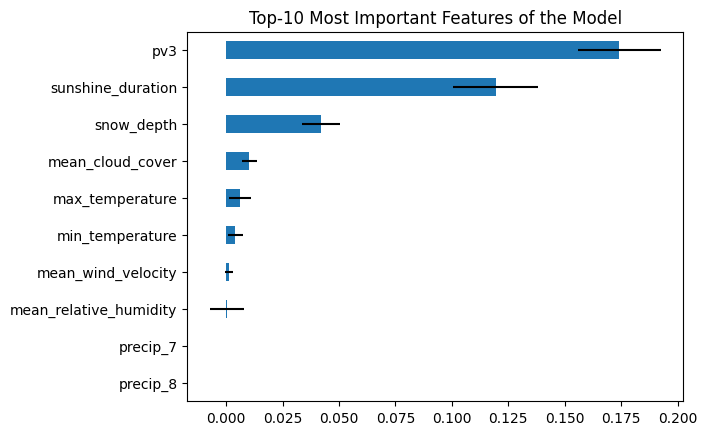


 42_XGB_Grid2_Rand2_recall
[14:23:45] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:23:45] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:23:45] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:23:45] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:23:45] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:23:45] WARNING: /Users/runner/work/xgboost/xgboost/py

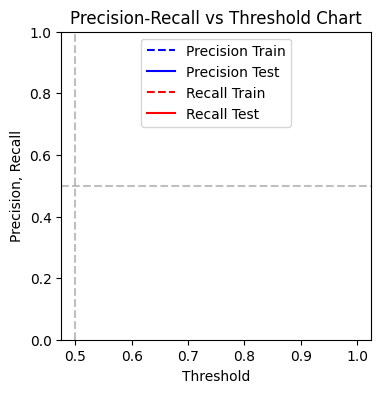

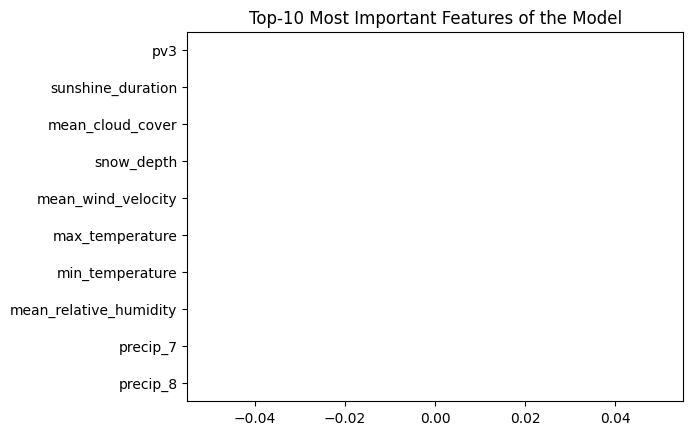


 43_XGB_Grid2_Rand2_f1
[14:24:09] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:24:09] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:24:09] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:24:09] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:24:09] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:24:09] WARNING: /Users/runner/work/xgboost/xgboost/python

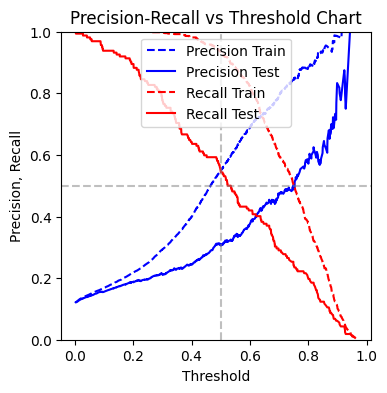

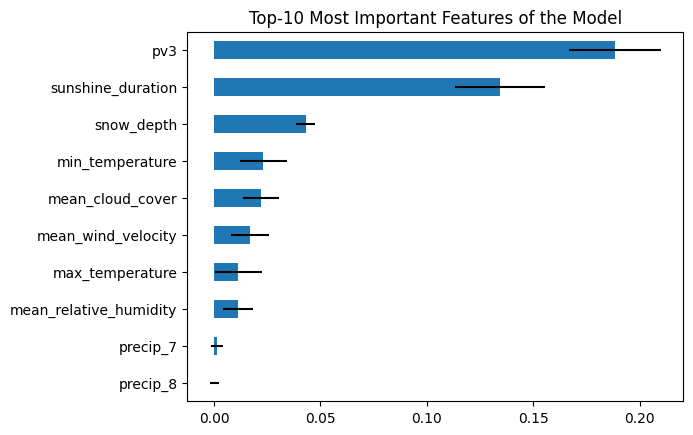


 44_XGB_Grid2_Rand3_recall
[14:24:37] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:24:37] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:24:37] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:24:37] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:24:37] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:24:37] WARNING: /Users/runner/work/xgboost/xgboost/py

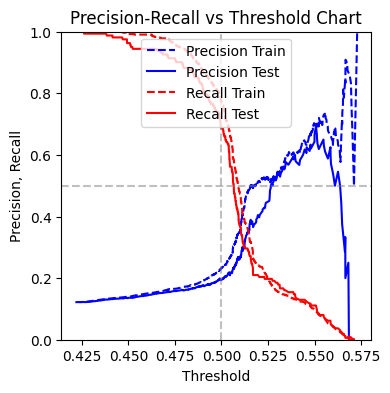

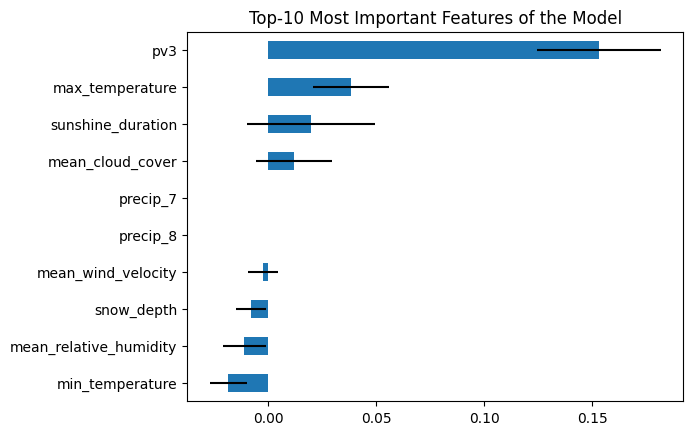


 45_XGB_Grid2_Rand3_f1
[14:24:46] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:24:46] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:24:46] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:24:46] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:24:46] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:24:46] WARNING: /Users/runner/work/xgboost/xgboost/python

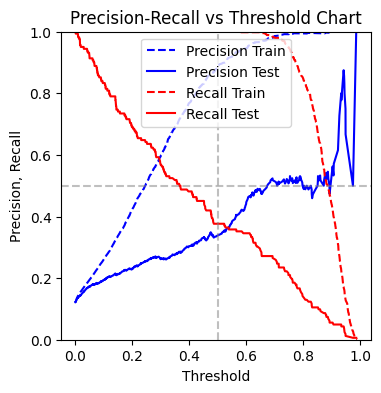

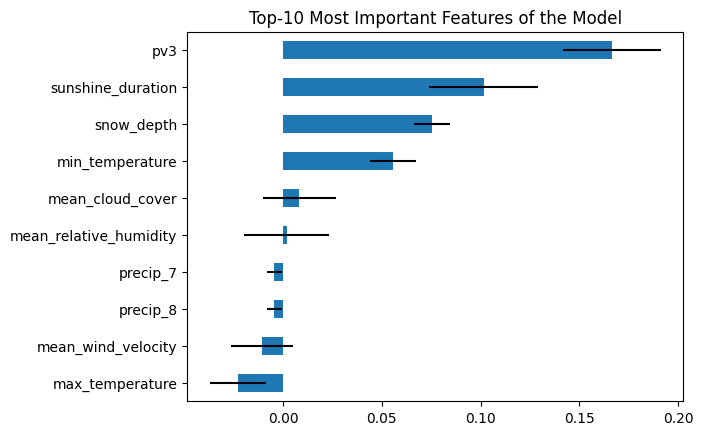


 46_XGB_Grid2_Rand4_recall
[14:24:56] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:24:58] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:24:59] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:25:00] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:25:04] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:25:08] WARNING: /Users/runner/work/xgboost/xgboost/py

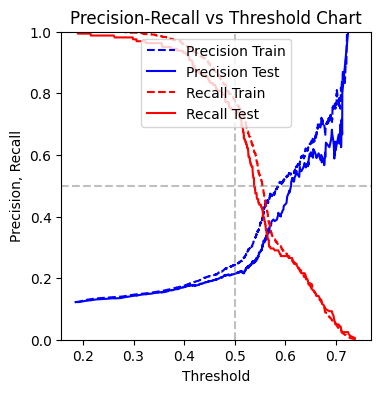

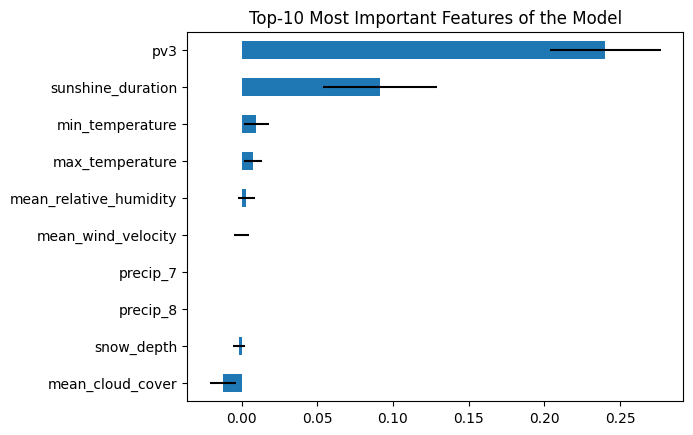


 47_XGB_Grid2_Rand4_f1
[14:25:43] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:25:44] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:25:45] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:25:46] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:25:50] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:25:55] WARNING: /Users/runner/work/xgboost/xgboost/python

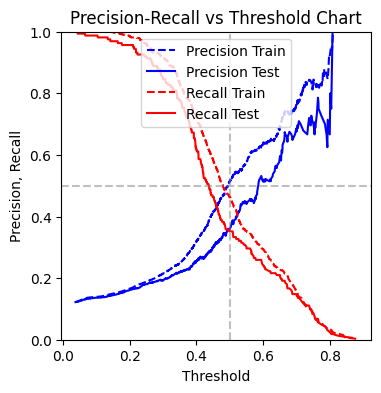

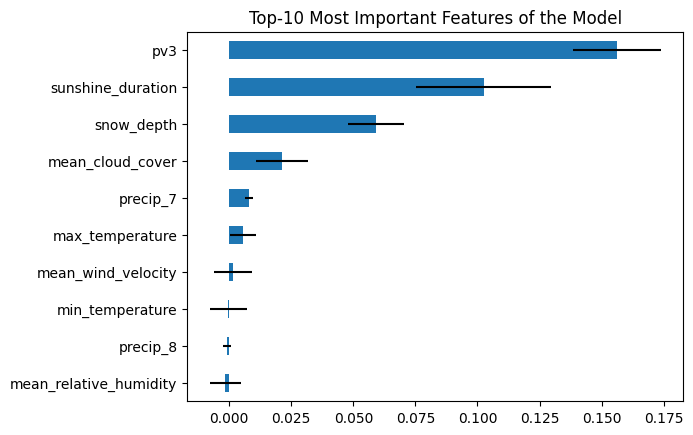


 48_XGB_Grid2_Rand5_recall
[14:26:33] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:26:33] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:26:34] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:26:34] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:26:35] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:26:36] WARNING: /Users/runner/work/xgboost/xgboost/py

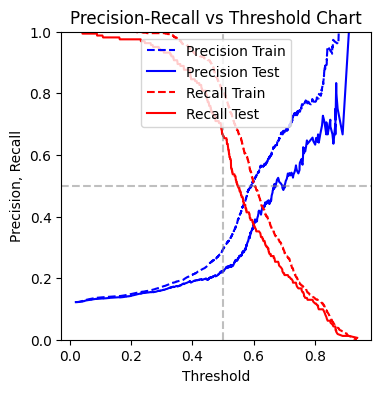

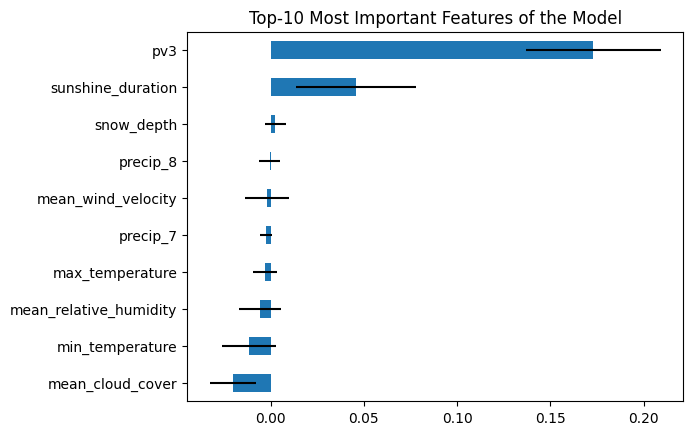


 49_XGB_Grid2_Rand5_f1
[14:26:55] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:26:55] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:26:56] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:26:56] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:26:57] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:26:58] WARNING: /Users/runner/work/xgboost/xgboost/python

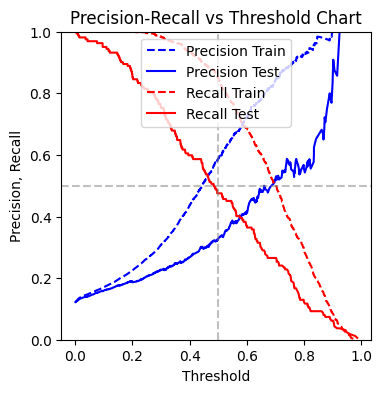

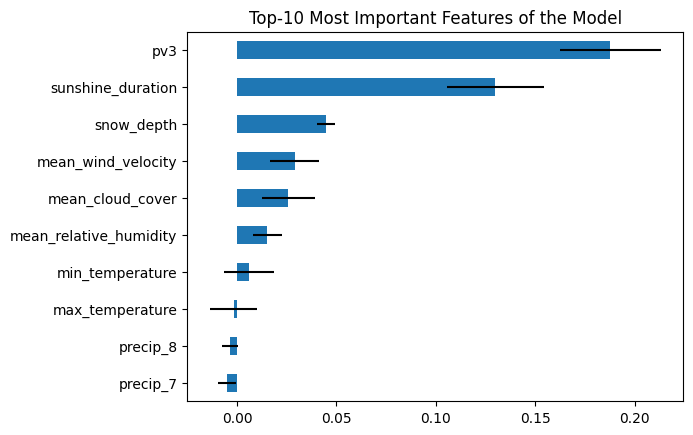


 50_XGB_Grid2_Rand6_recall
[14:27:17] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:27:18] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:27:19] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:27:19] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:27:21] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:27:24] WARNING: /Users/runner/work/xgboost/xgboost/py

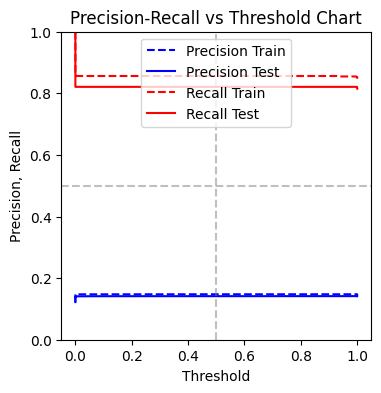

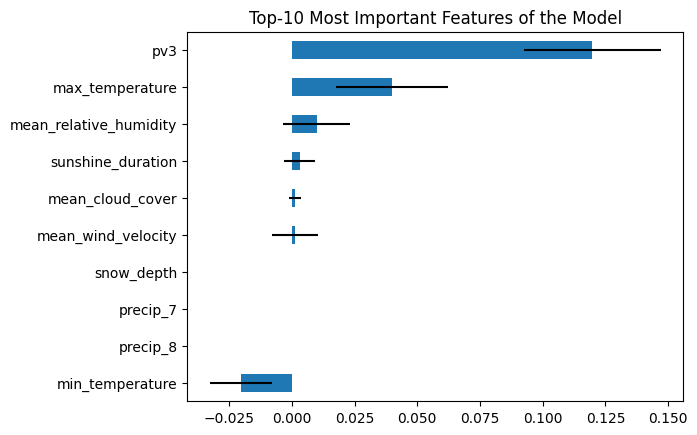


 51_XGB_Grid2_Rand6_f1
[14:27:48] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:27:49] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:27:50] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:27:51] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:27:52] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:27:54] WARNING: /Users/runner/work/xgboost/xgboost/python

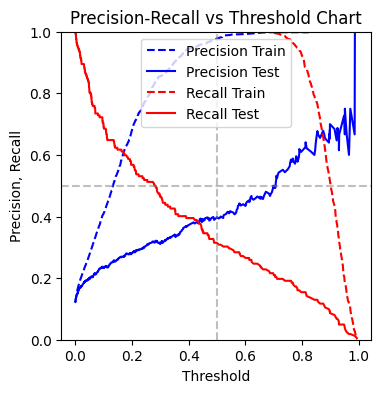

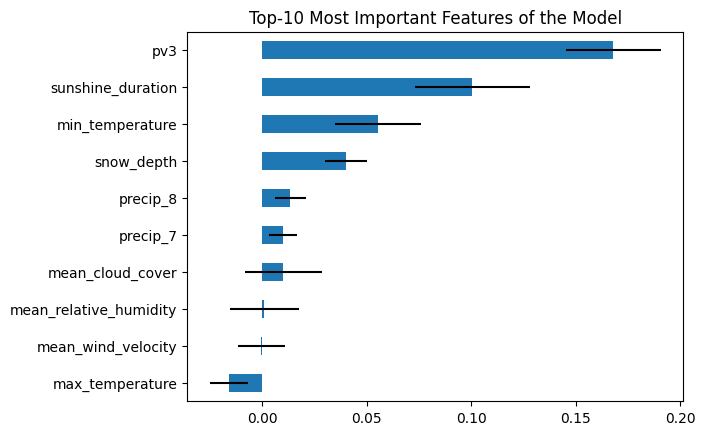


 52_XGB_Grid2_Rand7_recall
[14:28:23] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:28:23] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:28:23] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:28:24] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:28:24] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:28:25] WARNING: /Users/runner/work/xgboost/xgboost/py

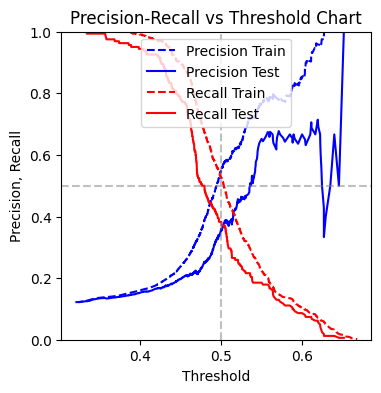

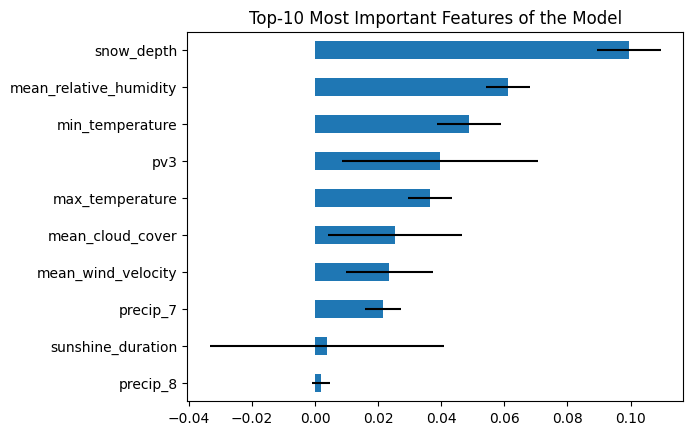


 53_XGB_Grid2_Rand7_f1
[14:28:38] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:28:38] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:28:38] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:28:38] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:28:40] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:28:43] WARNING: /Users/runner/work/xgboost/xgboost/python

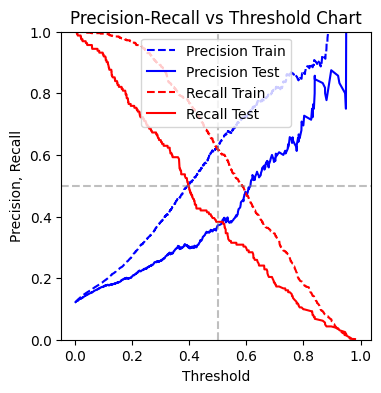

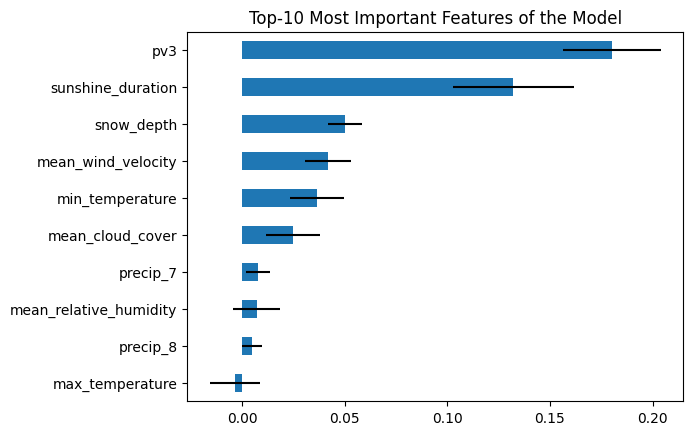


 54_XGB_Grid2_Rand8_recall
[14:28:55] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:28:56] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:28:56] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:28:56] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:28:58] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:29:00] WARNING: /Users/runner/work/xgboost/xgboost/py

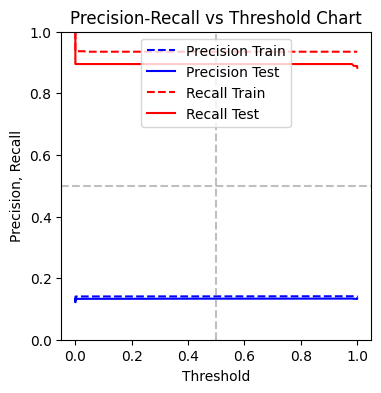

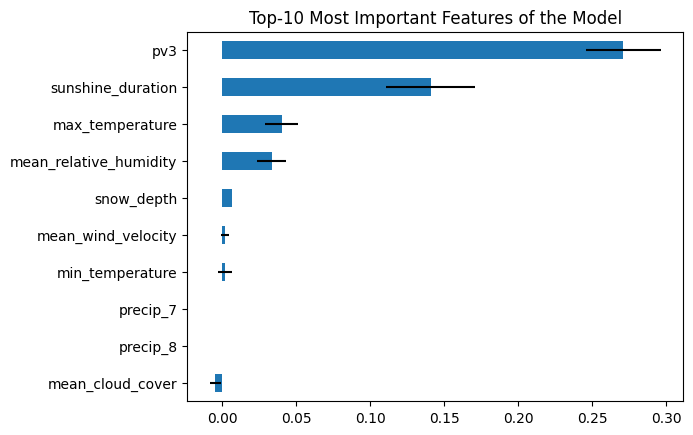


 55_XGB_Grid2_Rand8_f1
[14:29:14] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:29:15] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:29:15] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:29:15] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:29:17] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:29:19] WARNING: /Users/runner/work/xgboost/xgboost/python

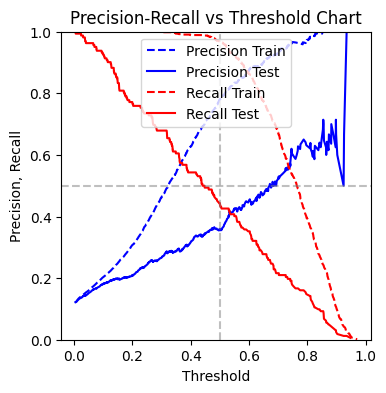

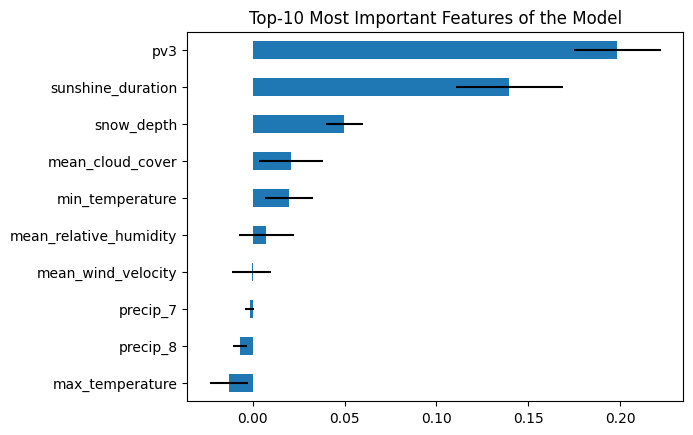


 56_XGB_Grid2_Rand9_recall
[14:29:33] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:29:35] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:29:37] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:29:39] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:29:39] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:29:39] WARNING: /Users/runner/work/xgboost/xgboost/py

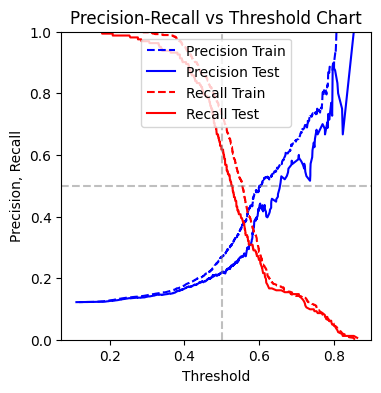

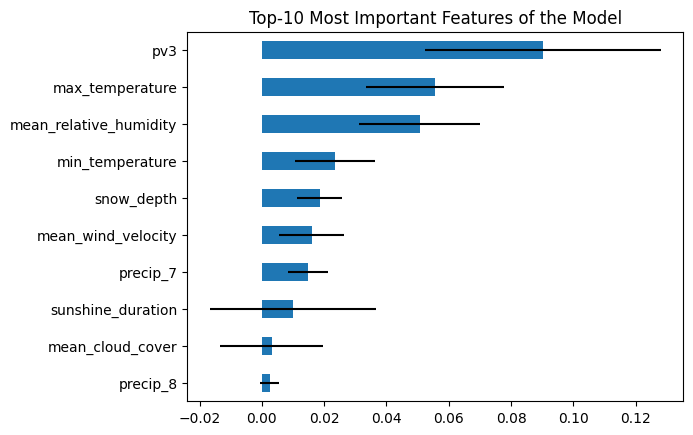


 57_XGB_Grid2_Rand9_f1
[14:30:01] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:30:02] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:30:04] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:30:07] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:30:07] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:30:07] WARNING: /Users/runner/work/xgboost/xgboost/python

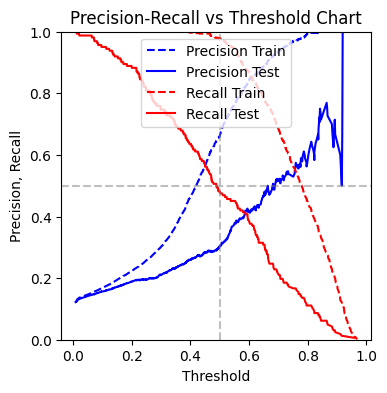

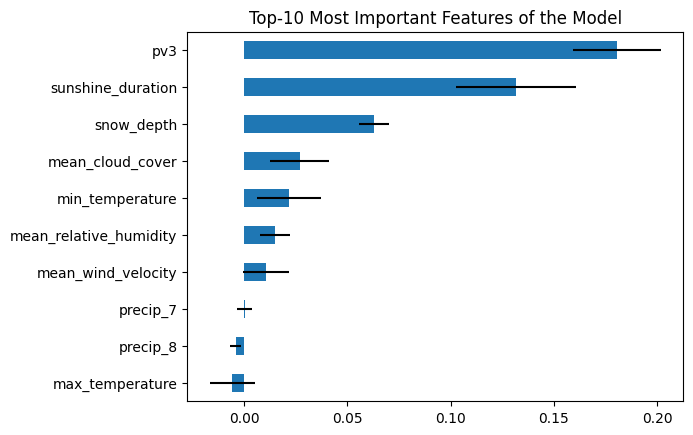


 58_XGB_Grid2_Rand10_recall
[14:30:34] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:30:34] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:30:34] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:30:34] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:30:34] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:30:35] WARNING: /Users/runner/work/xgboost/xgboost/p

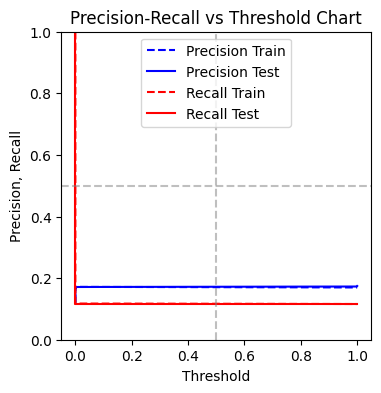

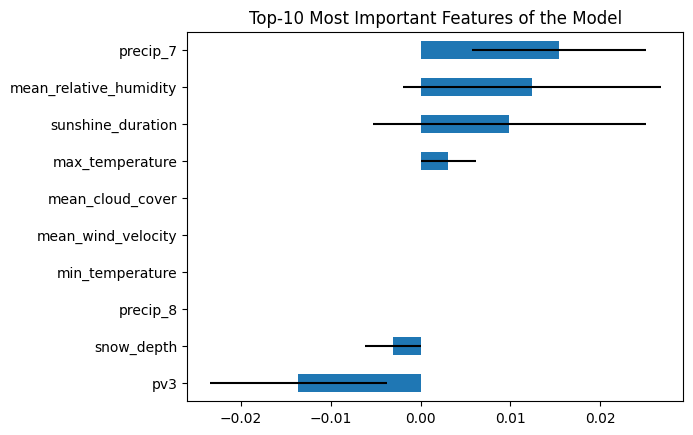


 59_XGB_Grid2_Rand10_f1
[14:30:49] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:30:49] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:30:49] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:30:49] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:30:49] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:30:49] WARNING: /Users/runner/work/xgboost/xgboost/pytho

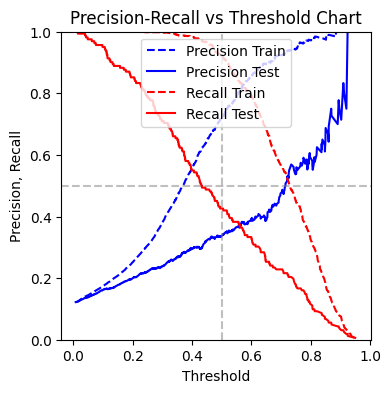

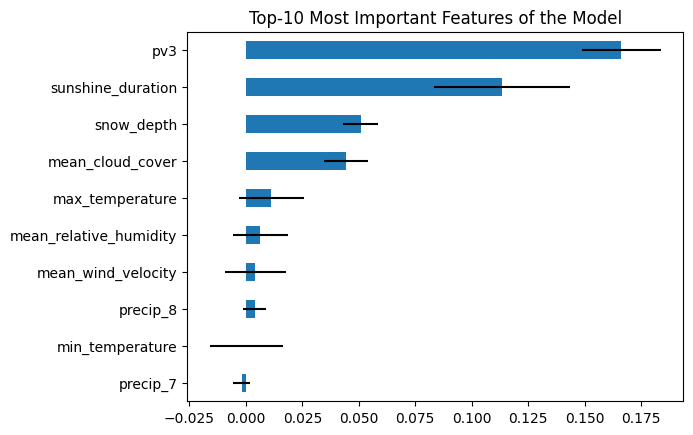

In [14]:
# runtime approx. 8 min

model_path = model_path1
logfile = logfile1

# hyperparameter grid - acc. to https://xgboost.readthedocs.io/en/stable/parameter.html - runs 2-3 min
PARAMETERS1 = {
    "learning_rate": [.01,.1,.3], # default .3 (eta)
    "min_child_weight":[1, 5], # default 1, min weight sum
    "max_depth": [4,6,8], # default 6
    "subsample": [.75,1], # default 1 - subsampling training instances if <1 to prevent overfitting
    "colsample_bytree": [0.75,1], # default 1 - subsampling columns once per tree
    "colsample_bylevel": [0.75,1], # default 1 - subsampling columns once per level
    "lambda": [.6,.8,1], # default 1 - l2 regularization
    "alpha": [0,.2,.6], # default 0 - l1 regularization
    "growpolicy": ['depthwise', 'lossguide'],
    "scale_pos_weight": [1,5], # scale for imbalance
    } # 9216 combinations * 3 cv

PARAMETERS2 = {
    "learning_rate": [.01,.03,.1,.3,.5], # default .3 (eta)
    "min_child_weight":[1, 5], # default 1, min weight sum
    "max_depth": [4,6,8,10], # default 6
    "subsample": [.5,.7,.8,1], # default 1 - subsampling training instances if <1 to prevent overfitting
    "colsample_bytree": [.6,.8,1], # default 1 - subsampling columns once per tree
    "colsample_bylevel": [.6,.8,1], # default 1 - subsampling columns once per level
    "lambda": [.6,.8,1], # default 1 - l2 regularization
    "alpha": [0,.2,.6], # default 0 - l1 regularization
    "growpolicy": ['depthwise', 'lossguide'],
    "scale_pos_weight": [1,5], # scale for imbalance
    } # 9216 combinations * 3 cv

PARAMETERS3 = {
    "n_estimators": [5,10,20,50,100,200,500,1000],
    "learning_rate": [.01,.03,.1,.3,.5,1,2], # default .3 (eta)
    "min_child_weight":[1,2,3,4,5], # default 1, min weight sum
    "max_depth": [4,6,8,10], # default 6
    "subsample": [.5,.7,.8,1], # default 1 - subsampling training instances if <1 to prevent overfitting
    "colsample_bytree": [.6,.8,1], # default 1 - subsampling columns once per tree
    "colsample_bylevel": [.6,.8,1], # default 1 - subsampling columns once per level
    "lambda": [.4,.6,.8,1], # default 1 - l2 regularization
    "alpha": [0,.2,.4,.6], # default 0 - l1 regularization
    "growpolicy": ['depthwise', 'lossguide'],
    "scale_pos_weight": [1,2,3,4,5,7], # scale for imbalance
    } # 9216 combinations * 3 cv


outfile=open(model_path+logfile, 'w')

grids = [PARAMETERS1, PARAMETERS2, PARAMETERS3]

index = -1
for idx in range(3):
    parameters = grids[idx]
    for factor in range(1,11):
        for metric in ["recall", "f1"]:

            index += 1
            name = "%2d_XGB_Grid%d_Rand%d_%s" % (index, idx, factor, metric)
            print("\n", name)

            classifier = XGBClassifier(n_jobs=-1, eval_metric='logloss')#, early_stopping_rounds=10)

            model = RandomizedSearchCV(estimator=classifier,
                                       param_distributions=parameters,
                                       cv=3, random_state=RSEED*factor,
                                       scoring=metric, verbose=0)

            model.fit(X_train, y_train, verbose=0)

            print(model.best_params_)
            
            # metrics for train (1) and test (2)
            r1,f1,a1,ac1,p1,r2,f2,a2,ac2,p2 = evaluate_model(y_train, y_test, X_train, X_test, model, 
                                                       neuralnet=False, plotting=False, 
                                                       save_tag=str(index), outdir=model_path)

            if r2>0.4 and f2>0.3:
                # save to JSON
                model.best_estimator_.save_model(model_path+"%s.json" % name)
                # save to text format
                model.best_estimator_.save_model(model_path+"%s.txt" % name)
                save_tag="saved"
            else:
                save_tag="not-saved"
            
            outfile.write(";".join([str(x) for x in [index,name,r1,f1,a1,ac1,p1,r2,f2,a2,ac2,p2,save_tag,model.best_params_]])+"\n")

outfile.close()


### Evaluate Tuned XGboost Models

In [15]:
# check file
infile = open(model_path1+logfile1, 'r')
for line in infile:
    if len(line.split(";")) != 14:
        print(len(line.split(";")), end=" ")
        print(line.strip())
infile.close()

In [16]:
df_log1 = pd.read_csv(model_path1+logfile1, sep=";", header=None)
df_log1.columns = ["idx", "title", "recall_train", "f1_train", "auc_train", "accur_train", "prec_train",
                                  "recall_test", "f1_test", "auc_test", "accur_test", "prec_test", "status", "params"]
df_log1.head()

# filter good models and duplicates
df_log1 = df_log1[df_log1.status == "saved"]
df_log1.drop_duplicates(subset=df_log1.columns.difference(['idx', "title"]), inplace=True) # 11 duplicates
print(df_log1.shape)

(34, 14)


In [17]:
df_log1.describe().T

,count,mean,std,min,25%,50%,75%,max
idx,34.0,27.823529,17.845245,1.000000,12.500000,27.000000,42.250000,59.000000
recall_train,34.0,0.760387,0.130709,0.476043,0.676584,0.729521,0.853941,0.978362
f1_train,34.0,0.614896,0.136029,0.357270,0.546710,0.585752,0.712634,0.864232
auc_train,34.0,0.825696,0.080203,0.687453,0.771529,0.800613,0.895781,0.965540
accur_train,34.0,0.875072,0.072152,0.660822,0.869768,0.881033,0.915441,0.962858
prec_train,34.0,0.527417,0.138076,0.232342,0.475347,0.509078,0.612162,0.779851
recall_test,34.0,0.486020,0.078115,0.419753,0.439815,0.469136,0.486111,0.746914
f1_test,34.0,0.377581,0.024456,0.302865,0.372501,0.384431,0.392056,0.408759
auc_test,34.0,0.665059,0.011189,0.642087,0.656166,0.664686,0.670047,0.688383
accur_test,34.0,0.800350,0.056998,0.614630,0.807692,0.817873,0.826923,0.836350


In [18]:
df_log1.query("recall_test>0.45 & recall_train>0.45 & f1_train>0.4 & f1_test>0.4").reset_index(drop=True)


,idx,title,recall_train,f1_train,auc_train,accur_train,prec_train,recall_test,f1_test,auc_test,accur_test,prec_test,status,params
0,2,2_XGB_Grid0_Rand2_recall,0.890263,0.720450,0.904762,0.915724,0.605042,0.487654,0.403061,0.678965,0.823529,0.343478,saved,"{'subsample': 0.75, 'scale_pos_weight': 5, 'mi..."
1,22,22_XGB_Grid1_Rand2_recall,0.715611,0.573020,0.803478,0.869910,0.477812,0.518519,0.408759,0.688383,0.816742,0.337349,saved,"{'subsample': 0.8, 'scale_pos_weight': 5, 'min..."
2,30,30_XGB_Grid1_Rand6_recall,0.680062,0.560153,0.788066,0.869721,0.476190,0.506173,0.404938,0.683928,0.818250,0.337449,saved,"{'subsample': 0.7, 'scale_pos_weight': 5, 'min..."


In [19]:
df_log1 = df_log1.query("recall_test>0.45 & recall_train>0.45 & f1_train>0.4 & f1_test>0.4").reset_index(drop=True)
df_log1

,idx,title,recall_train,f1_train,auc_train,accur_train,prec_train,recall_test,f1_test,auc_test,accur_test,prec_test,status,params
0,2,2_XGB_Grid0_Rand2_recall,0.890263,0.720450,0.904762,0.915724,0.605042,0.487654,0.403061,0.678965,0.823529,0.343478,saved,"{'subsample': 0.75, 'scale_pos_weight': 5, 'mi..."
1,22,22_XGB_Grid1_Rand2_recall,0.715611,0.573020,0.803478,0.869910,0.477812,0.518519,0.408759,0.688383,0.816742,0.337349,saved,"{'subsample': 0.8, 'scale_pos_weight': 5, 'min..."
2,30,30_XGB_Grid1_Rand6_recall,0.680062,0.560153,0.788066,0.869721,0.476190,0.506173,0.404938,0.683928,0.818250,0.337449,saved,"{'subsample': 0.7, 'scale_pos_weight': 5, 'min..."


In [20]:
# plot metrics
fig = px.scatter(df_log1, x="recall_train", y="recall_test", hover_data=["title", "f1_train", "f1_test", "idx"],
                 color=df_log1.accur_test)
fig.show()
fig = px.scatter(df_log1, x="f1_train", y="f1_test", hover_data=["title", "recall_train", "recall_test", "idx"],
                 color=df_log1.accur_test)
fig.show()
fig = px.scatter(df_log1, x="auc_train", y="auc_test", hover_data=["title", "idx"],
                 color=df_log1.accur_test)
fig.show()
fig = px.scatter(df_log1, x="accur_train", y="accur_test", hover_data=["title", "idx"],
                 color=df_log1.accur_test)
fig.show()
fig = px.scatter(df_log1, x="accur_test", y="recall_test", hover_data=["title", "idx"],
                 color=df_log1.accur_test)
fig.show()
fig = px.scatter(df_log1, x="accur_train", y="recall_train", hover_data=["title", "idx"],
                 color=df_log1.accur_test)
fig.show()


df_log1["sumscore_train"] = df_log1.accur_train + df_log1.recall_train 
df_log1["sumscore_test"] = df_log1.accur_test + df_log1.recall_test
df_log1["train_test_diffs"] =  df_log1.accur_train - df_log1.accur_test + df_log1.recall_train - df_log1.recall_test
df_log1["score_sum"] = df_log1.accur_train + df_log1.recall_train + df_log1.accur_test + df_log1.recall_test
df_log1["f1_sum"] = df_log1.f1_train + df_log1.f1_test
# fig = px.scatter(df_log1, x="sumscore_train", y="sumscore_test", hover_data=["title", "accur_train", "accur_test", "recall_train", "recall_test"],
#                  color=df_log1.index)
fig = px.scatter(df_log1, x="score_sum", y="train_test_diffs", 
                 hover_data=["title", "accur_train", "accur_test", "recall_train", "recall_test", "f1_train", "f1_test", "idx"],
                 color=df_log1.recall_test)
fig.show()
# fig = px.scatter(x=df.iloc[1], y=df.iloc[4], hover_data=df.iloc[0])
# fig.set_title("Recall")

> Favorites: Models 2, 22, 30 - highest F1 scores

### Reload Candidate Model 1

Recall Train:   0.8902627511591963
F1 Score Train: 0.7204502814258912
AUC Train:      0.904762039096884
Train:
[[4281  376]
 [  71  576]]

Recall Test:   0.4876543209876543
F1 Score Test: 0.4030612244897959
AUC Test:      0.6789646175385007
Test:
[[1013  151]
 [  83   79]]



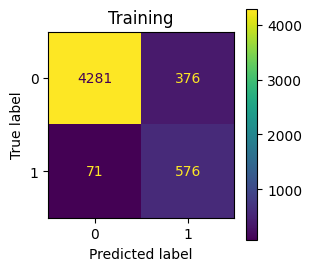

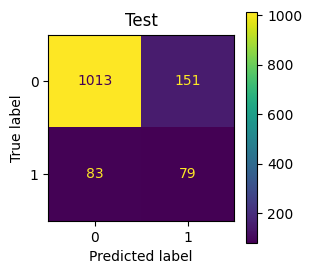

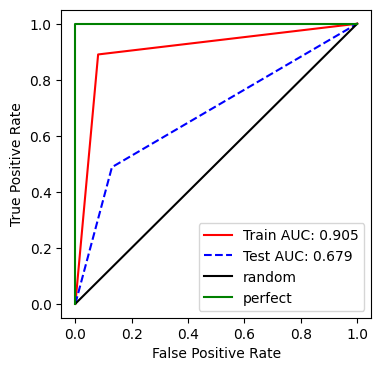

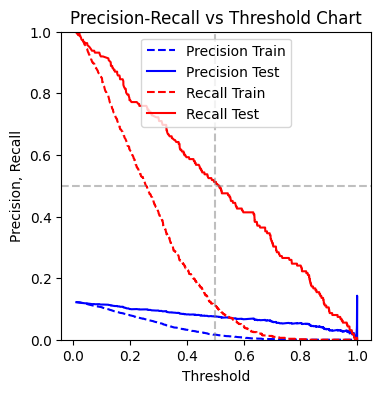

Couldn't extract feature importance!


(0.8902627511591963,
 0.7204502814258912,
 0.904762039096884,
 0.9157239819004525,
 0.6050420168067226,
 0.4876543209876543,
 0.4030612244897959,
 0.6789646175385007,
 0.8235294117647058,
 0.34347826086956523)

In [21]:
model_path = model_path1
model_reload = Booster()
model_reload.load_model(model_path+" 2_XGB_Grid0_Rand2_recall"+".json")
evaluate_model(y_train, y_test, X_train, X_test, model_reload, neuralnet=False, xgb=True)


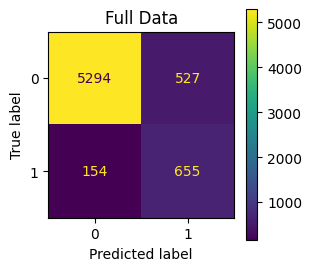

In [22]:
# all X was also scaled for the prediction
y_pred1 = model_reload.predict(DMatrix(X_all, y)).round(0)
y_pred = y_pred1.copy()
plot_confusion_matrix(y, y_pred, title="Full Data")

In [23]:
y-y_pred
(y-y_pred).value_counts()

#  0.0    5824
#  1.0     112 = missing allert
# -1.0     694 = erroneous alert

pv3_defect
 0.0    5949
-1.0     527
 1.0     154
Name: count, dtype: int64

#### Cumulative Rolling Predictions

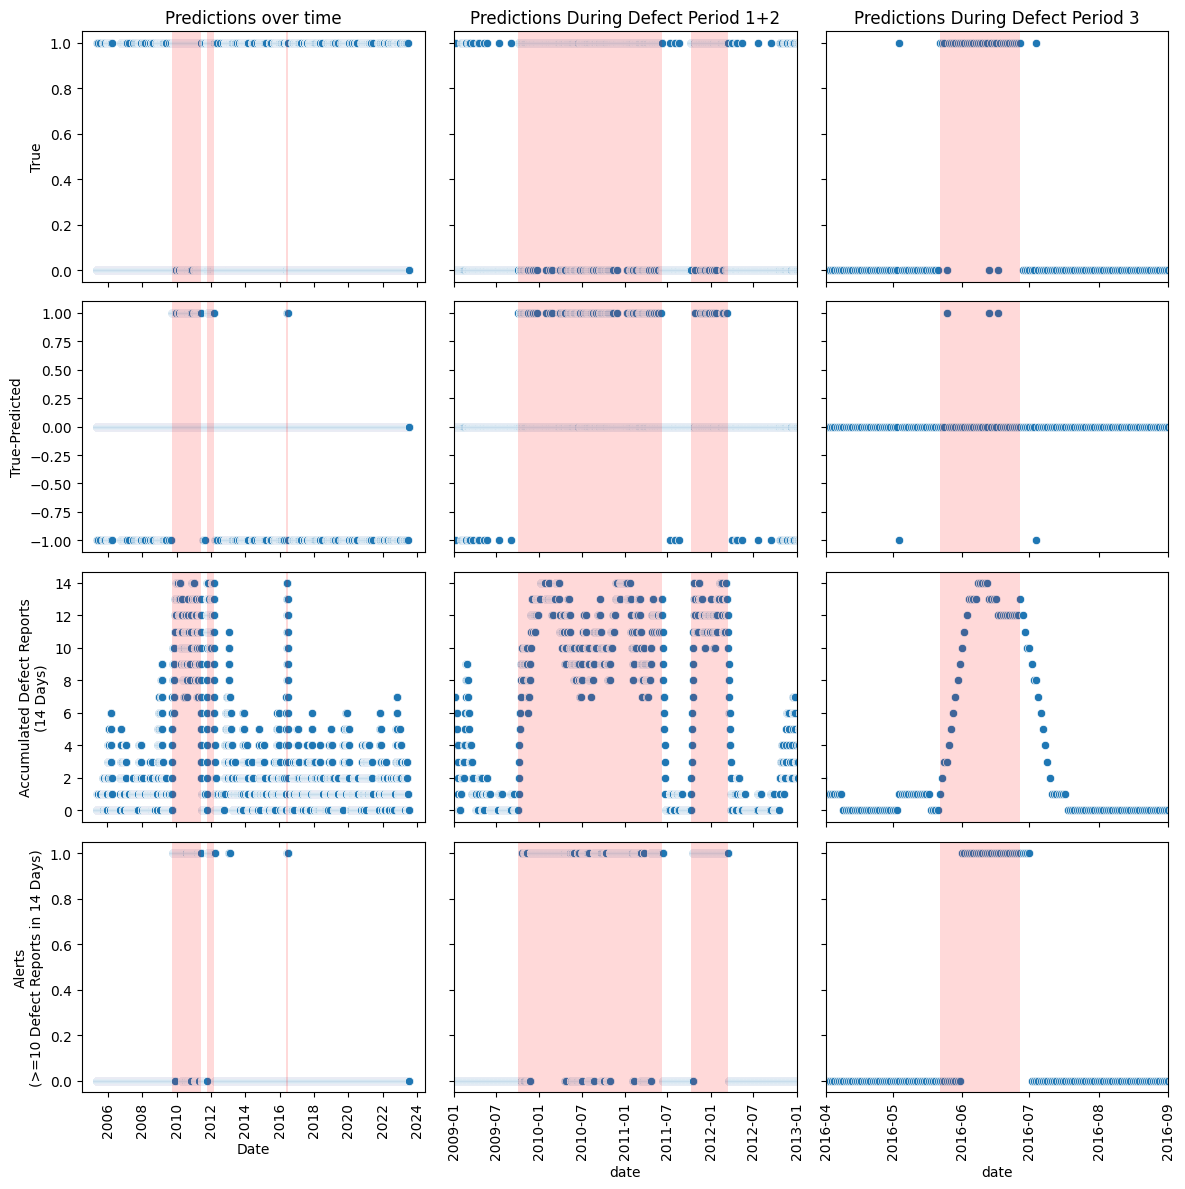

In [24]:
compound_viz(X,y,y_pred, time_window=14, alert_threshold=10)

0 of 1600 FP alerts
Empty DataFrame
Columns: [date, y, y_pred, y_pred_sum]
Index: []
3 of 122 FP alerts
           date  y  y_pred  y_pred_sum
2214 2011-06-10  0     0.0        12.0
2215 2011-06-11  0     0.0        11.0
2216 2011-06-12  0     0.0        10.0
6 of 1528 FP alerts
           date  y  y_pred  y_pred_sum
2494 2012-03-16  0     0.0        11.0
2495 2012-03-17  0     0.0        10.0
2810 2013-01-26  0     1.0        10.0
2811 2013-01-27  0     1.0        11.0
2812 2013-01-28  0     0.0        10.0
2813 2013-01-29  0     0.0        10.0
4 of 2571 FP alerts
           date  y  y_pred  y_pred_sum
4059 2016-06-28  0     0.0        12.0
4060 2016-06-29  0     0.0        11.0
4061 2016-06-30  0     0.0        10.0
4062 2016-07-01  0     0.0        10.0
--------------------------------------------------
13 FP in total!
5808 TN in total!

437 of 614 TP alerts - 177 FN
           date  y  y_pred  y_pred_sum
1600 2009-10-04  1     0.0         0.0
1601 2009-10-05  1     1.0         1.0

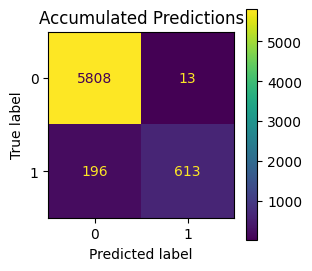

Raw predictions
 [[5294  527]
 [ 154  655]]
Accumulated predictions (threshold: 10 of 14 days)
 [[5808   13]
 [ 196  613]]

Recall: 0.75773
Precision: 0.97923
Accuracy: 0.96848


In [25]:
eval_accumulative_alerts(X, y, y_pred, alert_threshold=10, time_window=14, verbose=True)

#### Details for Model with 10/14 Threshold:

- 13 FPs - 8 due to lags, 1 singular events
    - 8 FP due to lags 2011-06-10 - 12 (3)  
                    2012-03-16 & 17 (2)  
                    2016-06-28 to 30 (3)  
    - 4 FP between 2013-01-26 - 2013-01-29 
    - 1 FP on 2016-07-01 
>
- 196 FNs - 33 due to lags!
    - 14d lag for period 1
    - 9d lag for period 2
    - 10d lag for period 3

4 of 1600 FP alerts
2 of 122 FP alerts
8 of 1528 FP alerts
3 of 2571 FP alerts
--------------------------------------------------
17 FP in total!
5804 TN in total!

439 of 614 TP alerts - 175 FN
151 of 158 TP alerts - 7 FN
29 of 37 TP alerts - 8 FN
--------------------------------------------------
619 TP in total!
190 FN in total!



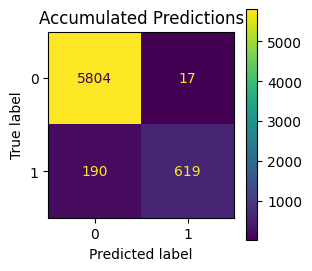

Raw predictions
 [[5294  527]
 [ 154  655]]
Accumulated predictions (threshold: 8 of 11 days)
 [[5804   17]
 [ 190  619]]

Recall: 0.76514
Precision: 0.97327
Accuracy: 0.96878


In [26]:
eval_accumulative_alerts(X, y, y_pred, alert_threshold=8, time_window=11)

### Reload Candidate Model 2

Recall Train:   0.7156105100463679
F1 Score Train: 0.573019801980198
AUC Train:      0.8034784351820845
Train:
[[4151  506]
 [ 184  463]]

Recall Test:   0.5185185185185185
F1 Score Test: 0.40875912408759124
AUC Test:      0.6883829705994655
Test:
[[999 165]
 [ 78  84]]



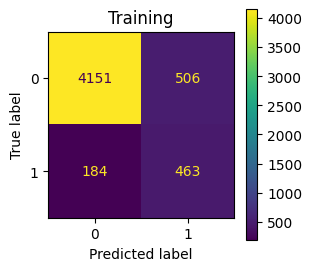

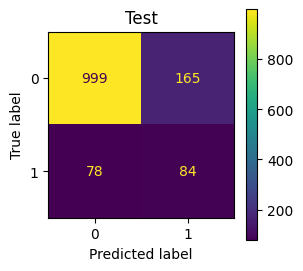

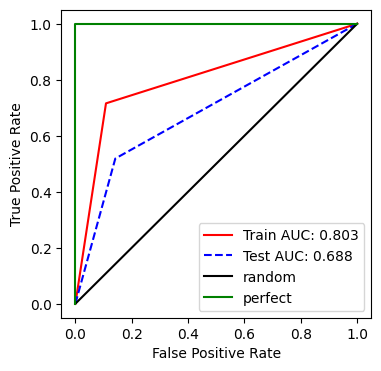

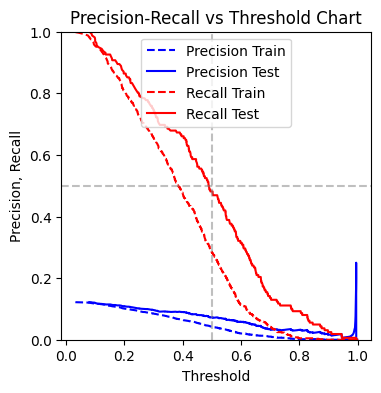

Couldn't extract feature importance!


(0.7156105100463679,
 0.573019801980198,
 0.8034784351820845,
 0.8699095022624435,
 0.47781217750258,
 0.5185185185185185,
 0.40875912408759124,
 0.6883829705994655,
 0.8167420814479638,
 0.3373493975903614)

In [27]:
model_path = model_path1
model_reload = Booster()
model_reload.load_model(model_path+"22_XGB_Grid1_Rand2_recall"+".json")
evaluate_model(y_train, y_test, X_train, X_test, model_reload, neuralnet=False, xgb=True)

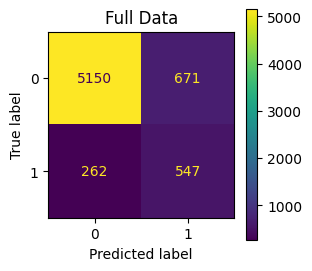

In [28]:
# all X was also scaled for the prediction
y_pred2 = model_reload.predict(DMatrix(X_all, y)).round(0)
y_pred = y_pred2.copy()
plot_confusion_matrix(y, y_pred, title="Full Data")

In [29]:
y-y_pred
(y-y_pred).value_counts()


pv3_defect
 0.0    5697
-1.0     671
 1.0     262
Name: count, dtype: int64

#### Cumulative Rolling Predictions

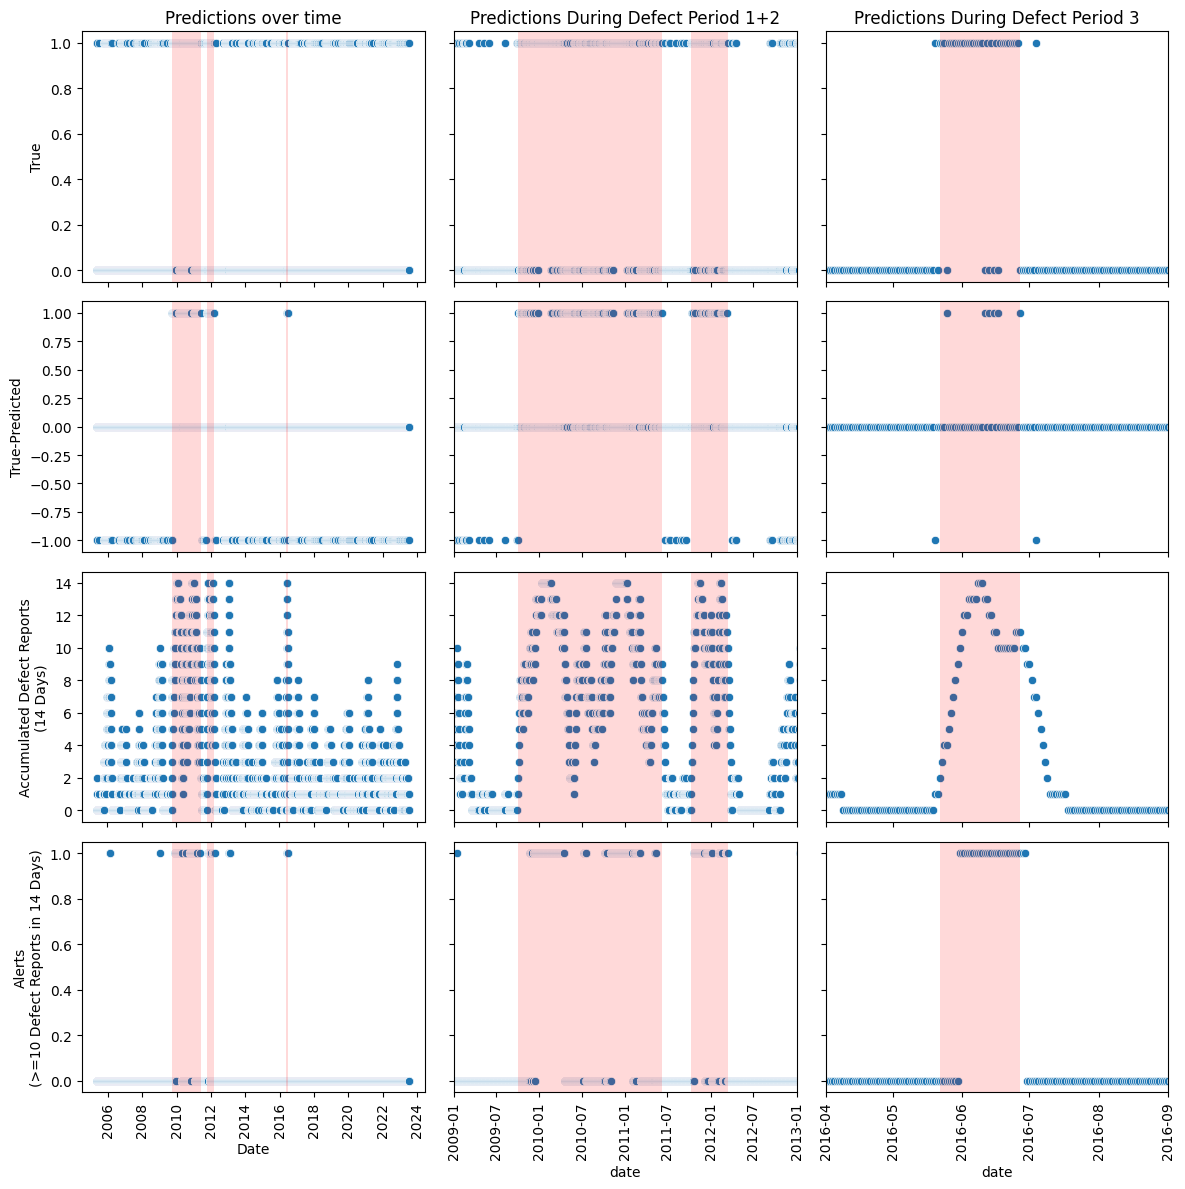

In [30]:
compound_viz(X,y,y_pred, time_window=14, alert_threshold=10)

4 of 1600 FP alerts
           date  y  y_pred  y_pred_sum
271  2006-02-13  0     1.0        10.0
272  2006-02-14  0     0.0        10.0
273  2006-02-15  0     0.0        10.0
1337 2009-01-14  0     1.0        10.0
0 of 122 FP alerts
Empty DataFrame
Columns: [date, y, y_pred, y_pred_sum]
Index: []
18 of 1528 FP alerts
           date  y  y_pred  y_pred_sum
2494 2012-03-16  0     0.0        10.0
2801 2013-01-17  0     1.0        10.0
2802 2013-01-18  0     1.0        10.0
2803 2013-01-19  0     1.0        10.0
2804 2013-01-20  0     1.0        11.0
2805 2013-01-21  0     1.0        12.0
2806 2013-01-22  0     1.0        12.0
2807 2013-01-23  0     1.0        12.0
2808 2013-01-24  0     1.0        12.0
2809 2013-01-25  0     1.0        13.0
2810 2013-01-26  0     1.0        13.0
2811 2013-01-27  0     1.0        14.0
2812 2013-01-28  0     1.0        14.0
2813 2013-01-29  0     1.0        14.0
2814 2013-01-30  0     0.0        13.0
2815 2013-01-31  0     0.0        12.0
2816 2013-02-01  

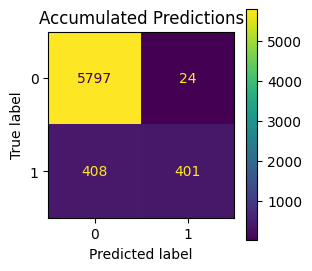

Raw predictions
 [[5150  671]
 [ 262  547]]
Accumulated predictions (threshold: 10 of 14 days)
 [[5797   24]
 [ 408  401]]

Recall: 0.49567
Precision: 0.94353
Accuracy: 0.93484


In [31]:
eval_accumulative_alerts(X, y, y_pred, alert_threshold=10, time_window=14, verbose=True)

#### Details for Model with 10/14 Threshold:

- 24 FPs - 3 due to lags, 1 17d alert
    - 3 FP due to lags 2012-03-16  
                       2016-06-28 to 29 (2)  
    - 17 FP between 2013-01-17 - 2013-02-02  
    - 3 FP between 2006-02-13 - 2006-02-15  
    - 1 FP on 2009-01-14  

>
- 408 FNs - >41 due to lags!
    - \>20d lag for period 1
    - 12d lag for period 2
    - 9d lag for period 3

16 of 1600 FP alerts
0 of 122 FP alerts
17 of 1528 FP alerts
2 of 2571 FP alerts
--------------------------------------------------
35 FP in total!
5786 TN in total!

279 of 614 TP alerts - 335 FN
97 of 158 TP alerts - 61 FN
25 of 37 TP alerts - 12 FN
--------------------------------------------------
401 TP in total!
408 FN in total!



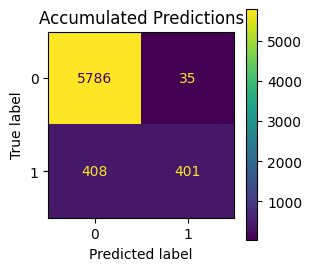

Raw predictions
 [[5150  671]
 [ 262  547]]
Accumulated predictions (threshold: 8 of 11 days)
 [[5786   35]
 [ 408  401]]

Recall: 0.49567
Precision: 0.91972
Accuracy: 0.93318


In [32]:
eval_accumulative_alerts(X, y, y_pred, alert_threshold=8, time_window=11)

### Reload Candidate Model 3

Recall Train:   0.6800618238021638
F1 Score Train: 0.5601527689369828
AUC Train:      0.7880661277052476
Train:
[[4173  484]
 [ 207  440]]

Recall Test:   0.5061728395061729
F1 Score Test: 0.4049382716049383
AUC Test:      0.6839283441517119
Test:
[[1003  161]
 [  80   82]]



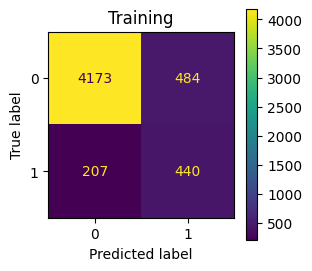

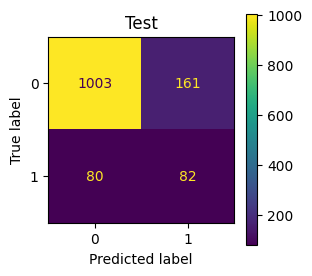

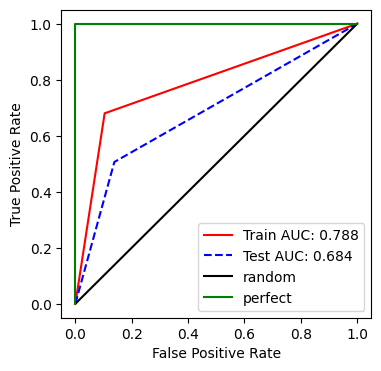

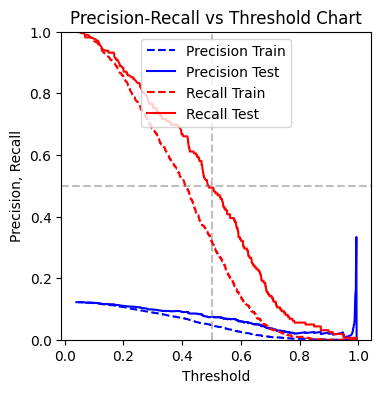

Couldn't extract feature importance!


(0.6800618238021638,
 0.5601527689369828,
 0.7880661277052476,
 0.8697209653092006,
 0.47619047619047616,
 0.5061728395061729,
 0.4049382716049383,
 0.6839283441517119,
 0.8182503770739065,
 0.3374485596707819)

In [33]:
model_reload = Booster()
model_reload.load_model(model_path1+"30_XGB_Grid1_Rand6_recall"+".json")
evaluate_model(y_train, y_test, X_train, X_test, model_reload, neuralnet=False, xgb=True)

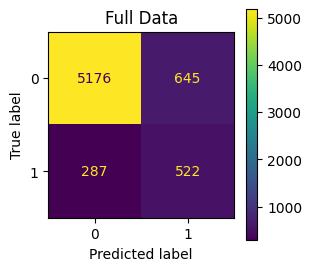

In [34]:
# all X was also scaled for the prediction
y_pred2 = model_reload.predict(DMatrix(X_all, y)).round(0)
y_pred = y_pred2.copy()
plot_confusion_matrix(y, y_pred, title="Full Data")

In [35]:
y-y_pred
(y-y_pred).value_counts()


pv3_defect
 0.0    5698
-1.0     645
 1.0     287
Name: count, dtype: int64

#### Cumulative Rolling Predictions

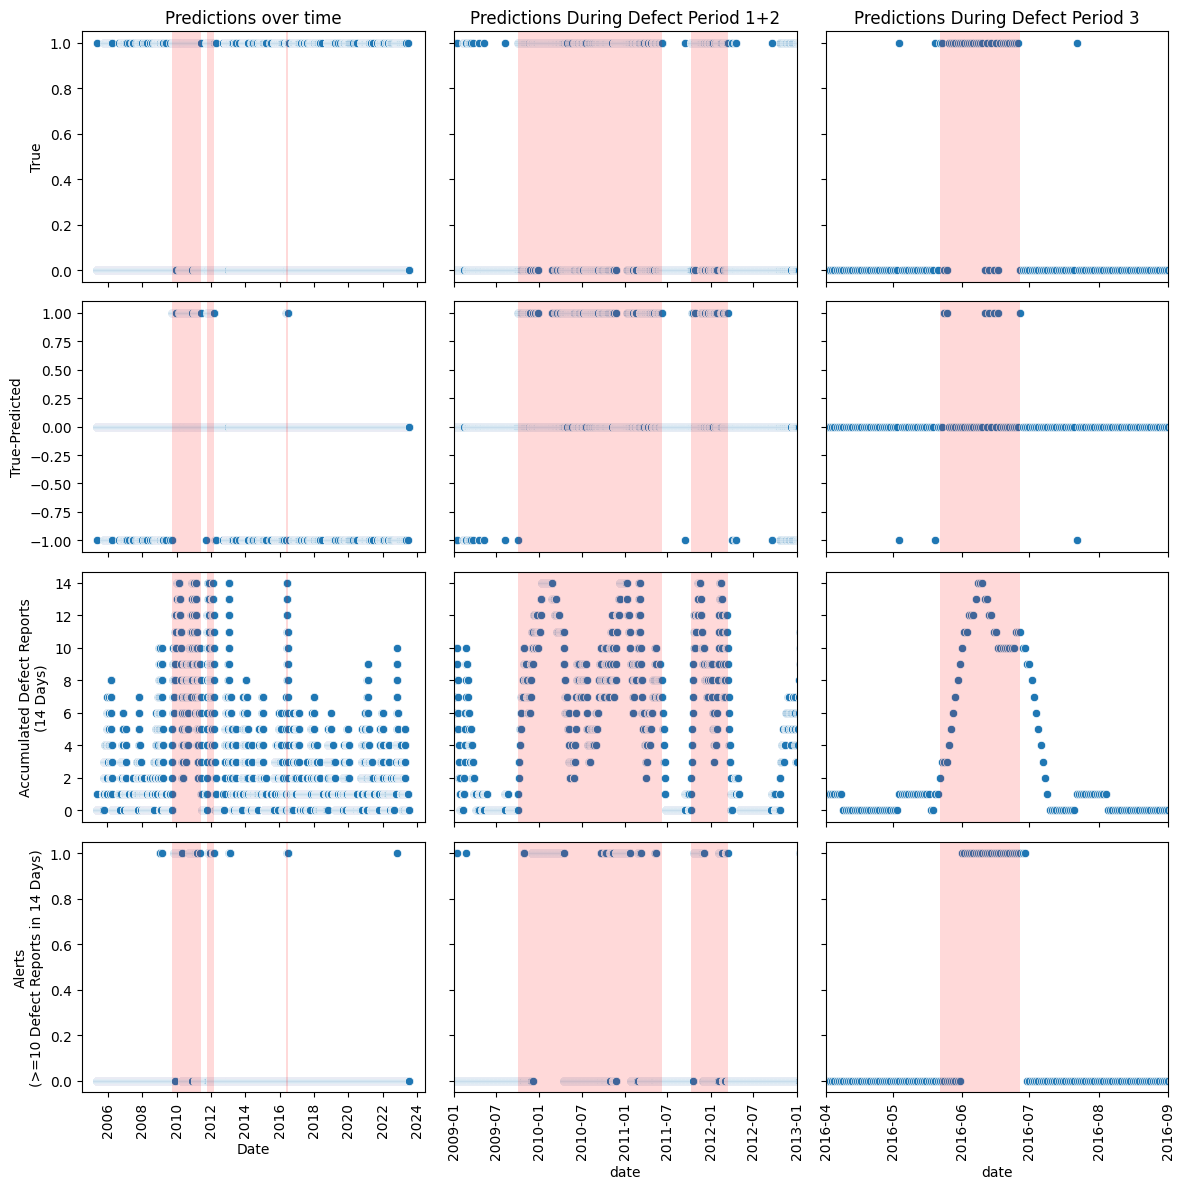

In [36]:
compound_viz(X,y,y_pred, time_window=14, alert_threshold=10)

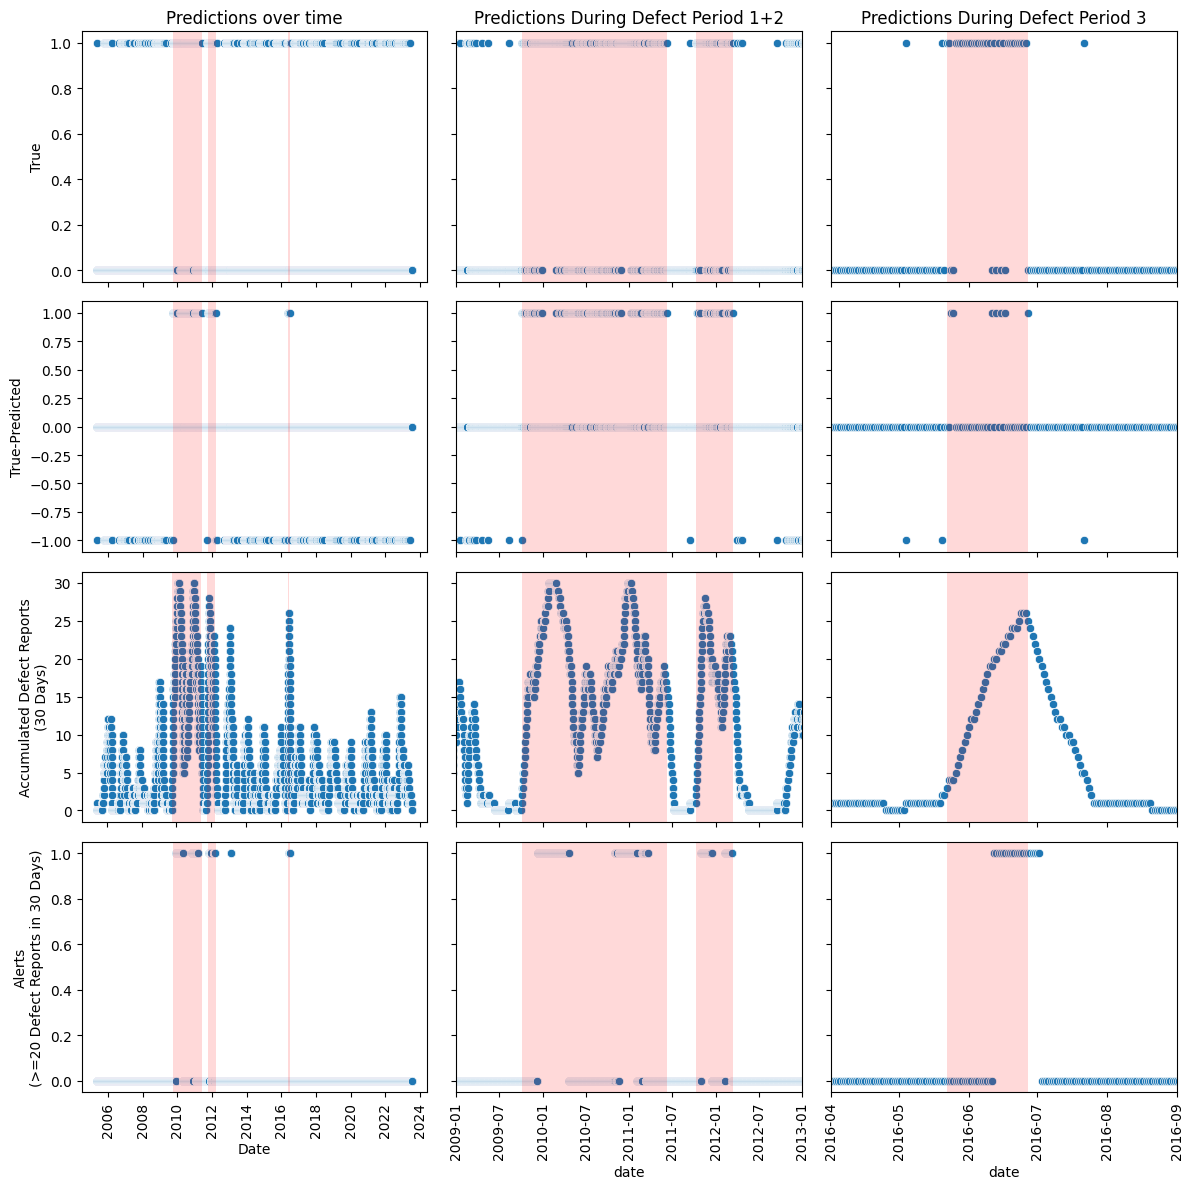

In [37]:
compound_viz(X,y,y_pred, time_window=30, alert_threshold=20)

5 of 1600 FP alerts
           date  y  y_pred  y_pred_sum
1333 2009-01-10  0     1.0        10.0
1334 2009-01-11  0     0.0        10.0
1335 2009-01-12  0     0.0        10.0
1337 2009-01-14  0     1.0        10.0
1378 2009-02-24  0     1.0        10.0
0 of 122 FP alerts
Empty DataFrame
Columns: [date, y, y_pred, y_pred_sum]
Index: []
19 of 1528 FP alerts
           date  y  y_pred  y_pred_sum
2799 2013-01-15  0     1.0        10.0
2800 2013-01-16  0     1.0        11.0
2801 2013-01-17  0     1.0        11.0
2802 2013-01-18  0     1.0        11.0
2803 2013-01-19  0     1.0        11.0
2804 2013-01-20  0     1.0        12.0
2805 2013-01-21  0     1.0        13.0
2806 2013-01-22  0     1.0        13.0
2807 2013-01-23  0     1.0        13.0
2808 2013-01-24  0     1.0        13.0
2809 2013-01-25  0     1.0        14.0
2810 2013-01-26  0     1.0        14.0
2811 2013-01-27  0     1.0        14.0
2812 2013-01-28  0     1.0        14.0
2813 2013-01-29  0     1.0        14.0
2814 2013-01-30  

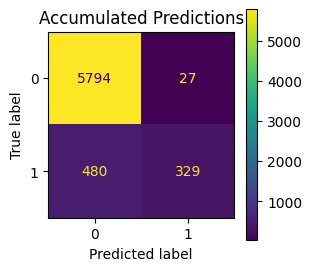

Raw predictions
 [[5176  645]
 [ 287  522]]
Accumulated predictions (threshold: 10 of 14 days)
 [[5794   27]
 [ 480  329]]

Recall: 0.40667
Precision: 0.92416
Accuracy: 0.92353


In [38]:
eval_accumulative_alerts(X, y, y_pred, alert_threshold=10, time_window=14, verbose=True)

#### Details for Model with 10/14 Threshold:

- 27 FPs - 2 due to lags, 1 19d alert
    - 2 FP due to lags 2016-06-28 to 29 (2)  
    - 19 FP between 2013-01-15 - 2013-02-02  
    - 4 FP between 2009-01-10 - 2009-01-14
    - 1 FP on 2009-02-24 
    - 1 FP on 2022-11-02 
>
- 480 FNs - >41 due to lags!
    - \>20d lag for period 1
    - 11d lag for period 2
    - 10d lag for period 3

> Model 2 performs best when accumulating reports

## GridSearch 2 with XGboost


  0_XGB_Grid0_Rand1_recall
[14:31:17] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.



[14:31:17] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:31:17] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:31:17] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:31:18] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:31:18] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:31:18] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.maco

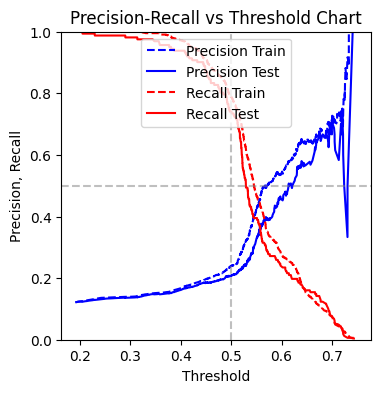

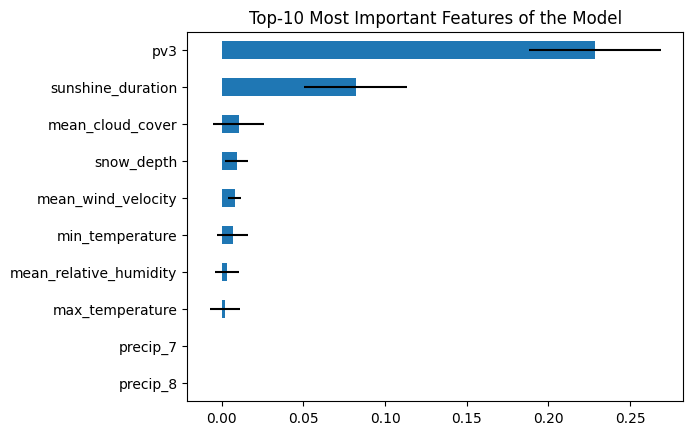


  1_XGB_Grid0_Rand1_f1
[14:31:25] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:31:26] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:31:26] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:31:26] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:31:27] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:31:27] WARNING: /Users/runner/work/xgboost/xgboost/python

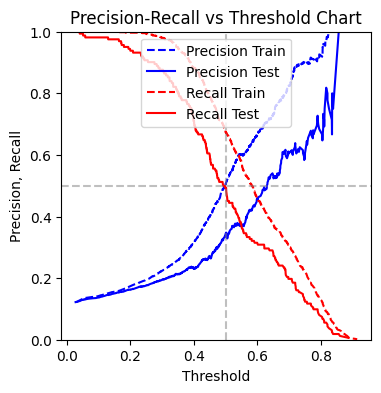

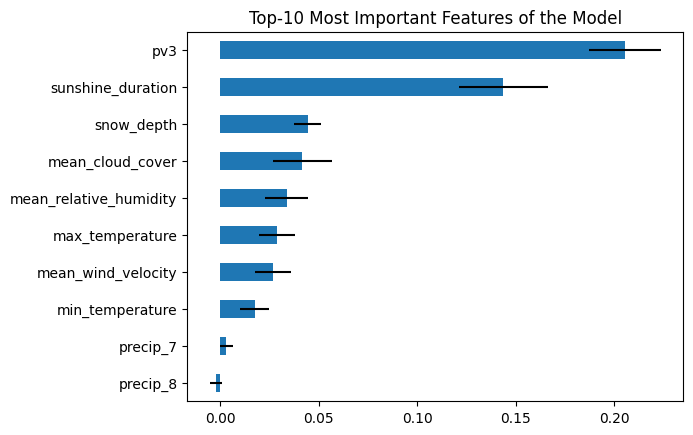


  2_XGB_Grid0_Rand2_recall
[14:31:35] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:31:35] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:31:36] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:31:36] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:31:36] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:31:36] WARNING: /Users/runner/work/xgboost/xgboost/py

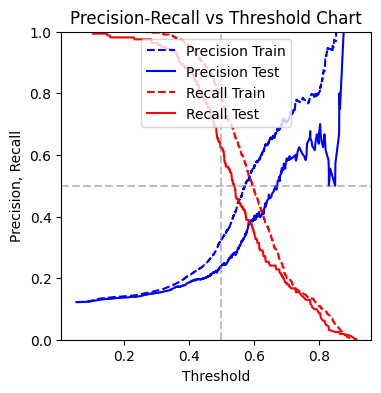

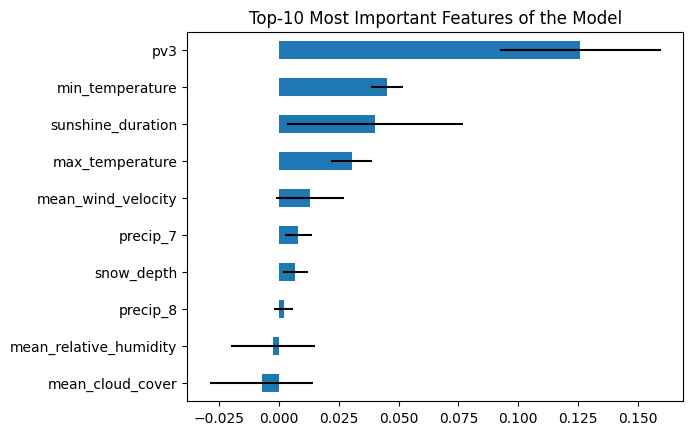


  3_XGB_Grid0_Rand2_f1
[14:31:45] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:31:45] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:31:46] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:31:46] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:31:47] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:31:47] WARNING: /Users/runner/work/xgboost/xgboost/python

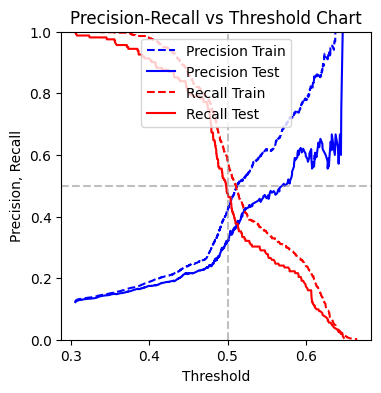

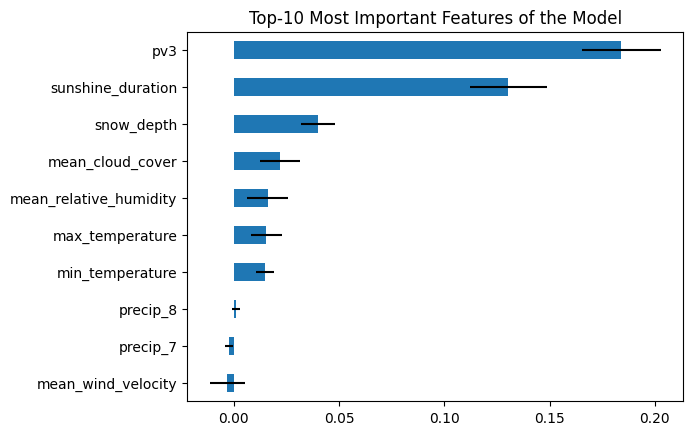


  4_XGB_Grid0_Rand3_recall
[14:31:56] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:31:57] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:31:57] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:31:57] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:31:57] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:31:58] WARNING: /Users/runner/work/xgboost/xgboost/py

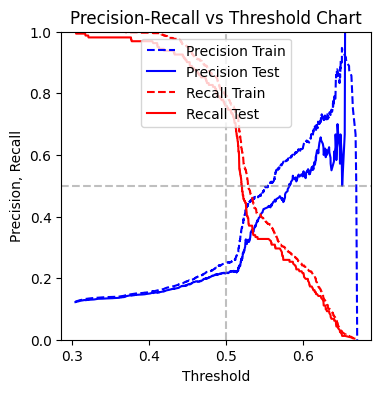

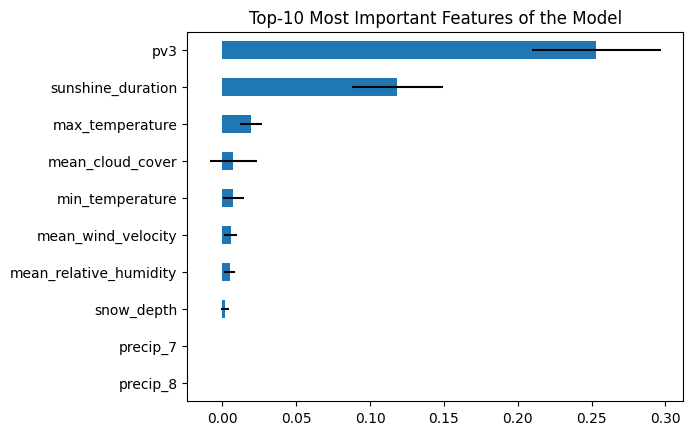


  5_XGB_Grid0_Rand3_f1
[14:32:06] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:32:06] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:32:07] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:32:07] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:32:07] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:32:07] WARNING: /Users/runner/work/xgboost/xgboost/python

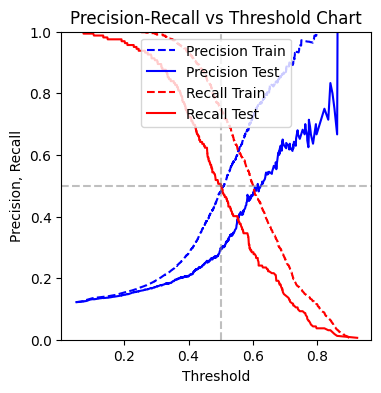

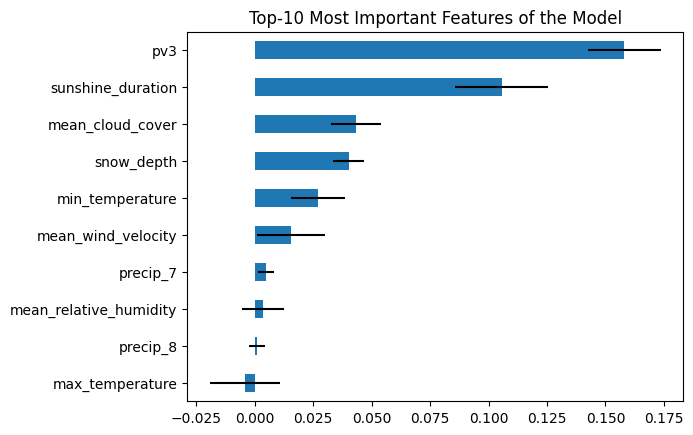


  6_XGB_Grid0_Rand4_recall
[14:32:17] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:32:17] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:32:18] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:32:18] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:32:18] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:32:19] WARNING: /Users/runner/work/xgboost/xgboost/py

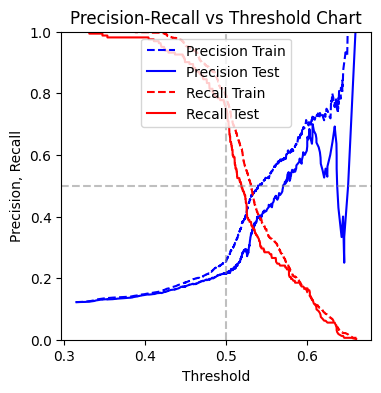

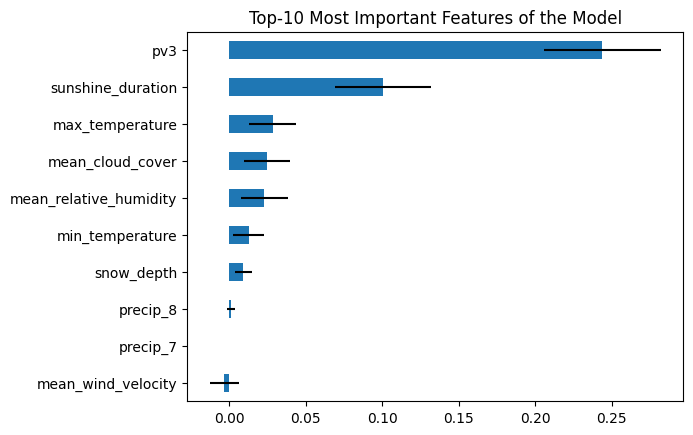


  7_XGB_Grid0_Rand4_f1
[14:32:28] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:32:28] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:32:28] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:32:29] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:32:29] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:32:29] WARNING: /Users/runner/work/xgboost/xgboost/python

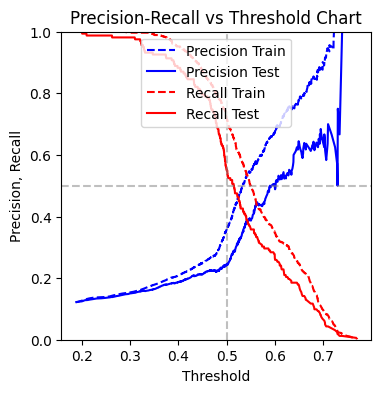

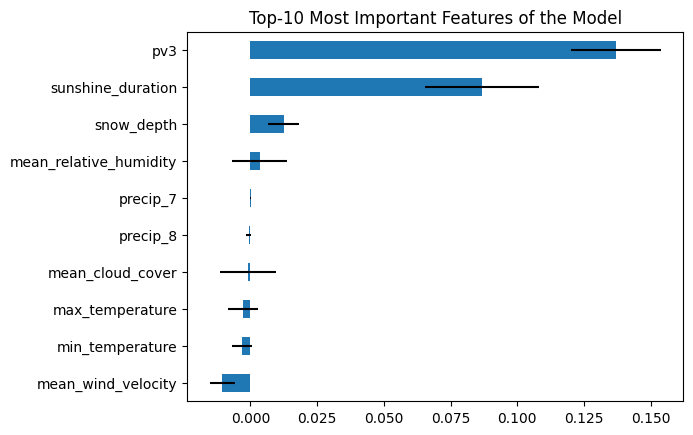


  8_XGB_Grid0_Rand5_recall
[14:32:38] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:32:38] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:32:38] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:32:39] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:32:39] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:32:40] WARNING: /Users/runner/work/xgboost/xgboost/py

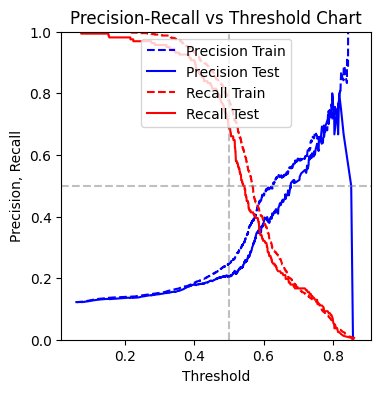

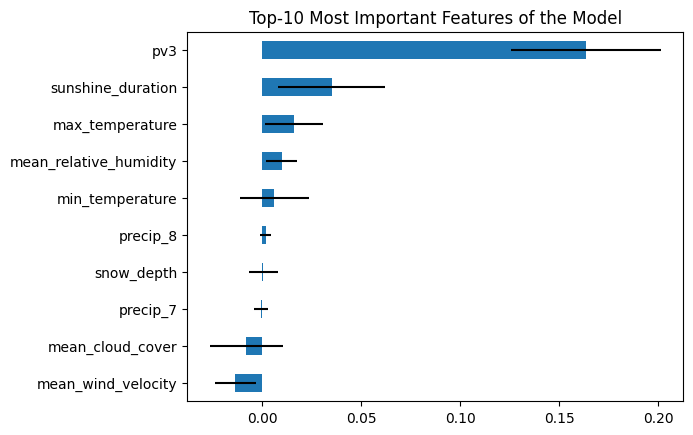


  9_XGB_Grid0_Rand5_f1
[14:32:47] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:32:47] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:32:47] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:32:48] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:32:48] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:32:49] WARNING: /Users/runner/work/xgboost/xgboost/python

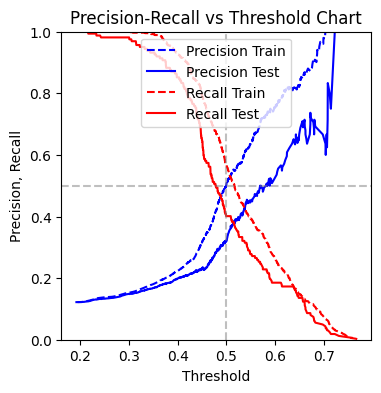

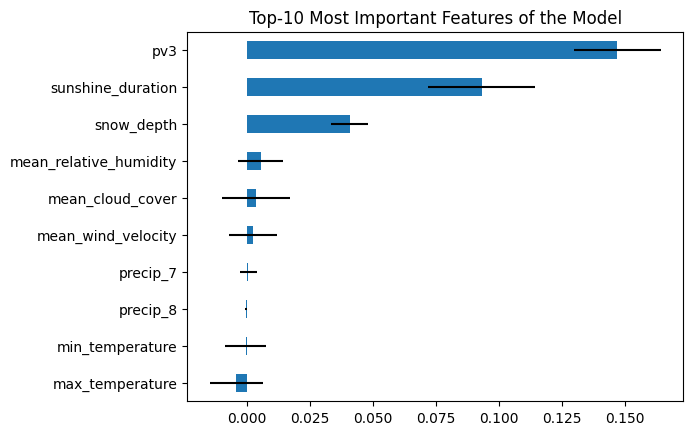


 10_XGB_Grid0_Rand6_recall
[14:32:57] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:32:58] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:32:58] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:32:59] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:32:59] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:32:59] WARNING: /Users/runner/work/xgboost/xgboost/py

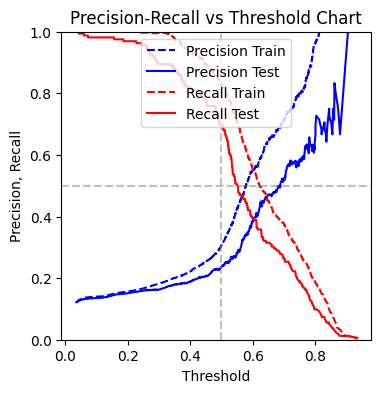

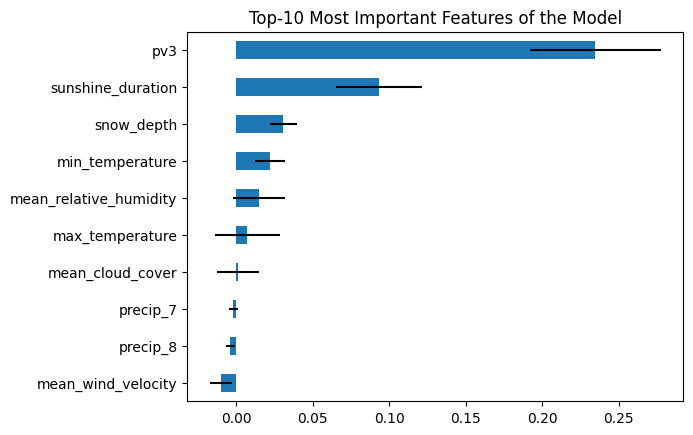


 11_XGB_Grid0_Rand6_f1
[14:33:08] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:33:08] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:33:08] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:33:09] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:33:09] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:33:09] WARNING: /Users/runner/work/xgboost/xgboost/python

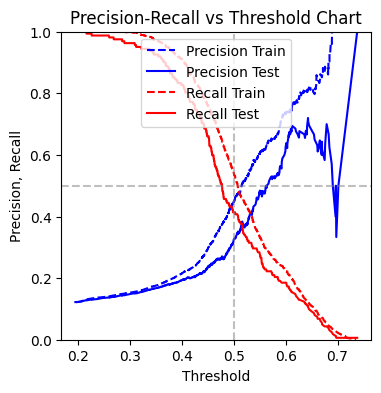

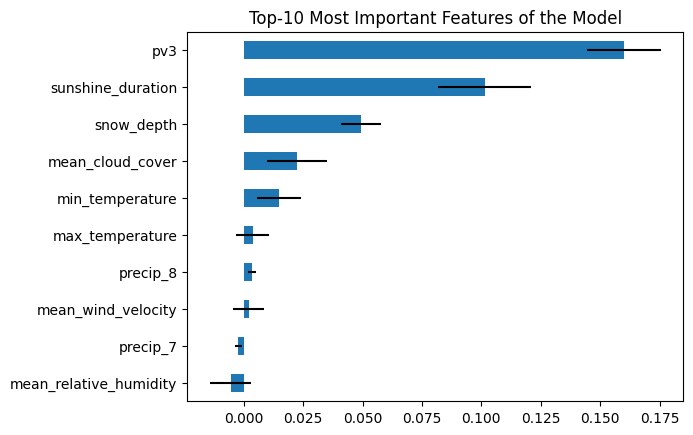


 12_XGB_Grid0_Rand7_recall
[14:33:17] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:33:17] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:33:17] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:33:18] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:33:18] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:33:18] WARNING: /Users/runner/work/xgboost/xgboost/py

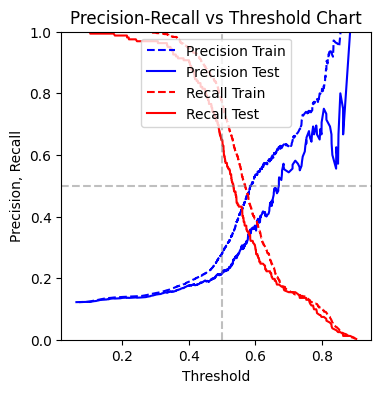

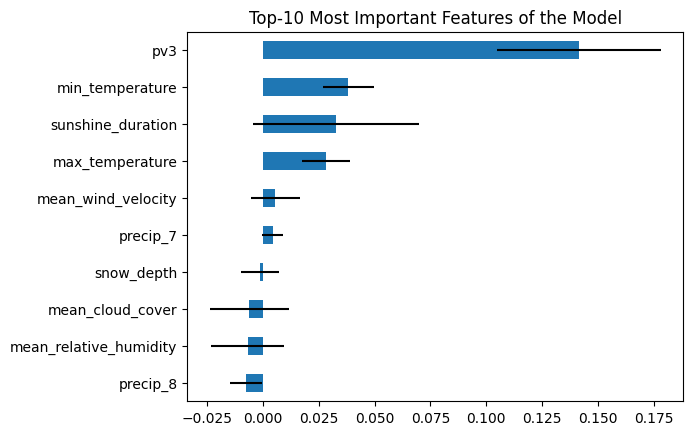


 13_XGB_Grid0_Rand7_f1
[14:33:28] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:33:28] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:33:28] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:33:29] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:33:29] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:33:29] WARNING: /Users/runner/work/xgboost/xgboost/python

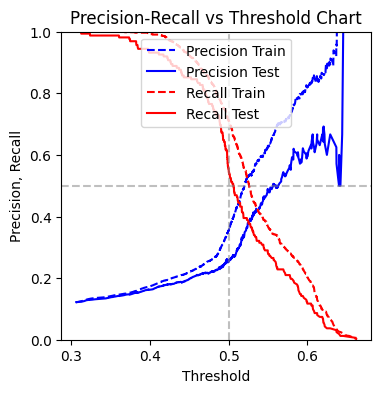

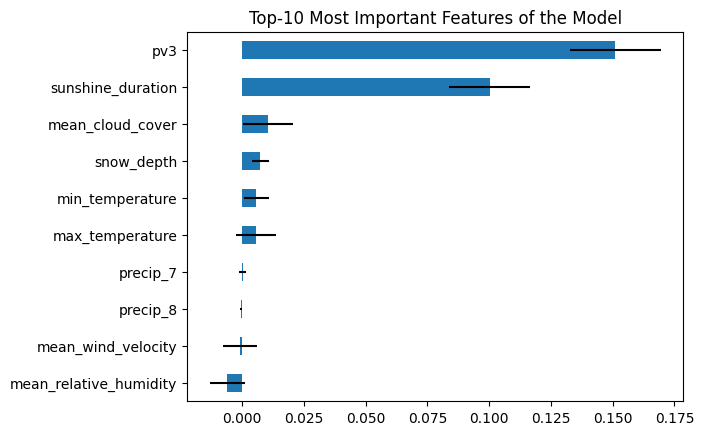


 14_XGB_Grid0_Rand8_recall
[14:33:39] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:33:39] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:33:39] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:33:40] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:33:40] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:33:40] WARNING: /Users/runner/work/xgboost/xgboost/py

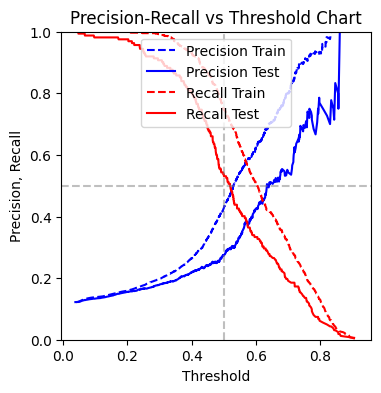

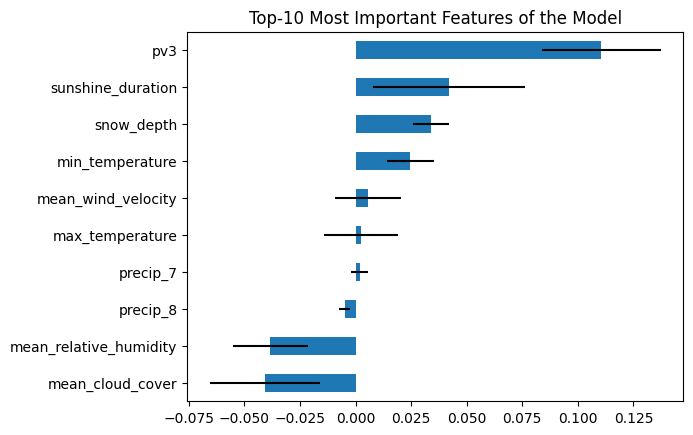


 15_XGB_Grid0_Rand8_f1
[14:33:48] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:33:49] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:33:49] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:33:50] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:33:50] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:33:50] WARNING: /Users/runner/work/xgboost/xgboost/python

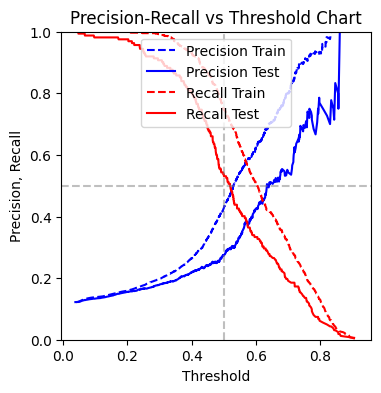

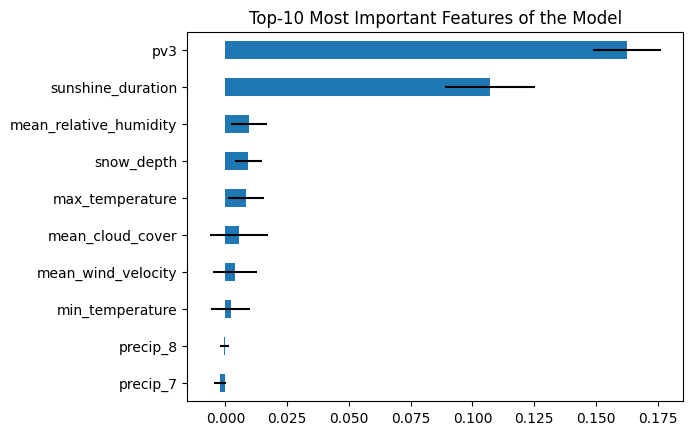


 16_XGB_Grid0_Rand9_recall
[14:33:59] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:33:59] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:33:59] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:34:00] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:34:00] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:34:01] WARNING: /Users/runner/work/xgboost/xgboost/py

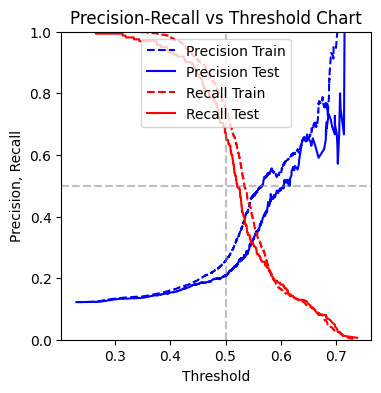

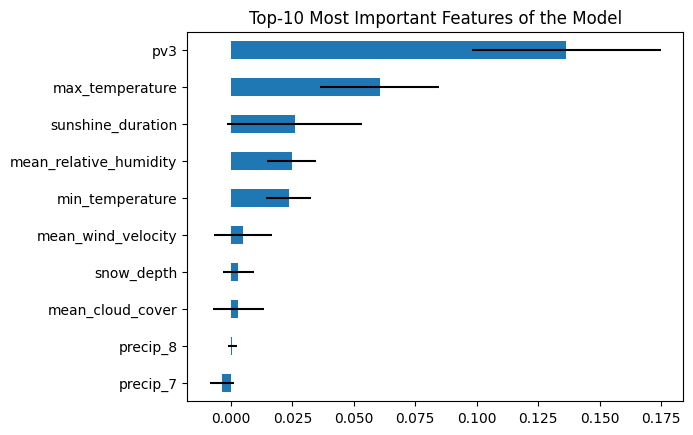


 17_XGB_Grid0_Rand9_f1
[14:34:10] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:34:10] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:34:11] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:34:11] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:34:11] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:34:12] WARNING: /Users/runner/work/xgboost/xgboost/python

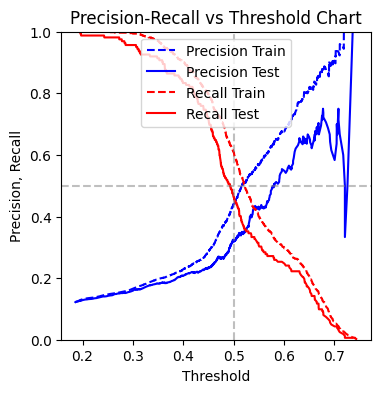

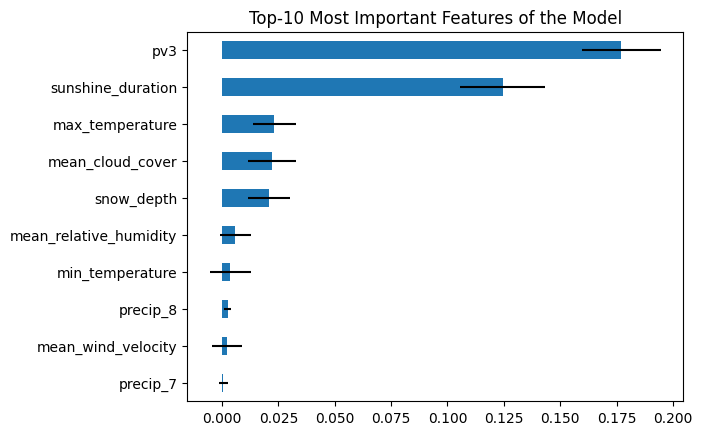


 18_XGB_Grid0_Rand10_recall
[14:34:20] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:34:20] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:34:21] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:34:21] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:34:21] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:34:21] WARNING: /Users/runner/work/xgboost/xgboost/p

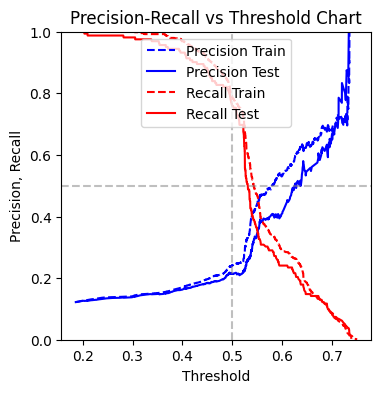

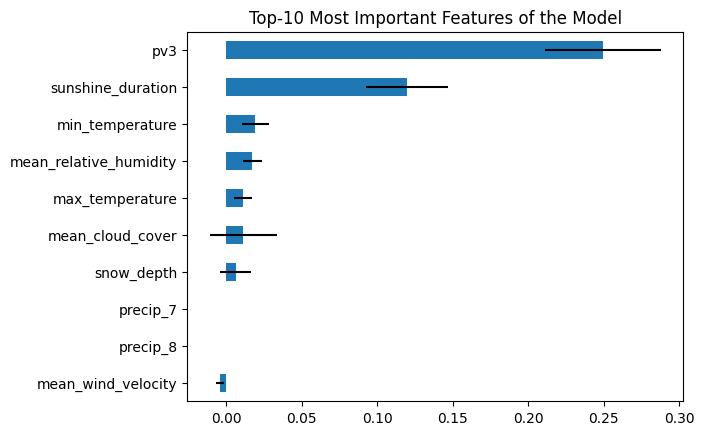


 19_XGB_Grid0_Rand10_f1
[14:34:28] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:34:29] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:34:29] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:34:29] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:34:30] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "growpolicy" } are not used.

[14:34:30] WARNING: /Users/runner/work/xgboost/xgboost/pytho

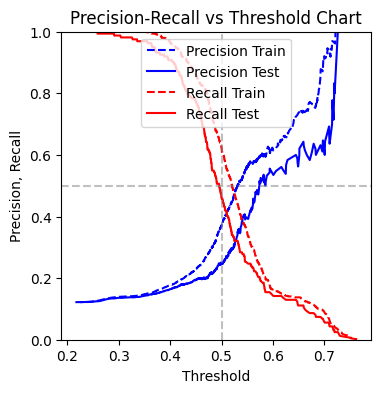

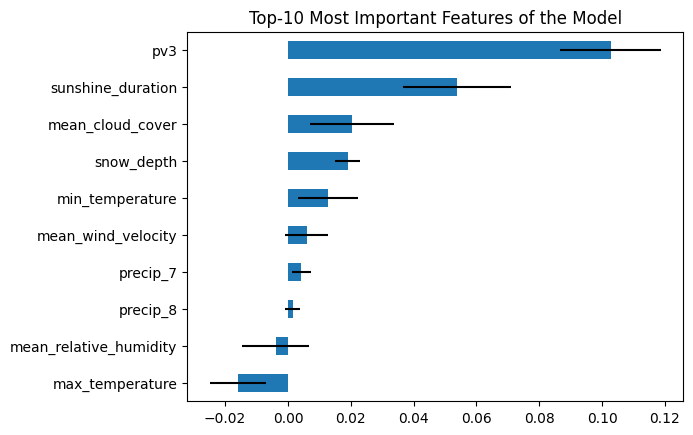

In [39]:
# runtime approx. 26 min

model_path = model_path2
logfile = logfile2

# hyperparameter grid - acc. to https://xgboost.readthedocs.io/en/stable/parameter.html - runs 2-3 min
NEW_PARAMETERS = {
    'learning_rate': [.005, .01, .03], #.3 
    'lambda': [.6,.8,1], #0
    'alpha': [0,.1,.2,.3,.4,.5,.6], #0
    'subsample': [.5,.6,.7,.75,.8,.85,.9,.95,1],
    'colsample_bytree': [.6,.7,.8,.9,1], 
    'scale_pos_weight': [3,5,6,7], 
    'colsample_bylevel': [.7,.8,.9,1], 
    'min_child_weight': [.5,1,3,5], 
    'max_depth': [3,4,5,6], 
    'growpolicy': ["depthwise", 'lossguide'], 
    }# refined - value range acc. to best models so far

PARAMETERS3 = {
    "n_estimators": [5,10,20,50,100,200,500,1000],
    "learning_rate": [.01,.03,.1,.3,.5,1,2], # default .3 (eta)
    "min_child_weight":[1,2,3,4,5], # default 1, min weight sum
    "max_depth": [4,6,8,10], # default 6
    "subsample": [.5,.7,.8,1], # default 1 - subsampling training instances if <1 to prevent overfitting
    "colsample_bytree": [.6,.8,1], # default 1 - subsampling columns once per tree
    "colsample_bylevel": [.6,.8,1], # default 1 - subsampling columns once per level
    "lambda": [.4,.6,.8,1], # default 1 - l2 regularization
    "alpha": [0,.2,.4,.6], # default 0 - l1 regularization
    "growpolicy": ['depthwise', 'lossguide'],
    "scale_pos_weight": [1,2,3,4,5,7], # scale for imbalance
    } # 9216 combinations * 3 cv


outfile=open(model_path+logfile, 'w')

grids = [NEW_PARAMETERS]

index = -1
for idx in range(len(grids)):
    parameters = grids[idx]
    for factor in range(1,11):
        for metric in ["recall", "f1"]:

            index += 1
            name = "%2d_XGB_Grid%d_Rand%d_%s" % (index, idx, factor, metric)
            print("\n", name)

            classifier = XGBClassifier(n_jobs=-1, eval_metric='logloss')#, early_stopping_rounds=10)

            model = RandomizedSearchCV(estimator=classifier,
                                       param_distributions=parameters,
                                       cv=3, random_state=RSEED*factor,
                                       scoring=metric, verbose=0)

            model.fit(X_train, y_train, verbose=0)

            print(model.best_params_)
            
            # metrics for train (1) and test (2)
            r1,f1,a1,ac1,p1,r2,f2,a2,ac2,p2 = evaluate_model(y_train, y_test, X_train, X_test, model, 
                                                       neuralnet=False, plotting=False, 
                                                       save_tag=str(index), outdir=model_path)

            if r2>0.4 and f2>0.3:
                # save to JSON
                model.best_estimator_.save_model(model_path+"%s.json" % name)
                # save to text format
                model.best_estimator_.save_model(model_path+"%s.txt" % name)
                save_tag="saved"
            else:
                save_tag="not-saved"
            
            outfile.write(";".join([str(x) for x in [index,name,r1,f1,a1,ac1,p1,r2,f2,a2,ac2,p2,save_tag,model.best_params_]])+"\n")

outfile.close()


### Evaluate Tuned XGboost Models

In [40]:
# check file
infile=open(model_path2+logfile2, 'r')
for line in infile:
    if len(line.split(";")) != 14:
        print(len(line.split(";")), end=" ")
        print(line.strip())
infile.close()

In [41]:
df_log2 = pd.read_csv(model_path2+logfile2, sep=";", header=None)
df_log2.columns = ["idx", "title", "recall_train", "f1_train", "auc_train", "accur_train", "prec_train",
                                  "recall_test", "f1_test", "auc_test", "accur_test", "prec_test", "status", "params"]
df_log2.head()

# filter good models and duplicates
df_log2 = df_log2[df_log2.status == "saved"]
df_log2.drop_duplicates(subset=df_log2.columns.difference(['idx', "title"]), inplace=True) # 11 duplicates
print(df_log2.shape)

(19, 14)


In [42]:
df_log2.query("recall_test>0.45 & recall_train>0.45 & f1_train>0.4 & f1_test>0.4").reset_index(drop=True)


,idx,title,recall_train,f1_train,auc_train,accur_train,prec_train,recall_test,f1_test,auc_test,accur_test,prec_test,status,params
0,1,1_XGB_Grid0_Rand1_f1,0.675425,0.577279,0.791545,0.879336,0.504037,0.493827,0.405063,0.681192,0.822775,0.343348,saved,"{'subsample': 0.85, 'scale_pos_weight': 5, 'mi..."


In [43]:
df_log2 = df_log2.query("recall_test>0.45 & recall_train>0.45 & f1_train>0.4 & f1_test>0.4").reset_index(drop=True)
df_log2

,idx,title,recall_train,f1_train,auc_train,accur_train,prec_train,recall_test,f1_test,auc_test,accur_test,prec_test,status,params
0,1,1_XGB_Grid0_Rand1_f1,0.675425,0.577279,0.791545,0.879336,0.504037,0.493827,0.405063,0.681192,0.822775,0.343348,saved,"{'subsample': 0.85, 'scale_pos_weight': 5, 'mi..."


In [44]:
# plot metrics
fig = px.scatter(df_log2, x="recall_train", y="recall_test", hover_data=["title", "f1_train", "f1_test", "idx"],
                 color=df_log2.accur_test)
fig.show()
fig = px.scatter(df_log2, x="f1_train", y="f1_test", hover_data=["title", "recall_train", "recall_test", "idx"],
                 color=df_log2.accur_test)
fig.show()
fig = px.scatter(df_log2, x="auc_train", y="auc_test", hover_data=["title", "idx"],
                 color=df_log2.accur_test)
fig.show()
fig = px.scatter(df_log2, x="accur_train", y="accur_test", hover_data=["title", "idx"],
                 color=df_log2.accur_test)
fig.show()
fig = px.scatter(df_log2, x="accur_test", y="recall_test", hover_data=["title", "idx"],
                 color=df_log2.accur_test)
fig.show()
fig = px.scatter(df_log2, x="accur_train", y="recall_train", hover_data=["title", "idx"],
                 color=df_log2.accur_test)
fig.show()


df_log2["sumscore_train"] = df_log2.accur_train + df_log2.recall_train 
df_log2["sumscore_test"] = df_log2.accur_test + df_log2.recall_test
df_log2["train_test_diffs"] =  df_log2.accur_train - df_log2.accur_test + df_log2.recall_train - df_log2.recall_test
df_log2["score_sum"] = df_log2.accur_train + df_log2.recall_train + df_log2.accur_test + df_log2.recall_test
df_log2["f1_sum"] = df_log2.f1_train + df_log2.f1_test
# fig = px.scatter(df_log2, x="sumscore_train", y="sumscore_test", hover_data=["title", "accur_train", "accur_test", "recall_train", "recall_test"],
#                  color=df_log2.index)
fig = px.scatter(df_log2, x="score_sum", y="train_test_diffs", 
                 hover_data=["title", "accur_train", "accur_test", "recall_train", "recall_test", "f1_train", "f1_test", "idx"],
                 color=df_log2.recall_test)
fig.show()
# fig = px.scatter(x=df.iloc[1], y=df.iloc[4], hover_data=df.iloc[0])
# fig.set_title("Recall")

### Reload Candidate Model 4

Recall Train:   0.6754250386398764
F1 Score Train: 0.5772787318361955
AUC Train:      0.791545458980664
Train:
[[4227  430]
 [ 210  437]]

Recall Test:   0.49382716049382713
F1 Score Test: 0.40506329113924044
AUC Test:      0.6811919307623775
Test:
[[1011  153]
 [  82   80]]



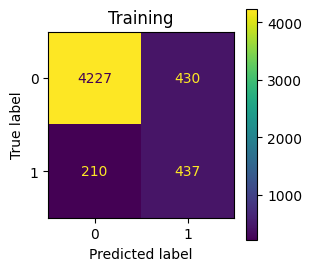

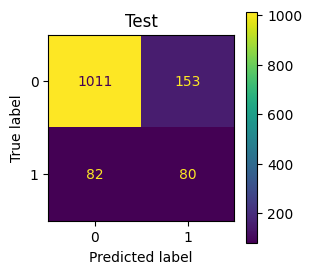

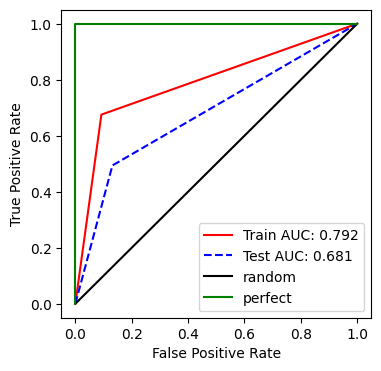

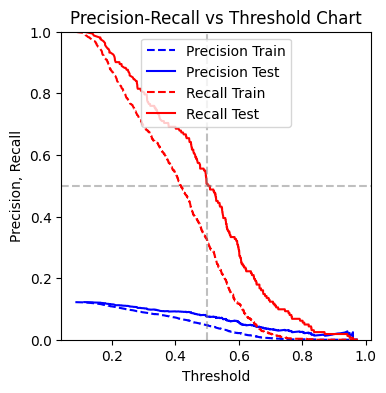

Couldn't extract feature importance!


(0.6754250386398764,
 0.5772787318361955,
 0.791545458980664,
 0.8793363499245852,
 0.5040369088811996,
 0.49382716049382713,
 0.40506329113924044,
 0.6811919307623775,
 0.8227752639517345,
 0.34334763948497854)

In [45]:
model_path = model_path2
model_reload = Booster()
model_reload.load_model(model_path+" 1_XGB_Grid0_Rand1_f1"+".json")
evaluate_model(y_train, y_test, X_train, X_test, model_reload, neuralnet=False, xgb=True)


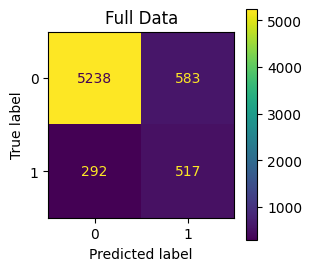

In [46]:
# all X was also scaled for the prediction
y_pred3 = model_reload.predict(DMatrix(X_all, y)).round(0)
y_pred = y_pred3.copy()
plot_confusion_matrix(y, y_pred, title="Full Data")

In [47]:
y-y_pred
(y-y_pred).value_counts()


pv3_defect
 0.0    5755
-1.0     583
 1.0     292
Name: count, dtype: int64

#### Cumulative Rolling Predictions

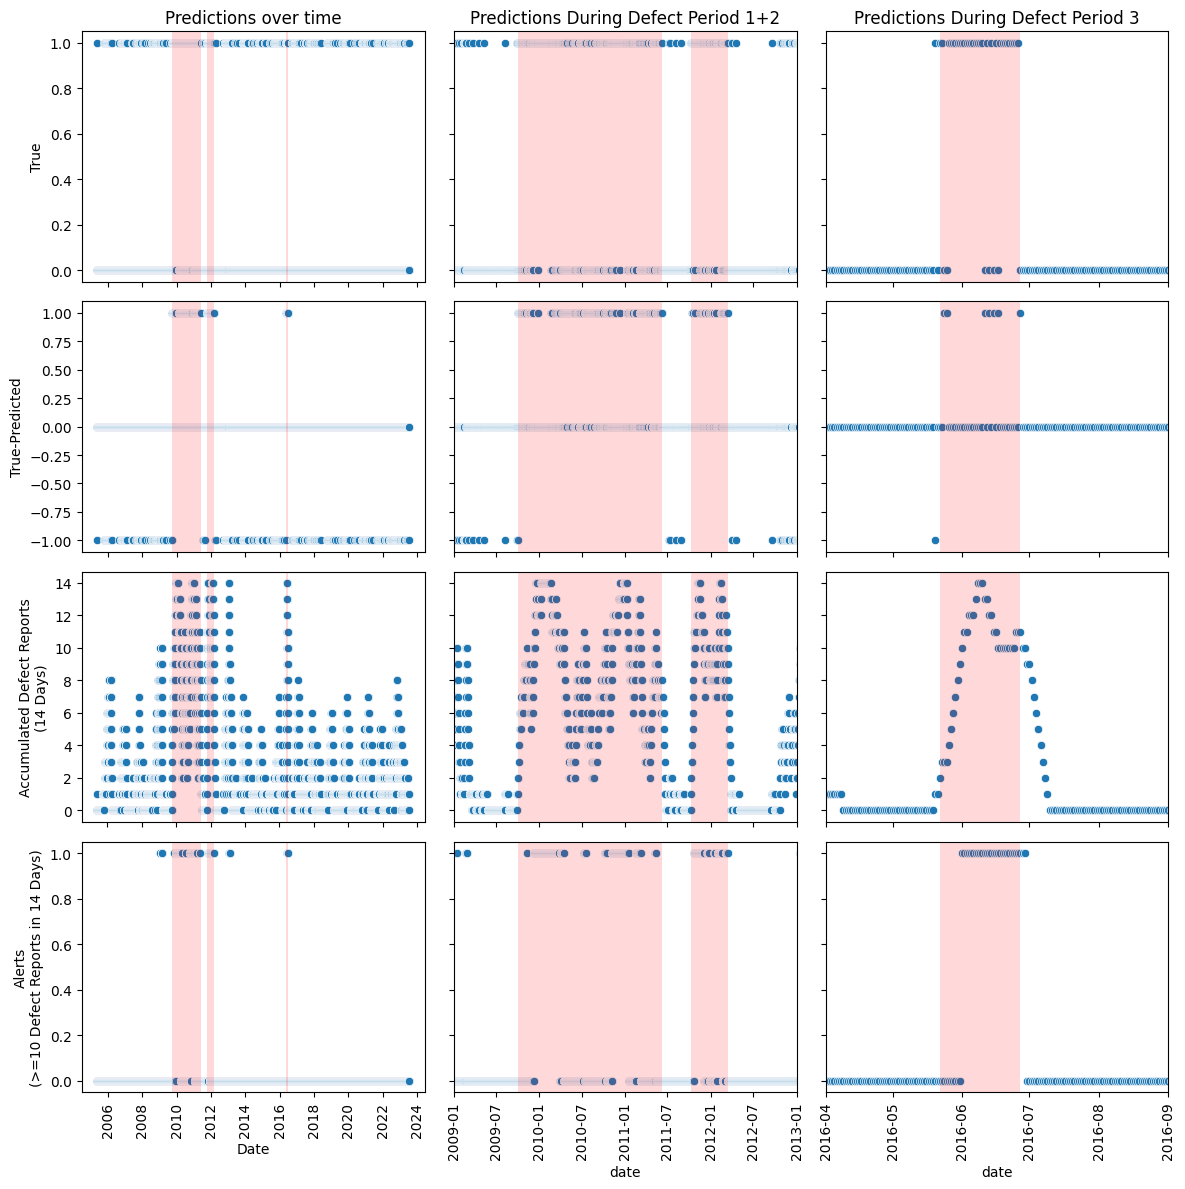

In [48]:
compound_viz(X,y,y_pred, time_window=14, alert_threshold=10)

5 of 1600 FP alerts
           date  y  y_pred  y_pred_sum
1337 2009-01-14  0     1.0        10.0
1378 2009-02-24  0     1.0        10.0
1379 2009-02-25  0     0.0        10.0
1380 2009-02-26  0     0.0        10.0
1381 2009-02-27  0     0.0        10.0
0 of 122 FP alerts
Empty DataFrame
Columns: [date, y, y_pred, y_pred_sum]
Index: []
18 of 1528 FP alerts
           date  y  y_pred  y_pred_sum
2800 2013-01-16  0     1.0        10.0
2801 2013-01-17  0     1.0        10.0
2802 2013-01-18  0     1.0        10.0
2803 2013-01-19  0     1.0        10.0
2804 2013-01-20  0     1.0        11.0
2805 2013-01-21  0     1.0        12.0
2806 2013-01-22  0     1.0        12.0
2807 2013-01-23  0     1.0        12.0
2808 2013-01-24  0     1.0        12.0
2809 2013-01-25  0     1.0        13.0
2810 2013-01-26  0     1.0        13.0
2811 2013-01-27  0     1.0        14.0
2812 2013-01-28  0     1.0        14.0
2813 2013-01-29  0     1.0        14.0
2814 2013-01-30  0     0.0        13.0
2815 2013-01-31  

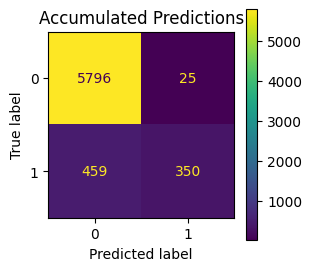

Raw predictions
 [[5238  583]
 [ 292  517]]
Accumulated predictions (threshold: 10 of 14 days)
 [[5796   25]
 [ 459  350]]

Recall: 0.43263
Precision: 0.93333
Accuracy: 0.92700


In [49]:
eval_accumulative_alerts(X, y, y_pred, alert_threshold=10, time_window=14, verbose=True)

#### Details for Model with 10/14 Threshold:

- 25 FPs - 2 due to lags, 1 singular events
    - 2 FP due to lags 2016-06-28 to 29 (2)  
    - 18 FP between 2013-01-16 - 2013-02-02 
    - 4 FP between 2009-02-24 - 2009-02-27   
    - 1 FP on 2009-01-14  
>
- 459 FNs - >42 due to lags!
    - \>20d lag for period 1
    - 12d lag for period 2
    - 10d lag for period 3

17 of 1600 FP alerts
0 of 122 FP alerts
16 of 1528 FP alerts
3 of 2571 FP alerts
--------------------------------------------------
36 FP in total!
5785 TN in total!

237 of 614 TP alerts - 377 FN
83 of 158 TP alerts - 75 FN
24 of 37 TP alerts - 13 FN
--------------------------------------------------
344 TP in total!
465 FN in total!



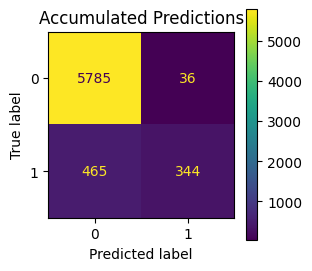

Raw predictions
 [[5238  583]
 [ 292  517]]
Accumulated predictions (threshold: 8 of 11 days)
 [[5785   36]
 [ 465  344]]

Recall: 0.42522
Precision: 0.90526
Accuracy: 0.92443


In [50]:
eval_accumulative_alerts(X, y, y_pred, alert_threshold=8, time_window=11)

# Notes

1. exclude sensor
    - clearly improved results when excluding sensor variable (kind of leakage)
    - yet: many false positives and some false negatives
>
2. accumulate defect predictions
    - idea: defects persist &rarr; sum up predictions over 10 days and apply thresholds
    - approach: rolling sum (last 14 days) + threshold (>= 10 defects predicted)
    - clearly less FP, but some lagging
>
3. reduced number of features for improved recall and precision
    - one model with clearly better performance - the others are rather similar (but only a limited number of models tested, as quite a couple have similarly good recall and f1 scores)
>
4. evaluate optimized cumulative models from Gridsearch
    - now: 4 models tested (full data, >= 10/14 defects predicted) - selected features
    - all models: clearly improved precision and accuracy
    - all tested models: (slightly) reduced recall
    - note: lags explain a certain fraction of FP and FN
>
&rarr; models with all features seem to perform slightly better

# Next Steps

- evaluate model performance
    - plot test and train separately
    - apply model to other groups
    - apply model to group 2 with artificial defects
>
- generalize model (independent of location, capacity, technology, ...)
    - generalized input: % production relative to previous day
>
- try to improve precision & recall and handling of imbalanced data - nice website [here](https://medium.com/@rithpansanga/improving-precision-and-recall-in-machine-learning-tips-and-techniques-acb5a5fd27a6#:~:text=In%20conclusion%2C%20there%20are%20several,class%20weights%2C%20and%20using%20ensembling.) and [there](https://machinelearningmastery.com/threshold-moving-for-imbalanced-classification/)
    - further feature selection - according to [DWD description](https://www.dwd.de/DE/leistungen/klimadatendeutschland/beschreibung_tagesmonatswerte.html) 
    - over/undersampling (e.g. balanced random forest)
    - weekly/daily resembling
>
- neural networks fine tuning as described [here](https://machinelearningmastery.com/grid-search-hyperparameters-deep-learning-models-python-keras/)

# Other Analyses
- periodiogram for our data
- neural network for other solar data + weather
